### CrashCourse is my quick intros to python topics.


from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import *
from utils import Utils  
import sys
# Note QGraphicsConvenience classes cannot handle *args and **kwargs--  They CAN take *args/**kwargs, however, they cannot return back to the inheritance chain. This means they can be used at the END of the inheritance chain, where they don't NEED to pass on *args/**kwargs,  OR subclass QGraphicsItem itself & rebuild that functionality. I have done both these strategies (Trace&TraceItem uses QGraphicsLineItem, Via/ViaItem uses QGraphicsItem)

In [ ]:
from PySide6.QtWidgets import *
from PySide6.QtCore import *
from PySide6.QtGui import *
from BoardItem import *
from MyView import MyView
from BoardScene import BoardScene
from utils import Utils
from collections import defaultdict
import sys
from utils import CopperItemContainer ,LayerItem
from MainWindow import MainWindow

class ViaBase():#QGraphicsItem):
    def __init__(self, outerDiameter, innerDiameter, clearance, **kwargs):#,parent=None):
        print('VIABASE.KWARGS:', kwargs)
        super().__init__(**kwargs)#parent) 
        # super().__init__(parent=parent) TypeError: NO BAD no keywords use positional: LayersContainer.__init__() got an unexpected keyword argument 'parent' # IDK why this happens-- could not replicate in simple example. Something about QGraphicsItem preferring positional args. But sometimes it can take kwargs. I always put classes, which inherit QGI, LAST, in the inheritance, because super() cannot propagate correctly after it hits QGI.
        
        self._outerDiameter = outerDiameter 
        self._innerDiameter = innerDiameter 
        self._clearance = clearance

        self._boundingRect = QRectF(-(outerDiameter+clearance)/2 , -(outerDiameter+clearance)/2 , outerDiameter+clearance , outerDiameter+clearance) # Must include clearance in BR so we can redraw the clearance w/o artifacts.

    def boundingRect(self):
        return self._boundingRect 

    # def paint(self, painter, option, widget):
    #     pass 
    
    def shape(self): # Note that shape, .bR, are GOING to be reimplementing QGI.shape,.bR once ViaBase is inherited by Via, ViaItem. (Good, bad) practice? 
        path = QPainterPath()
        path.addEllipse(QPoint(),  self.outerRadius(), self.outerRadius() ) # This doesnt account for clearance, and it doesnt need to, but bR needs to
        return path 
        
    def outerDiameter(self):
        return self._outerDiameter 
    def innerDiameter(self):
        return self._innerDiameter 

    def outerRadius(self):
        return self._outerDiameter/2
    def innerRadius(self):
        return self._innerDiameter/2
    
    def clearance(self):
        return self._clearance
            
# class ViaItem(CopperItem, ViaBase):
class ViaItem(LayerItem, ViaBase, QGraphicsItem):
        # def QGI.__init__(self, parent: PySide6.QtWidgets.QGraphicsItem | None= ...) -> None: ...
    def __init__(self, layer, outerDiameter, innerDiameter, clearance, color , parent):
        # super().__init__(outerDiameter=outerDiameter, innerDiameter=innerDiameter, clearance=clearance, parent=parent)
        super().__init__( layer, outerDiameter=outerDiameter, innerDiameter=innerDiameter, clearance=clearance, parent=parent) # TypeError: ViaBase.__init__() takes 4 positional arguments but 5 were given
        # QGraphicsItem.__init__(self, parent)
        # print('VIAITEM.LAYER:', self.layer())
        self._color = color
        # self._boundingRect = QRectF(-(outerDiameter+clearance)/2 , -(outerDiameter+clearance)/2 , outerDiameter+clearance , outerDiameter+clearance) # Must include clearance in BR so we can redraw the clearance w/o artifacts.

    # def boundingRect(self): # Belive this covered by super
    #     return self._boundingRect
    
    def paint(self, painter, option, widget): # QGraphicsItem.paint reimplementation to draw the aspects of a via: a clearance indicator and some colored circles
        #DrawClearance
        painter.setPen(QPen(self._color, 0))
        painter.setBrush(Qt.BrushStyle.NoBrush)
        painter.drawEllipse(QPointF(), self.clearance()/2, self.clearance()/2)
        #DrawVia
        painter.setPen(Qt.NoPen)
        painter.setBrush(QBrush(self._color, bs=Qt.BrushStyle.SolidPattern))
        painter.drawEllipse(QPoint(0,0), self.outerDiameter()/2 , self.outerDiameter()/2)
        painter.setBrush(QColor(230,230,230)) # Gray
        painter.drawEllipse(QPoint(0,0), self.innerDiameter()/2+Utils.viaPlatingThickness , self.innerDiameter()/2+Utils.viaPlatingThickness)
        painter.setBrush(QColor(255,215,0)) # Gold
        painter.drawEllipse(QPoint(0,0), self.innerDiameter()/2, self.innerDiameter()/2)

# class Via(LayersContainer, ViaBase): # A Via is made up of several childItem viaItems, one viaItem per layer. 
class Via(ViaBase, CopperItemContainer, QGraphicsItem):
    
    def __init__(self,  outerDiameter, innerDiameter, clearance=Utils.viaClearance, layers=Utils.CopperLayers): # layers : A via may exist on all or some layers, default all # clearance: default 1mm
        print('VIA.MRO:', Via.mro())
        super().__init__(outerDiameter=outerDiameter, innerDiameter=innerDiameter, clearance=clearance, layers = layers)

        self.setFlags(QGraphicsItem.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
        
        # print('VIA.LAYERS():', self.layers())
        for layer in self.layers():
            # print('LAYER:', layer)
            ViaItem(layer, outerDiameter, innerDiameter, clearance, Utils.layerColors[layer], self)
            # self.copperItems()[layer].append(item) Phasing out# Track ViaItem as copperItems ( is this necessary? )

    def nearestSceneSnap(self, pos): # Via only has one snap; center. But since TraceItem has two snaps, all items need this method to maintain consistent API.
        return self.scenePos()
    
    def mouseMoveEvent(self, event):
        super().mouseMoveEvent(event)
        # for copperItems in self.copperItems().values():
        #     for copperItem in copperItems: 
        #         copperItem.updateRtree()
        #         copperItem.setSceneBuffer()
        #         copperItem.setTerminals()
        #         copperItem.setSceneBounds()
                
        self.setSceneTerminal()
        
    def net(self):
        return self._net 
    def setNet(self, net):
        # Note pad net is determined by the schematic connections. Via,Trace, net is determined by pads
        self._net = net
    def sceneTerminal(self): 
        return self.scenePos()
    def setSceneTerminal(self):
        self._sceneTerminal = self.scenePos()
        
    def sceneTerminals(self):
        return self._sceneTerminals
    def setSceneTerminals(self):
        self.setSceneTerminal()
        self._sceneTerminals = [self.sceneTerminal()]
    def boundingRect(self):
        return self.childrenBoundingRect() or QRectF()
    def paint(self, painter, option, widget):
        pass# ChildrenItems will paint themselves



















from NetSymbol import NetSymbol
from Trace import Trace

window = MainWindow()
boardScene = window.centralWidget().widget(1).scene()
via = Via(50, 30, layers = ['F.Cu', 'B.Cu'])
trace = Trace(layers = ['F.Cu'], p1= QPointF(50,50), p2 =QPointF(1000, 500), traceWidth = 1)
boardScene.addItem(trace)

# print([item for item in via.childItems()])
ns = NetSymbol('?', 1, "symbols/NetSymbols/GND.sym")

via.setPos(100,100)
boardScene.addItem(via)
window.show()
sys.exit(qApp.exec())
# SELF.COMPONENTS: defaultdict(<class 'collections.defaultdict'>, {'?': defaultdict(None, {1: <Component.Component object at 0x00000272C7C6D790>}), 'GND': defaultdict(None, {})})


LAYERS: None
VIA.MRO: [<class '__main__.Via'>, <class '__main__.ViaBase'>, <class 'utils.CopperItemContainer'>, <class 'BoardItem.BoardItem'>, <class 'PySide6.QtWidgets.QGraphicsItem'>, <class 'Shiboken.Object'>, <class 'object'>]
VIABASE.KWARGS: {'layers': ['F.Cu', 'B.Cu']}
LAYERS: ['F.Cu', 'B.Cu']
VIABASE.KWARGS: {'parent': <__main__.Via(0x1ed210a78c0, pos=0,0, flags=(ItemIsMovable|ItemIsSelectable)) at 0x000001ED1FA730C0>}
VIABASE.KWARGS: {'parent': <__main__.Via(0x1ed210a78c0, pos=0,0, flags=(ItemIsMovable|ItemIsSelectable)) at 0x000001ED1FA730C0>}
LAYERS: ['F.Cu']
SELF.LAYERS: ['F.Cu']
LAYER: <class 'str'> F.Cu
MYSCENE MOUSERELEASEEVENT
MYSCENE MOUSERELEASEEVENT
MYSCENE MOUSERELEASEEVENT
MYSCENE MOUSERELEASEEVENT
MYSCENE MOUSERELEASEEVENT
MYSCENE MOUSERELEASEEVENT
MYSCENE MOUSERELEASEEVENT
normalModeMousePressEvent
normalModeMousePressEvent
normalModeMousePressEvent
normalModeMousePressEvent
normalModeMousePressEvent
normalModeMousePressEvent
normalModeMousePressEvent
normalModeMo

In [6]:
"""I don't think the QGraphics convenience classes can return to the MRO chain. 


TRACEBASE.KWARGS: {'layers': ['F.Cu']}

----> 9 super().__init__(QLineF(p1, p2), *args, **kwargs)

AttributeError: PySide6.QtWidgets.QGraphicsLineItem.__init__(): unsupported keyword 'layers'

 """

# lets recreate this 

class A():
    def __init__(self, a, *args, **kwargs):
        self._a = a
        super().__init__(*args, **kwargs)
        
# class Line(QGraphicsLineItem, A): 
class Line(A, QGraphicsLineItem): 
    def __init__(self, a, *args, **kwargs): 
        super().__init__('a', *args, **kwargs)


line= QLineF(0,0,0,0)

# Line = Line(line, 'a')
Line = Line('a', line)



In [1]:
class A:
    def __init__(self, a):
        super().__init__()

class B(A):
    def __init__(self, layers, *args ,**kwargs):
        print('B.KWARGS:', kwargs)
        super().__init__(*args, **kwargs)
        self._layers = layers 


class C(B): 
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs) 


c = C( a = 'a' , layers = 'layers' )

B.KWARGS: {'a': 'a'}


In [1]:
from utils import * 
p = QPointF(QPointF(10,10))
print(p)

d = { (10,10) : 'pin1'}
for _ in d: 
    print(_)
    print(QPointF(**d))

PySide6.QtCore.QPointF(10.000000, 10.000000)
(10, 10)
PySide6.QtCore.QPointF(0.000000, 0.000000)


In [2]:
from utils import * 
tup = (10,10) 
qp = QPointF(10,10) 
print(tup == qp.toTuple())

True


In [1]:
from scipy.sparse import coo_array 
# TypeError: 'list' object cannot be interpreted as an integer
row = [0, 1 , 2] 
col = [0, 0 , 1] 
data= [3, 4 , 5]

# coo = coo_array( data, (row, col) ) # WRAP IN A TUPLE ELSE # TypeError: 'list' object cannot be interpreted as an integer

coo = coo_array( (data , (row, col)) ) 
print(coo.toarray())



[[3 0]
 [4 0]
 [0 5]]


In [1]:
def pointWithinLine(point, line, epsilon = 1e-9): #  https://stackoverflow.com/questions/328107/how-can-you-determine-a-point-is-between-two-other-points-on-a-line-segment. Q: Where did his equations for CP, DP, come from? Q: Best value for epsilon? 
    
    a, b, c = line.p1() , line.p2() , point 
    
    crossProduct = (c.y() - a.y()) * (b.x() - a.x()) - (c.x() - a.x()) * (b.y() - a.y())
    
    if abs(crossProduct) > epsilon: 
        return False 

    dotProduct = (c.x() - a.x()) * (b.x() - a.x()) + (c.y() - a.y())*(b.y() - a.y())
    print('DOTPRODUCT:', dotProduct)
    # if dotProduct < 0: # Inclusive of endpoints 
    if dotProduct <= 0: # Exclusive of endpoints (to test if point WITHIN line, I want exclusive)()
        return False 

    squaredLengthBA = (b.x() - a.x())*(b.x() - a.x()) + (b.y() - a.y())*(b.y() - a.y())
    print('SQUAREDLENGTHBA:', squaredLengthBA)
    if dotProduct >= squaredLengthBA: 
        return False 

    else: 
        return True 

from utils import * 

point = QPointF(0,0) 
point = QPointF(0,.1)
point = QPointF(0,0.0000000001)
point = QPointF(0,0.00000000001)
# point = QPointF(-11,11)
# point = QPoint(11,11)
# point = QPointF(10,-10)



line = QLineF(10,-10, -10, 10)

print(pointWithinLine(point, line))

DOTPRODUCT: 400.0000000002
SQUAREDLENGTHBA: 800.0
True


In [1]:
l = [1]
l2 = l 

l2 = [2]

print(l)
print(l2)

[1]
[2]


In [ ]:
import networkx as nx 
G = nx.Graph([ (0,1)])
G = nx.Graph( [(0,1, {'weight':10})])
print(G.edges)
# print(G.edges(2)) NetworkXError: nbunch is not a node or a sequence of nodes.
print(G.edges([2])) 

G.add_edges_from( [ (4,5, {'weight': 6})])



[(0, 1)]
[]


8
3
[1, 2, 3, 'spam', 's', 'p', 'a', 'm']
[(1, 2), (1, 3), (3, 'm')]
[2, 3]
[2, 3]
2
[(2, 1), ('m', 3)]
[(2, 1), (3, 2)]
[(1, 2, {'weight': 10}), (1, 3, {}), (3, 'm', {})]
[(1, None), (2, None), (3, None), ('spam', 'blue'), ('s', None), ('p', None), ('a', None), ('m', None)]
[1, 3, 'spam']
[(1, 3)]
[1, 3, 'spam']
[]
[(1, 2), (2, 1)]
[(0, 1), (1, 2), (2, 3)]
[(0, 1), (0, 2), (1, 2)]
{2: {'color': 'yellow'}}
1, 2, 0.125
2, 1, 0.125
3, 4, 0.375
4, 3, 0.375
(1, 2, 0.125)
(3, 4, 0.375)
[(1, {'time': '5PM', 'room': 714}), (3, {'time': '2PM'})]
[(1, 2), (3, 4), (3, 2), (4, 5)]


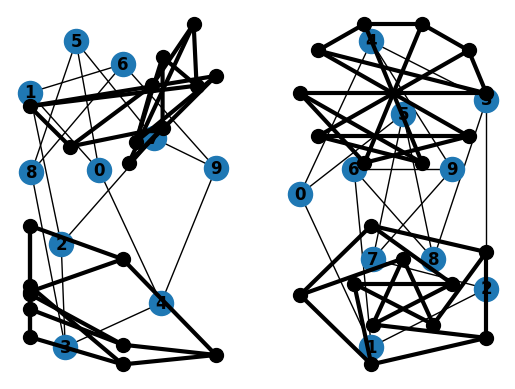

In [ ]:
### NETWORKX TUTORIAL ### 
# ! pip install networkx
import networkx as nx 
G = nx.Graph() # A collection of nodes(vertices) linked to other nodes. Nodes can be any hashable(immutable: think string or number, but if you want they could be image, XML, another Graph, a custom node object, etc.) ( For example, node1 and node2 could be protein objects from the RCSB Protein Data Bank, and their edge could be associated with with an XML record of publications on those proteins) 'None' cannot be used as a node-- bc it determines whether optional arguments have been assigned

# Graph generator functions: 
# read/write graphs to other formats: NetworkX supprots formaats like edge lists, adjacencyLists, GML, GraphML, LEDA, and more 


## NODES ## 
G.add_node(1) # add a node 
G.add_nodes_from([2,3]) # add nodes from any iterable
G.add_nodes_from( [ (4,{'color':'red'}) , (5, {'color:':'green'}) ]) # add nodes with node attributes, using iterable of 2-tuples (node, node_attribute_dict)


H = nx.path_graph(10)
G.add_nodes_from(H) # add nodes from one graph to another 

G.add_node(H) # add the graph H as a node in G. Flexibility allows graph of graphs, files, function, and more. 

# You should not change the node object. If the hash depends on its contents. 

## EDGES ## 
G.add_edge(1,2)
e = (2,3)
G.add_edge(*e) # gotta unpack edge tuples 
G.add_edges_from([ (1,2) , (1,3)]) 
G.add_edges_from(H.edges) # add edges from another graph

# NX silently ignores attempts to add already present nodes/edges. 
G.clear() # remove all nodes and edges 
G.add_edges_from( [ (1,2) , (1,3) ])
G.add_node(1) 
G.add_edge(1,2) # Already exists, nothing will happen
G.add_node('spam') # adds node 'spam'
G.add_nodes_from('spam') # adds 4 nodes 's' 'p' 'a' 'm'
G.add_edge(3, 'm')

print(G.number_of_nodes())
print(G.number_of_edges())

print(list(G.nodes)) # [1, 2, 3, 'spam', 's', 'p', 'a', 'm']

print(list(G.edges)) # [(1, 2), (1, 3), (3, 'm')]

print(list(G.adj[1])) # [2, 3]
print(list(G.neighbors(1))) # [2, 3]

print(G.degree[1]) # The number of edges incident to 1 

print( G.edges( [2, 'm'] ) ) # edges of node 2 and node 'm'
print( G.degree( [2,3] ) ) # degree of node 2 and node 3 

## ACCESS PATTERNS ## 
# Both nodes and edges cana be accessed as attributes (G.nodes) or as callables (G.nodes()) 
G.nodes['spam']['color'] = 'blue' 
G.edges[ (1,2) ]['weight'] = 10 

print(G.edges(data=True)) # [(1, 2, {'weight': 10}), (1, 3, {}), (3, 'm', {})]


print(G.nodes(data='color')) # [(1, None), (2, None), (3, None), ('spam', 'blue'), ('s', None), ('p', None), ('a', None), ('m', None)]


## REMOVING ELEMENTS FROM A GRAPH ##

G.remove_node(2)
G.remove_nodes_from('spam')
print(G.nodes) # [1, 3, 'spam']
print(G.edges) # [(1, 3)]

G.remove_edge(1,3) # Removing a specific edge only affects that edge
print(G.nodes) # [1, 3, 'spam']
 
print(G.edges) # []

## USING THE GRAPH CONSTRUCTORS ## 
G.add_edge(1,2)
H = nx.DiGraph(G) # Create directional graph using connections from G 
print(H.edges()) # [(1, 2), (2, 1)]


edgelist=  [ (0,1) , (1,2) , (2,3) ] 
H = nx.Graph(edgelist) # Construct graph from edge list 
print(H.edges())# [(0, 1), (1, 2), (2, 3)]

adjacency_dict = {0:(1,2) , 1: (0,2) , 2: (0,1)}
H = nx.Graph(adjacency_dict) # Createa graph mapping nodes to numbers 
print(H.edges) # [(0, 1), (0, 2), (1, 2)]

# edges can be associated with any object x using G.add_edge(n1, n2, object=x)

## ACCESSING EDGES AND NEIGHBORS
# Subscript notation as well as Graph.edges & Graph.adj, can be used to acccess the edges and neighbors
G = nx.Graph( [(1,2,{'color':'yellow'})])
print(G[1]) # same as G.adj[1] # {2: {'color': 'yellow'}}

G[1][2] # {'color':'yellow'}

G.edges[1,2] # ('color':'yellow')

G.add_edge(1,3)
G[1][3]['color'] = 'blue'
G.edges[1,2]['color'] = 'red' 

# Examine node, adjacency pairs with G.adjacency(), or G.adj.items() 
# For undirected graphs, adjacency iteration sees each edge twice 
FG = nx.Graph()
FG.add_weighted_edges_from( [(1, 2, 0.125), (1, 3, 0.75), (2, 4, 1.2), (3, 4, 0.375)])
for n, numbers in FG.adj.items():
    for number, edge_attr in numbers.items(): 
        weight = edge_attr['weight'] 
        if weight < .5: print(f'{n}, {number}, {weight:.3}')
# 1, 2, 0.125
# 2, 1, 0.125
# 3, 4, 0.375
# 4, 3, 0.375


for ( u , v, weight ) in FG.edges.data('weight'):
    if weight < .5: 
        print(f'({u}, {v}, {weight:.3})')
# (1, 2, 0.125)
# (3, 4, 0.375)

## ADDING ATTRIBUTES TO GRAPHS, NODES, AND EDGES: ## 
# Attributes like weight, labels, colors, any object, can be attached to Graphs, nodes, and edges. 
# Attributes can be added or changed using add_edge, add_node, or direct manipulation of the attribute dict, which is named: G.graph, G.nodes, or G.edges. 

G = nx.Graph(day = 'Friday') 
G.graph # {'day': 'Friday'}
G.graph['day'] = 'Monday'

G.add_node(1, time='5PM')
G.add_nodes_from([3], time= '2PM')
G.nodes[1] # {'time':'5PM'}
G.nodes[1]['room'] = 714 
print(G.nodes.data()) # [(1, {'time': '5PM', 'room': 714}), (3, {'time': '2PM'})]

# Note adding a node to G.nodes does NOT addit to the graph. Use G.add_node() to add new nodes. Similarly for edges
G.add_edge(1,2 , weight = 4.7)
G.add_edges_from([(3,4) , (4,5) ] , color='red')
G.add_edges_from([(1,2, {'color':'blue'} ), (2,3, {'weight': 8})])
G[1][2]['weight'] = 4.7
G.edges[3,4]['weight'] = 4.2
print(G.edges)


## DRAWING GRAPHS ## 
import matplotlib.pyplot as plt 
G = nx.petersen_graph()
subax1 = plt.subplot(121) 
nx.draw(G, with_labels = True , font_weight = 'bold') 
subax2 = plt.subplot(122)
nx.draw_shell(G, nlist = [range(5,10) , range(5)] , with_labels = True, font_weight = 'bold')

options = {
    'node_color': 'black',
    'node_size': 100,
    'width': 3,
}
subax1 = plt.subplot(221)
nx.draw_random(G , **options)
subax2 = plt.subplot(222)
nx.draw_circular(G, **options)
subax3 = plt.subplot(223)
nx.draw_spectral(G, **options)
subax4 = plt.subplot(224)
nx.draw_shell(G, nlist =[ range(5,10) , range(5) ] , **options )

plt.savefig('path.png')


35.9 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
88.2 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


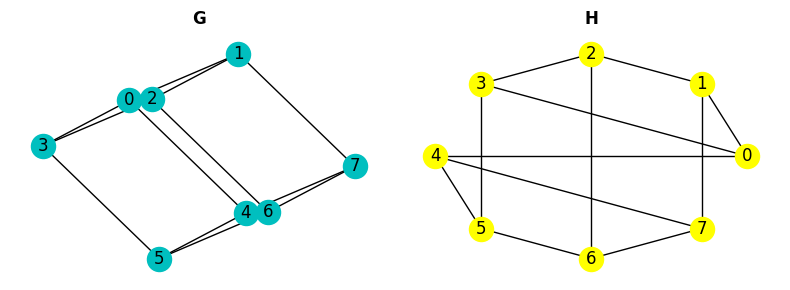

In [ ]:

# isomorphism: Two graphs are isomorphic if they have the same number of edges, vertices, and same edge connectivity. 
# 'Iso' meaning equal, similar, identical. 

# 'complete' graph: a graph in which every vertex is connected to evertother vertex 
fig, (G_ax , H_ax) = plt.subplots(1,2 , figsize = (8,3))
G = nx.cubical_graph()
nx.draw_spectral(G, with_labels = True , node_color = 'c', ax = G_ax)
G_ax.set_title('G', fontweight ='bold')
H = nx.cubical_graph()
nx.draw_circular(H, with_labels=True, node_color = 'yellow' , ax=H_ax)
H_ax.set_title('H', fontweight='bold')
fig.tight_layout()

# These two graphs are the same graph! 
# G and H are isomorphic if we can establish a 'bijection' between the vertex sets G and H

# bijection: "bijection is a relation between two sets such that each element of either set is paired with exactly one element of the other set."

# To prove that two graphs are isomorphic, we find the bijection between the vertex sets. We find a valid isomorphic mapping between the nodes in G and H. Can be expensive. 

# There are n! possible bijection functions for two graphs, G and H, of n nodes. Isomorphism is NP-hard; there are no algorithms that run in polynomial time 

G = nx.complete_graph(100) 
H = nx.relabel_nodes(G , {n: 10*n for n in G})
# Since we created H from G, we KNOW they are isomorphic 
nx.is_isomorphic(G,H)

#How expensive is this computation? 
%timeit -n1 -r1 nx.is_isomorphic(G,H) # ~40ms

H_ni = G.copy()
H_ni.remove_edge(27,72) # Remove an arbitrary edge to make G and H non isomorphic

%timeit -n1 -r1 nx.is_isomorphic(G, H_ni) # ~90 us. About a thousand times faster








In [ ]:
# Jupyter Notebook Notes 
# ! pip install networkX # Use ! to run commands straight on cmd line from jupyter cell 
# %timeit range(1000) # Use 'magic functions with % to use command-line style syntax. (the timeit syntax is a mouthful, %timeit is easier) 
# %%timeit x = range(10000) Use 'cell magics' with %%. Cell magics get as an argument not only the rest of the line, but also the lines below it
    # max(x)




In [ ]:
### HOW TO SPLIT A NODE IN A COO ARRAY ### 


points = [ (0,0) , (1,0) , (2,0) ] 

# Given points, we can make an adjaceny matrix: 
matrix = [ [0 , 1 , 0] ,
           [1 , 0 , 1] ,
           [0 , 1 , 0] ]

# Coo represenctation of matrix: 
row = [0,1]
col = [1,0] 
data= [1,1] 

# to remove point(0,0) from this matrix, we have to remove from row, col, and data. 
index = points.index((0,0)) 
for c, i in enumerate(row[:]): 
    print(c)
    
    if i == index :
        row.pop(c)
        col.pop(c)
        data.pop(c)
        
        



0
1


In [ ]:
### HOW TO REMOVE MULTIPLE INDICES FROM A LIST ### 
# https://stackoverflow.com/questions/11303225/how-to-remove-multiple-indexes-from-a-list-at-the-same-time

l = [0,1,2,3,4,5,6, 7]
indicesToRemove = [ 2, 3, 5]

def removeIndices(indicesToRemove, l):
    for r in sorted( indicesToRemove , reverse = True): 
        # del l[r]
        l.pop(r)
    return l

print(removeIndices(indicesToRemove, l))

[0, 1, 4, 6, 7]


In [ ]:
l = [1,2,3,4]
for c, i in enumerate(l): 

print(l)


NameError: name 'l' is not defined

In [ ]:

G = list()
print(G[0])


IndexError: list index out of range

In [ ]:
from Utils import * 

### GRAPH THEORY ### 
# Together, 'points' and adjacency Matrix contain the info we need 



In [ ]:
from collections import defaultdict

d = defaultdict(int)
print(d['C'])# defaultdict() default won't default to None?!



0


In [ ]:
defaultdicIntInfinite = lambda : defaultdict(defaultdicIntInfinite)
dd = defaultdicIntInfinite()
print(dd)
dd[3][4][5] = 1 
print(dd)




# defaultdictInfinite = lambda: defaultdict(defaultdictInfinite) # see infinite default dict



defaultdict(<function <lambda> at 0x0000022488FBB6A0>, {})
defaultdict(<function <lambda> at 0x0000022488FBB6A0>, {3: defaultdict(<function <lambda> at 0x0000022488FBB6A0>, {4: defaultdict(<function <lambda> at 0x0000022488FBB6A0>, {5: 1})})})


In [ ]:
from random import random
print(int(random()*400))

242


In [1]:
from collections import defaultdict
d = defaultdict(defaultdict)
# d['C'][1] # KeyError: 1

def dd(): # An infinite defaultdict
    return defaultdict(dd)

d = dd()
d['C'][1] = 'a'
print(d)

defaultdictInfinite = lambda: defaultdict(defaultdictInfinite)
d = defaultdictInfinite()
d['x']['y']['z'] = 10
print(d)


defaultdict(<function dd at 0x000002B8188FE660>, {'C': defaultdict(<function dd at 0x000002B8188FE660>, {1: 'a'})})
defaultdict(<function <lambda> at 0x000002B818A17B00>, {'x': defaultdict(<function <lambda> at 0x000002B818A17B00>, {'y': defaultdict(<function <lambda> at 0x000002B818A17B00>, {'z': 10})})})


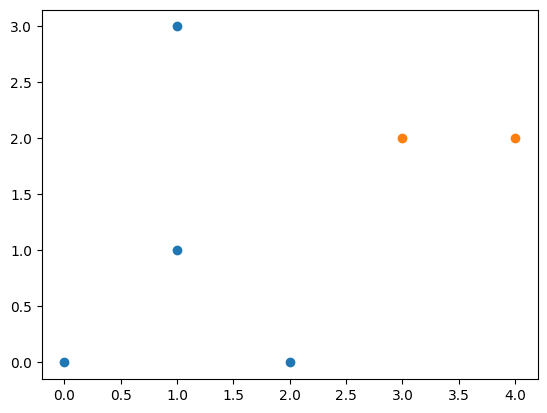

In [ ]:
from utils import * 
from random import random

import numpy as np
from scipy.sparse import coo_array
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
### MATPLOTLIB TUTORIAL
# points = [ (0,1) , (2,3) ]
# plt.plot(*zip(*points))

# plt.scatter(*zip(*points))
# plt.scatter([3,3],[4,5])
G = [ [ [2, 0], [0, 0], [1, 1], [1, 3]] , [ [3, 2], [4, 2] ] ]

for subgraph in G : 
    plt.scatter(*zip(*subgraph))

In [ ]:
print(list(range(0)))
print(list(range(1)))
print(list(range(2)))

[]
[0]
[0, 1]


G: [[(369, 47, 'B.Cu'), (252, 88, 'B.Cu')], [(72, 399, 'B.Cu'), (125, 306, 'B.Cu')], [(232, 361, 'B.Cu'), (284, 13, 'B.Cu')], [(208, 53, 'B.Cu'), (283, 165, 'B.Cu')]]
SUBGRAPH: [(369, 47), (252, 88)]
SUBGRAPH: [(72, 399), (125, 306)]
SUBGRAPH: [(232, 361), (284, 13)]
SUBGRAPH: [(208, 53), (283, 165)]
NOLAYERG: [[(369, 47), (252, 88)], [(72, 399), (125, 306)], [(232, 361), (284, 13)], [(208, 53), (283, 165)]]
FLAT: [(369, 47), (252, 88), (72, 399), (125, 306), (232, 361), (284, 13), (208, 53), (283, 165)]
SUBSETS: [{0, 1}, {2, 3}, {4, 5}, {6, 7}]

EDGES: 56 [(0, 1, 123.97580409095961), (0, 2, 460.55727114008306), (0, 3, 355.8328259168904), (0, 4, 342.5857556875358), (0, 5, 91.54780172128658), (0, 6, 161.11176245079065), (0, 7, 146.01369798755184), (1, 0, 123.97580409095961), (1, 2, 359.3341063689891), (1, 3, 252.29546171106605), (1, 4, 273.73162038756135), (1, 5, 81.54140052758476), (1, 6, 56.22277118748239), (1, 7, 83.00602387778854), (2, 0, 460.55727114008306), (2, 1, 359.334106368989

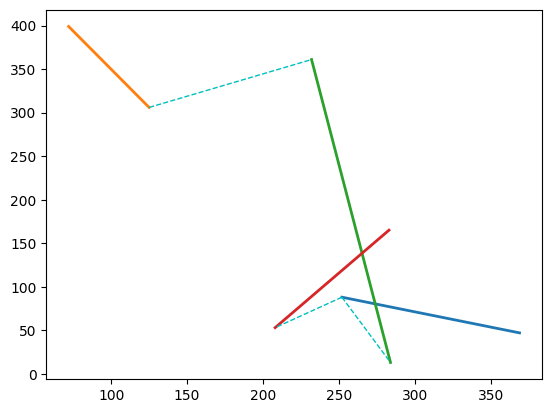

In [ ]:
# Ratsnest MST practice 
from utils import * 
from random import random, randint

import numpy as np
from scipy.sparse import coo_array
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt

def randomPoints(numPoints, layer, xLimit=400, yLimit=400, ):
    return [ ( int((random()*xLimit)) , int((random()*yLimit)) , layer)  for _ in range(numPoints) ]

def randomGraph(numSubgraphs=1, numPoints = 1): 
    G = [] 
    for i in range(numSubgraphs): 
        G.append( randomPoints( randint(1,numPoints) , ['F.Cu', 'B.Cu'][randint(0,1)] ) )
    return G

# G = randomGraph(numSubgraphs=4)
# print('RANDOMGRAPH:', G)
        
    
# ### RATSNEST TUTORIAL 
# # Start off with some points, representing points in a net, that are not yet linked together 




# Create a graph with all points 
# G = [pointsGND1 , pointsGND2, pointsGND3] 
G = [ [ [2,0,'F.Cu'] , [0,0,'F.Cu'],  [1,1,'F.Cu' ] , [1,3,'F.Cu'] ] , [ [3,2,'F.Cu'], [4,2,'F.Cu'] ] ]
G = [ [ [2,0,'F.Cu'] , [0,0,'F.Cu'],  [1,1,'F.Cu' ] , [1,3,'F.Cu'] ] , [ [3,2,'F.Cu'], [4,2,'F.Cu'] ] , [ [ 2,4, 'B.Cu'] ] , [ [2,3, 'B.Cu'] ] ]
G = randomGraph(4, 2)
print('G:', G)
flat = [] 

noLayerG = []
for subgraph in G: 
    noLayerSubgraph = []
    for xYLayer in subgraph: 
        noLayerSubgraph.append(xYLayer[0:2])
    noLayerG.append(noLayerSubgraph)

for subgraph in noLayerG: 
    print('SUBGRAPH:', subgraph)
    if len(subgraph) == 1:  # Plot a point if theres one point, otherwise a line
        plt.scatter(*zip(*subgraph) , s = 20) # Subsequent calls to plt will use different colors automatically
    else: 
        plt.plot(*zip(*subgraph) , linewidth = 2) # Subsequent calls to plt will use different colors automatically
print('NOLAYERG:', noLayerG)

for subgraph in G: 
    for xYLayer in subgraph: 
        pos = xYLayer[0:2]
        flat.append(pos)
print('FLAT:', flat)

for subgraph in G: 
    for xYLayer in subgraph: 
        pos = xYLayer[0:2]
        
        
    # plt.scatter(*zip(*flat)) # Plot points

# Now, find the minimum weight tree connecting the subgraphs. This will be your ratsnest 
def findSubgraph(index, G): 
    pos = flat[index]
    for subgraph in G: 
        for XYLayer in subgraph: 
            XY = XYLayer[0:2]
            if XY == pos: 
                return subgraph
            
def findSet(index ,subsets):
    for subset in subsets: 
        if index in subset: 
            return subset

# 1) track cycles w/ subsets- Kruskal starts by giving each vertice its own set, but we do more, as vertices of same subgraph belong in same subset
subsets = [] 
count = 0 
for subgraph in G :
    subset = set()
    for _ in subgraph: 
        subset.add(count)
        count += 1 
    subsets.append(subset)
print('SUBSETS:', subsets)

# 2) generate edges 
coo = coo_array(squareform(pdist(flat)))
# print()
# print('COO:', coo)
edges = list(zip(coo.row, coo.col, coo.data))
print()
print('EDGES:', len(edges), edges)
# 2b) Remove redundant edges 
for edge in edges: 
    u,v,dist = edge 
    if (v,u,dist) in edges: 
        edges.remove( (v,u,dist) ) 
# 3) Sort edges by weight 
edges = sorted(edges , key=lambda x:x[2]) 
print()
print('EDGES SORTED:', len(edges), edges)

# 4)  Remove intra-subgraph edges. Unlike kruskalMST, ratsnestMST disallows intra-subgraph connections, implemented by removing intra-subgraph edges. 
for edge in edges[:]:
    u,v,dist = edge
    subgraphU, subgraphV = findSubgraph(u, G) , findSubgraph(v, G)
    # print('subgraphU:', subgraphU)
    # print('subgraphV:', subgraphV)
    if subgraphU == subgraphV:
        edges.remove(edge)
    # print('EDGES:', len(edges), edges)

# 5) 
forest = set()
for edge in edges: 
    # print()
    # print('EDGE:', edge)
    u,v,dist = edge
    
    setU, setV = findSet(u, subsets) , findSet(v,subsets)
    # print('SETU:', setU)
    # print('SETV:', setV)
    if setU != setV: # then there is no cycle, add this edge 
        forest = forest.union( { frozenset([u,v]) }) # frozenset is immutable; able to be added to a set, while normal set is mutable and cannot go in a set
        subsets.append( setU.union(setV))
        subsets.remove(setU)
        subsets.remove(setV)
        print('FOREST:', forest)
    

import matplotlib.pyplot as plt

# plt.figure(figsize=(10,10))


# forest = [list(i) for i in forest]
# forest = [ (flat[u], flat[v]) for u,v in forest ]
for edge in forest: 
    u,v = edge
    # p1, p2 = flat[u] , flat[v]
    # xs = (p1[0] , p2[0]) 
    # ys = (p2[0] , p2[1])
    # plt.plot(xs, ys, 'm-', linewidth = 1)
    plt.plot(*zip(flat[u] , flat[v]) , 'c--', linewidth = 1) # This is my ratsnest 


In [ ]:
l1 = [ (0,3) , (2,4) ]
xs1 = [point[0] for point in l1]
print(xs1)


[0, 2]


In [ ]:
class A: 
    def __init__(self): 
        print('BEFORE A')
        super().__init__()
        print('AFTER A')
        
# a = A() 

class B(A):
    def __init__(self):
        print('BEFORE B')
        super().__init__()
        print('AFTER B')
        
b = B()


BEFORE A
AFTER A
BEFORE B
BEFORE A
AFTER A
AFTER B


In [ ]:
class A: 
    def __init__(self): 
        super().__init__()
        print(self.x)
        
# a = A() 

class B(A):
    def __init__(self):
        super().__init__()
        self.x = 'x' #AttributeError: 'B' object has no attribute 'x'. To fix this error, move this line before call to super().
b = B()
# MRO is B,A. So, I thought that B.__init__ would complete, then A.__init__ would complete, but this is not the case; super() does a weird nested thing. To get 

AttributeError: 'B' object has no attribute 'x'

In [ ]:
# The QGraphicsScene adds items 'flat'. eg, a childItem will turn up in scene.items() 
from utils import * 

scene = QGraphicsScene()
view = QGraphicsView() 
view.setScene(scene)
view.show() 
r = QGraphicsRectItem(-10,-10,20,20) 
e = QGraphicsEllipseItem (-10,-10,20,20, r) 
scene.addItem(r)

print(len(scene.items()), scene.items())

sys.exit(app.exec())

In [ ]:
# More inheritance practice 
# This code has a bug: class A and class B do not call super().__init__(*args, **kwargs). You may note class A and class B do not inherit anything, you may think they don't need to call super().__init__(). But class A and B need to call super().__init__() because they are inherited by class C. Class C's mro is C, A, B. When C initializes class A, and class A lacks the super().__init__() call , the mro chain will NOT be returned to; the chain will stop with class A; class B will never initialize. 
class A: 
    def __init__(self, a): 
        self.a = a 
        
class B: 
    def __init__(self, b):
        self.b = b
        
class C(A,B): 
    def __init__(self, a=None , b=None, c=None): 
        super().__init__(self)
        
c = C('a', 'b', 'c')
print(c.a, c.b. c.c)

    
        


In [ ]:
class A():
    def __init__(self, a, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.a = a 
        
class B(A):
    def __init__(self, b, *args, **kwargs):

        super().__init__(*args, **kwargs)
        self.b = b 
        
class C(B):
    def __init__(self, c, *args, **kwargs):

        # super().__init__(self, *args, **kwargs) NO BAD One of the most insidious bugs: super().__init__() NEVER takes self -- self is passed automatically -- This will screw your entire program
        super().__init__(*args, **kwargs)
        self.c = c 
        
c = C(c='c' ,b='b', a='a')
c = C('c', 'b', 'a')
print(c.a,c.b,c.c)

In [ ]:
# Minimal saving items on QGraphicsScene to file/Loading from file
# Saving a QGraphicsScene to a file is a matter of converting all items, with all their info, into strings, saved in a file, and then loading back that info from the file. Its a tedious problem.
from utils import * 
from MyView import MyView 
from BoardScene import BoardScene
import sys
from MainWindow import MainWindow
from FootprintItem import FootprintItem

import lxml.etree as etree
from collections import defaultdict

scene = BoardScene() 
view = MyView()
view.setScene(scene)

# r = QGraphicsRectItem(-10,-10,20,20)
# r.setPen(QPen(Qt.red, 1))
# scene.addItem(r)
# fp = FootprintItem('C', 6, os.path.join('./footprints/SMD/G-21_MUR/G-21_MUR.fp')) 
fp = FootprintItem('C', 6, os.path.join('footprints', 'SMD', 'G-21_MUR', 'G-21_MUR.fp' )) 
scene.addItem(fp)


mainWindow = QMainWindow()
mainWindow.setCentralWidget(view)
mainWindow.show()


sauraFile = './file.saura'

def save():
    print('SAVING')
    # Clear the file 
    with open(sauraFile, 'w') as fo: 
        fo.write('')
        
    # Store all items in the file 
    for item in scene.items():
        print('ITEM:', item)
        data = {}
        if isinstance(item, FootprintItem): 
            data['pos'] = item.pos().toTuple()
            data['shape'] = Utils.Shape.Footprint.value
            data['file'] = item.file()
            data['referenceDesignator'] = item.referenceDesignator()
            data['referenceNumber'] = item.referenceNumber()
            
        if data: 
            with open(sauraFile, 'a') as fo: 
                fo.write(json.dumps(data)) # TypeError: Object of type QPointF is not JSON serializable
                fo.write('\n')
            
            
    
        
def load():
    with open(sauraFile) as fo: 
        lines = fo.readlines()
        for line in lines: 
            data = json.loads(line)
            shape = data['shape']
            if shape == Utils.Shape.Footprint.value: 
                rd = data['referenceDesignator']
                rn = data['referenceNumber']
                file = data['file']
                pos = data['pos']
                
                item = FootprintItem(rd, rn, file)
                item.setPos(*pos) 
                
            scene.addItem(item)
            
def saveAs():
    pass 

fileMenu = mainWindow.menuBar().addMenu('File')
saveAction = fileMenu.addAction('Save')
saveAsAction = fileMenu.addAction('Save As')
loadAction = fileMenu.addAction('Load')

saveAction.triggered.connect(save)
saveAsAction.triggered.connect(saveAs)
loadAction.triggered.connect(load)


sys.exit(app.exec())
# Worried about power out mid-file write. How to avoid negative effects of powerouts? does context manager handle this? 


COPPERITEMS: [<FootprintItem.Pad(0x156d789e100, parent=0x156d7897340, pos=0,0, z=1) at 0x00000156D9C5B500>, <FootprintItem.Pad(0x156d73d8180, parent=0x156d7897340, pos=0,0, z=1) at 0x00000156D9C5BD80>]
COPPERITEM.NET(): C6_1
COPPERITEM.NET(): C6_2
FOOTPRINTITEM CREATED
BUFFER: <PySide6.QtGui.QPolygonF(QPointF(-1.3589,-0.7223), QPointF(-0.4953,-0.7223), QPointF(-0.3953,-0.6223), QPointF(-0.3953,0.6223), QPointF(-0.4953,0.7223), QPointF(-1.3589,0.7223), QPointF(-1.4589,0.6223), QPointF(-1.4589,-0.6223), QPointF(-1.3589,-0.7223)) at 0x00000156D9C5B080>
SETSCENEBUFFER
BUFFER: <PySide6.QtGui.QPolygonF(QPointF(0.4953,-0.7223), QPointF(1.3589,-0.7223), QPointF(1.4589,-0.6223), QPointF(1.4589,0.6223), QPointF(1.3589,0.7223), QPointF(0.4953,0.7223), QPointF(0.3953,0.6223), QPointF(0.3953,-0.6223), QPointF(0.4953,-0.7223)) at 0x00000156D9C84D00>
SETSCENEBUFFER
SAVING
ITEM: <PySide6.QtWidgets.QGraphicsSimpleTextItem(0x156d78a7a80, parent=0x156d7897340, pos=0,0, z=20) at 0x00000156D9C48B80>
ITEM: 

SystemExit: 0

In [ ]:
from lxml import etree 
elem =   '<pad name="1" type="smd" shape="rect" width="0.4318" height="0.2794" layers="" left="-1.6159" top="-1.6397" c_x="-1.4" c_y="-1.5"/>'

elem = etree.fromstring(elem)
print('TYPE:', type(elem))
print('ATTRIB:', elem.attrib)
elem = etree.tostring(elem , encoding=str , pretty_print=True)
print('ELEM:', elem)

tree = etree.parse("footprints/SMD/LED_SML-D12U1WT86.fp")

print(type(tree))
print(print(type(tree.getroot())))
print(tree.getroot().attrib)

In [ ]:
from utils import * 
color = QColor(Qt.red).toTuple()
print(color)

In [ ]:
import os 
import json
print(os.path.join('.'))
print(os.path.abspath('.'))

with open('./test.txt', 'w') as fo:  
    fo.write('') # Clear the file
    
with open('./test.txt', 'a') as fo:
    d = {'a':'b'} 
    
    fo.write(json.dumps(d))

In [ ]:
import lxml.etree as etree 


In [ ]:
# A defaultdict of defaultdict?
from collections import defaultdict 
# d = defaultdict(defaultdict)
# print(d)
# d['C'][4] = 'asdf'
# print(d)
# d['C'][5]

d = defaultdict(list)
d['C']
print(d)

d = defaultdict(defaultdict)
d['C'][4] = 'asdf'
print(d)



In [ ]:
from utils import * 
line = QLineF(10,10,20,20)
lineItem = QGraphicsLineItem(line)
line.setLine(60,60,70,70)
print(lineItem.line())

In [ ]:
class A(): 
    def __init__(self, a, **kwargs)
        super().__init__(**kwargs)
        
class B():
    def __init__(self, b)
        super().__init__()

In [ ]:
## Inheritance practice again 

class A: 
    def __init__(self,a, *args):
        super().__init__()
        self.a = a
        
class B(A): 
    def __init__(self, b, *args):
        print('B.ARGS:', args)
        super().__init__(*args)
        self.b = b
        
class C():
    def __init__(self,c, *args):
        super().__init__(*args)
        self.c = c
        
class D(B, C):
    def __init__(self, d, *args):
        super().__init__( *args)
        
print(D.mro()) # D, B, A, C, object

d = D('d', 'b', 'a', 'c')
d.c
d.a
d.b



        

In [ ]:
# Ffline initialization is causing kernel crash. track down why 
from utils import * 
from utils import CopperItemContainer
from BoardScene import BoardScene, Ffline
from MyView import MyView 
from Trace import TraceItem

view = MyView()
scene = BoardScene()
view.setScene(scene)
view.show()
_traceA = TraceItem(2, 'F.Cu', QLineF()) # crashes kernel 

# _lineItemA = QGraphicsLineItem(30,50, 100,100)
# _lineItemA.setPen(QPen(Qt.red ,1))
# QPen(self._color, self._traceWidth, c=Qt.PenCapStyle.RoundCap)
# scene.addItem(_lineItemA)
# lineItem = QGraphicsLineItem()
# lineItem.setLine(QLineF())

# class NotCrasher(CopperItemContainer, QGraphicsLineItem): 
#     def __init__(self):
#         super().__init__()

# crasher = NotCrasher()

# ffline = Ffline(QPoint(0,0) , QPoint(100,100), scene) # Crashes kernel \




sys.exit(app.exec())

In [ ]:
from utils import * 
from utils import CopperItemContainer

class CopperItemContainer():
    def __init__(self):
        super().__init__()


class TraceItem(CopperItemContainer, QGraphicsLineItem): # These are mutually exclusive. Cannot be a TI with a CuIC.bR 
    def __init__(self):
        super().__init__()
        
print(TraceItem.mro())
view = QGraphicsView()
scene = QGraphicsScene()
view.setScene(scene)
view.show()



ti = TraceItem()
scene.addItem(ti)
print(ti.scene) # <built-in method scene of TraceItem object at 0x000001FDA03B1D00>
print(ti.scene())# "he Kernel crashed while executing code in the current cell" TI.SCENE() IS CAUSING KERNEL CRASHES. 
# print(ti.boundingRect())
# print(ti.scene())
# print(ti.mapToScene(0,0))
# ti.mapToScene(ti.boundingRect())

# BUFFER: <PySide6.QtGui.QPolygonF() at 0x000001CE83313680>
        # rect = self.mapToScene(self.boundingRect().adjusted(-self._bufferDistance,-self._bufferDistance, self._bufferDistance,self._bufferDistance)).boundingRect() # 
sys.exit(app.exec())

In [ ]:
from utils import * 
from utils import CopperItemContainer
from BoardScene import BoardScene, Ffline
from MyView import MyView 
from Trace import TraceItem




view = MyView()
scene = BoardScene()
view.setScene(scene)
view.show()

item  = QGraphicsRectItem(QRectF(0,0,100,100))
scene.addItem(item)

print(item.scene())
sys.exit(app.exec())



In [ ]:
# Sometimes The kernel crashes with no debug info, which is near impossible to track. This often will happen if I get types wrong in signals/slots. But this time around, when I do mouse press while in addTraceModeMousePressEvent, the kernel crashes.
https://stackoverflow.com/questions/68289142/pyqt-how-can-i-catch-a-qt-crash-and-get-reliable-error-messages

import sys
import time

from PyQt5.QtWidgets import QApplication, QMainWindow, QPushButton
from PyQt5.QtCore import pyqtSignal, QThread


def some_function():
    time.sleep(1)
    print("finished sleep, about to crash")
    raise RuntimeError("broken")


class MadeToFail(QThread):
    error_ocurred = pyqtSignal(Exception, name="errorOcurred")

    def run(self):
        try:
            some_function()
        except Exception as e:
            self.error_ocurred.emit(e)


class Window(QMainWindow):
    def __init__(self):
        super(Window, self).__init__()
        self.setWindowTitle("PyQt5 App")
        self.setGeometry(100, 100, 280, 80)
        self.move(60, 15)
        break_button = QPushButton(parent=self)
        break_button.setText("break")
        break_button.clicked.connect(self.break_thread)

    def break_thread(self):
        test_thread = MadeToFail(self)
        test_thread.error_ocurred.connect(self.handle_error_ocurred)
        test_thread.start()

    def handle_error_ocurred(self, exception):
        print(exception)


def main():
    app = QApplication(sys.argv)
    window = Window()
    window.show()
    app.exec_()


main()

In [ ]:
# from utils import * 
# a = QPointF(0,0) 
# b = QPointF(100,100) 
# pos = QPointF(100,100)


# def distance(pointA , pointB): 
#     return math.sqrt( (pointA.x()-pointB.x())**2 + (pointA.y() - pointB.y())**2)
    

# print(distance(a,pos))
# print(distance(b, pos))

In [ ]:
from utils import * 
class Item(QGraphicsObject):
    # itemInitialized = Signal( QGraphicsItem) 
    itemInitialized = Signal() 
    
    def __init__(self):
        super().__init__() 
        self.itemInitialized.connect(self.onItemInitialized)
        self.itemInitialized.emit(self)
        
    def onItemInitialized(self, item): 
        print('ITEM INITIALIZED:', item)

item = Item()


In [ ]:
s = {0,1,2}
l = list(s)
print(l)

In [ ]:
from scipy.spatial.distance import pdist, squareform # pandas has similar
from scipy.sparse import coo_array


G = [ [[2,0], [0,0], [1,1], [1,3]], [[3,2] , [4,2]]] 
flat = [] 
for subgraph in G:
    flat.extend(subgraph) 

print(pdist(flat))

In [ ]:
s = set([1,2,3]) 
l = list(s)
print(l)

In [5]:
from scipy.spatial.distance import pdist, squareform # pandas has similar
from scipy.sparse import coo_array


G = [ [[2,0], [0,0], [1,1], [1,3]], [[3,2] , [4,2]]] 
G = [ [[2,0], [0,0], [1,1], [1,3], [3,3], [3,1]], [[3,2] , [4,2]]] 
G = [ [ [0,0] , [1,1]] , [ [2,1 ] , [3,1] ] , [ [4,1], [5,1] ] , [ [2,2], [2,3] ] ]
flat = [] 

for subgraph in G: 
    flat.extend(subgraph)
print('FLAT:', flat)

# Both G and flat are needed

        
def ratsnestMST(G, flat ): 
    # Graph Theory: 
        # Tree: a graph. Vertices connected by 1 path. Undirected, acyclic.
        # Forest: a graph. Vertices connected by 0 or 1 path. Undirected, acyclic,  ( so named because a 'forest' can contain many 'trees') 
        # Minimum Spanning Tree MST: A Tree, connecting all nodes in the graph, with minimum weight
        # Kruskal: The most common MST algo. Orders edges by increasing weight, then adds them as long as no cycle is formed. Uses set data structures to detect cycles.
        # graphComponent : as subgraphs is used elsewhere, decided to call mst subgraph graphComponent
    # Modifications: 
        # Kruskal algo insufficient for my use case as-written. The board may have wires, vias, zones, connected to each other. Since we want ratsnest wires to span between unconnected items, we collect connected vertices in self.subgraphs. intra-subgraph connections are not allowed. Inter-subgraph connections only. To this end we have .propagations() method to collect subgraphs; connected vertices. Propagations considers not just pad terminals, but also terminals of connected vias and wires and zones-- these are all viable vertices for the ratsnest to connect to 
        # .propagations method detects vertices connected to a given point; self.subgraphs. Used to prevent intra-subgraph connections
    # G started with padTerminals, then we added all points of propagation. Now, G is a list of points representing possible ratsnest vertices for this net. But that's not enough for a ratsnest-- we need to not draw wires between connected items -- so we also have self.subgraphs, containing sets representing connected items. 
            
    def findSubgraph(pos, G): 
        for subgraph in G: 
            if pos in subgraph :
                return subgraph
        
    def findSet(index, subsets):
        for subset in subsets: 
            if index in subset: 
                return subset 
        
    forest = set()

    
    # kruskal starts w/ each vertex index its own set 
    
    # sets = [ set([index]) for index in range(len(flat))]
    

    subsets = [] 
    count = 0
    for subgraph in G: 
        subset = set() 
        for _ in subgraph: 
            subset.add(count)
            count +=1 
        subsets.append(subset)
    print('SUBSETS:', subsets)

    # Generate edges 
    coo = coo_array(squareform(pdist(flat)))
    # print(coo)
    edges = list(zip(coo.row, coo.col, coo.data)) 
    for edge in edges:  # Remove redundant edges 
        u, v, dist = edge 
        if (v,u,dist) in edges: 
            edges.remove((v,u,dist))
    edges = sorted(edges, key= lambda x: x[2])
    print('EDGES:', edges)
    
    for edge in edges[:]: # Remove intra-subgraph edges. Unlike kruskalMST, ratsnestMST disallows intra-subgraph connections, implemented by removing intra-subgraph edges. 
        u,v,dist = edge
        uPos, vPos  = flat[u] , flat[v]
        subgraphU, subgraphV = findSubgraph(uPos, G), findSubgraph(vPos, G)
        # print('SUBGRAPHU:', subgraphU)
        # print('SUBGRAPHV:', subgraphV)
        if subgraphU == subgraphV:
            edges.remove(edge)
    print('EDGES:', edges)

    for edge in edges: 
        print()
        print('EDGE:', edge)
        u,v,dist = edge
        
        setU, setV = findSet(u, subsets), findSet(v, subsets)
        print('SETU:', setU)
        print('SETV:', setV)
        if setU != setV: 
            forest = forest.union({ frozenset([u,v]) })
            print('FOREST:', forest)# MST: {frozenset({3, 4}), frozenset({1, 2}), frozenset({2, 6})}
            subsets.append(setU.union(setV))
            subsets.remove(setU)
            subsets.remove(setV)
        
mst = ratsnestMST(G, flat)
print('MST:', mst)
# Pretty sure this makes a correct ratsnestMST.

def addRatsnestToScene(self, rastsnestMST, G, flat, net):
    
    ratsnest = self.ratsnests[net]
    for line in ratsnest: # Remove from scene each existing line in ratsnest, then, clear ratsnest
        self.board.scene().removeitem(line)
        self.ratsnests[net] = []
    for edge in ratsnestMST: 
        u,v = list(edge)
        line = QLineF(flat[u], flat[v])
        line = QGraphicsLineItem(line)
        self.board.scene().addItem(line)
        self.ratsnests[net].append(line) # Track ratsnest lines for later removal from scene





FLAT: [[0, 0], [1, 1], [2, 1], [3, 1], [4, 1], [5, 1], [2, 2], [2, 3]]
SUBSETS: [{0, 1}, {2, 3}, {4, 5}, {6, 7}]
EDGES: [(1, 2, 1.0), (2, 3, 1.0), (2, 6, 1.0), (3, 4, 1.0), (4, 5, 1.0), (6, 7, 1.0), (0, 1, 1.4142135623730951), (1, 6, 1.4142135623730951), (3, 6, 1.4142135623730951), (1, 3, 2.0), (2, 4, 2.0), (2, 7, 2.0), (3, 5, 2.0), (0, 2, 2.23606797749979), (1, 7, 2.23606797749979), (3, 7, 2.23606797749979), (4, 6, 2.23606797749979), (0, 6, 2.8284271247461903), (4, 7, 2.8284271247461903), (1, 4, 3.0), (2, 5, 3.0), (0, 3, 3.1622776601683795), (5, 6, 3.1622776601683795), (0, 7, 3.605551275463989), (5, 7, 3.605551275463989), (1, 5, 4.0), (0, 4, 4.123105625617661), (0, 5, 5.0990195135927845)]
EDGES: [(1, 2, 1.0), (2, 6, 1.0), (3, 4, 1.0), (1, 6, 1.4142135623730951), (3, 6, 1.4142135623730951), (1, 3, 2.0), (2, 4, 2.0), (2, 7, 2.0), (3, 5, 2.0), (0, 2, 2.23606797749979), (1, 7, 2.23606797749979), (3, 7, 2.23606797749979), (4, 6, 2.23606797749979), (0, 6, 2.8284271247461903), (4, 7, 2.82842

In [ ]:
from scipy.spatial.distance import pdist, squareform # pandas has similar
from scipy.sparse import coo_array

# G = [[0,0] , [1,1], [2,0], [1,3]]
G = [ [2,0], [0,0], [1,1], [1,3]] 

    
def kruskal(G): 
    def findMSTComponent(index): # 
        print('GRAPHCOMPNENTS:', mstComponents)
        for mstComponent in mstComponents: 
            if index in mstComponent: 
                return mstComponent
                
    forest = set() 
    mstComponents = [] 
    
    # for vertex in G: # deal not in vertices but in index of vertices 
        # mstComponents.append( vertex )# Kruskal starts w/ each point its own mstComponent 
    for index in range(len(G)):
        mstComponents.append( {index} )
        
    # sort the edges. Make use of a distance matrix
    pd = pdist(G)
    print('PAIRWISEDISTANCE:', pd)
    sf = squareform(pd)
    print('SQUAREFORM:')
    print(sf)
    coo = coo_array(sf)
    print('COO:')
    print(coo)
    print('COO.ROW:', coo.row)
    print('COO.COL:', coo.col)
    print('COO.DATA:', coo.data)
    # edge = row, col
    edges = sorted( zip(coo.row, coo.col, coo.data) , key= lambda x : x[2])
    # print('EDGES:', edges)  Note that there are too many edges; redundant edges 1,0 and 0,1 for example : EDGES: [(0, 1, 1.4142135623730951), (1, 0, 1.4142135623730951), (1, 2, 1.4142135623730951), (2, 1, 1.4142135623730951), (0, 2, 2.0), (2, 0, 2.0)]
    for edge in edges:  # remove redundant edges : EDGES: [(0, 1, 1.4142135623730951), (1, 2, 1.4142135623730951), (0, 2, 2.0)]
        u,v,dist = edge 
        if (v,u,dist) in edges: 
            edges.remove((v,u,dist))
    print('EDGES:', edges)
            
            
    for edge in edges: 
        u,v,_ = edge 
        mstComponentU = findMSTComponent(u)
        mstComponentV = findMSTComponent(v) 
            
        if mstComponentU != mstComponentV: 
            # F = F.union( { frozenset([4,3]) } ) 
            forest = forest.union( { frozenset([u,v]) }) # sets are mutable;unhashable, and thus cannot be part of a set. frozensets are immutable;hashable, and as such frozensets can be part of a set
            mstComponents.append(mstComponentU.union(mstComponentV))
            mstComponents.remove(mstComponentU)
            mstComponents.remove(mstComponentV)
            
    return forest 

forest = kruskal(G)
print('FOREST:',forest)


In [ ]:
            # F := F ∪ { {u, v} }
F = set()
# F = F.union( set( frozenset([1,2]) ) )
F = F.union( { frozenset([1,2]) } )
# F = F.union( { frozenset([3,4]) } ) 
# F = F.union( { frozenset([4,3]) } ) 
print(F)

In [ ]:
l = [(1,2,3)]
l.remove((1,2,3))
l.remove('x')


In [ ]:
# print({ {1} }) # Cant have a set of sets? 
print({ frozenset([1]) , frozenset([1])})

In [ ]:
print((0,0) - (1,1))

In [ ]:
print(type({}))
print(type({1}))

In [ ]:
# Pad(CuItemContainer).sceneTerminals() appears to be returning localPos. CuItemContainer.sceneTerminals() -> CuItem.sceenPos(). This test shows that childItem.scenePos does indeed return the scenePosition as I would expect so what is going on? May not be setting sceneTerminal on mousMove
from utils import * 
from BoardScene import BoardScene
from MyView import MyView 

view = MyView() 
scene = BoardScene() 
view.setScene(scene) 

class Item(QGraphicsItem): 
    def __init__(self):
        super().__init__()
        
        self.setFlags(QGraphicsItem.ItemIsSelectable | QGraphicsItem.ItemIsMovable)
        self.r1 = QGraphicsRectItem(-20,-20, 40,40, self) 
        self.r1.setPos(20,20)
        self.r1.setBrush(Qt.blue)
        self.setPos(100,100)
    def boundingRect(self):
        return self.childrenBoundingRect() or QRectF(0,0,0,0) 
    
    def paint(self, painter, option, widget): 
        pass # child items paint themselves 

    def mouseMoveEvent(self, event): 
        r1ScenePos = self.r1.scenePos() 
        print('R1SCENEPOS:', r1ScenePos)
        super().mouseMoveEvent(event)
        
item = Item() 
scene.addItem(item) 

view.show() 

sys.exit(app.exec())


In [ ]:
l = [(0,0,3)] 
x = [i[0:2] for i in l] 
print(x)


In [ ]:
# l = [1,2,3]
# while l: 
#     i = l.pop(0)
#     print(i)
    
# l = [1,2,3]
# llen = len(l)
# while l: 
#     i = l.pop(0)
#     print(i)
#     if i%2 ==0: 
#         llen+=1
#         l.append(llen)
# print(l)

l = [1,2,3]
while l: 
    


In [ ]:
l = [1,2,3]
ids = {1:'a', 2:'b', 3:'c'}

items= [ ids[id] for id in l]
print(items)



In [ ]:
l = [(-0.9271, 0.0, 'F.Cu'), (-0.9271, 0.0, 'F.Paste'), (-0.9271, 0.0, 'F.Mask'), (0.9271, 0.0, 'F.Cu'), (0.9271, 0.0, 'F.Paste'), (0.9271, 0.0, 'F.Mask')]
s = set(l)
print(s)
x = s.pop() # How come you can only pop the first element out of a set? 
print(x)
    


In [ ]:
l = [1,2,3,]
s = set(l)
print(s)

In [ ]:
from scipy.spatial.distance import pdist , squareform

pd = pdist([ [0] , [1] ])
# pd = pdist({ (0) , (1)}) 2D array must be passed 
pd = pdist(( (0,0,0) , (1,1,1) ))
print(pd)

In [ ]:
s = set([10,20])
x = s.pop()
print(x)

In [ ]:
print(len(dict.fromkeys([5])))

In [ ]:
for wire in []: 
    print(wire.x())
    print(1)

In [ ]:

class Calc: 
    @staticmethod
    def add(a,b):
        return a+b

# Static methods are bound to the class. 
print(Calc.add(2,2))
# Note can call static method from instance. The instance is used to know the class 
print(Calc().add(2,4))


In [ ]:
x = 3 if True==False else 4 
print(x)


In [ ]:
def func():
    def func2():
        print(a)
    func2()
    
func()

In [ ]:
def func(a):
    def func2():
        print(a)
        b = 10 
        print(b)
        print(c) # We can access the outer;nonlocal, variable within our nested function. But you can't change it. 
        c = 31 # We didn't affect the outer c, instead we created a new local c. ADITIONALLY, BECAUSE we assigned c within func2, c BECOMES LOCAL to func2. c=31 comes last, but its still an assignment, thus c becomes a local, thus print(c) looks for LOCAL VARIABLE c, which is assigned after print, thus c is unassigned. Note using the += operators also assign so you run into this error with them 
    b = 20
    print(b)
    c = 30
    func2()
    print(c)
    
func('a')
    

In [ ]:
def func():
    def func2():
        l.append(1)
        
        
    l = []
    func2()
    return l
    
print(func())


In [ ]:
def func(a): 
    def func2():
        print(a)
        print(b)
        b = False # However if you set a variable of the same name, you are setting a local variable. Func.<locals>.b will not change...
        
    b = True  # A Variable is available to any variable inside the function
    func2()
    print(b) # NameError: name 'b' is not defined
    
func('a')

In [ ]:
def func(a): 
    def func2():
        print(a)
        b = True 
        
    c = True 
    print(b) # NameError: name 'b' is not defined
    print(c)
    
func('a')


In [ ]:
def func(a):
    def func2():
        print(a)
        b = False
        
    b = True 
    func2()
    return b
        

print(func('a'))

In [ ]:
def func(a):
    def func2():
        print(a) # I can access arguments
        print(wire1Normal) # UnboundLocalError: cannot access local variable 'wire1Normal' where it is not associated with a value

        wire1Normal = False # Because we re-assigned wire1Normal, its now a local variable, of same name as outervariable. But not that its local, print() doesn't know what value the local takes. This is probably why its nice to use parameters/return stuff
        
    wire1Normal = True 
    func2()
    return wire1Normal

print(func('a'))



In [ ]:
g = {(0,0):[] , (1,0): {(2,0)} , (2,0): {(1,0), (2,1)} , (2,1): {2,0} }
 

In [ ]:

from utils import * 
line = [ (0,0), (1,1) ]

l = []
for point in line: 
    l.extend(point)
line = QLineF(*l)



In [ ]:
p1 = 'a'
p2 = 'b'
pos = 'b'

distal = p2 if p1 == pos else p1
print(distal)

In [ ]:
from utils import * 
terminals = {(0,0): 'pad', (2,2): 'pad'} 


# terminals = map(QPointF, [0], [0] ) 
# GOING FROM TUPLE TO QPOINT 
terminals = map(QPointF, [t[0] for t in terminals] ,[ t[1] for t in terminals]) 
print(list(terminals))


In [ ]:
# Local and scene coordinates mapping basics 
# Extremely confusing but so important 
from utils import * 

from MyView import MyView 
from BoardScene import BoardScene

view = MyView()
scene = BoardScene()
view.setScene(scene)
view.show()
ei = QGraphicsEllipseItem(QRectF(-40,-40,80,80))
ei.setFlags(QGraphicsItem.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
ei.setBrush(Qt.cyan)
scene.addItem(ei)

class SideWidget(QWidget):
    def __init__(self):
        super().__init__()
        groupBox = QGroupBox('Title')
        self.setLayout(QVBoxLayout)
        groupBox.setLayout(QVBoxLayout())
        groupBox.layout().addItem(QLabel('Item.pos():'))
        
        self.layout().addItem(groupBox)
        
sys.exit(app.exec())


In [ ]:
from collections import defaultdict 

d = defaultdict(defaultdict)

print(d['3v3'][4])

In [ ]:
s = set([1])
s2 = set(s)
print(s)
print(s2)

s.add(9)
print(s)
print(s2)
s2.add(10)
print(s)
print(s2)


In [ ]:
d = {None: 0}
print(d)

In [ ]:
t = (1) # This is not a tuple. It is an int.
print(t)
t = (1,) # This is a tuple
print(t[0])


In [ ]:
class A: 
    def func(self, a): 
        self.a = a
        asdf='asdf'
        def func2(x):
            self.b = 'b'
            print(self.a)
            print(asdf) # The local function has access to all variables in 'parent' function
            
        func2('x')
a = A()
a.func('A')

a.b




In [ ]:
class D(dict):
    def biggest(self): 
        return max(self)
    
d = D()
d.update({ 'b':1, 'a':2})
d.biggest()


In [ ]:
from utils import *  

from MyView import MyView 
from BoardScene import BoardScene

view = MyView()
scene = BoardScene() 
view.setScene(scene)

class Item(QGraphicsRectItem):
    pass

item = Item()
r1=  QGraphicsRectItem(-10,-10,20,20, item)
r1.setPos(5,5)
r1.setBrush(Qt.darkMagenta)


r2=  QGraphicsRectItem(-10,-10,20,20, item)
r2.setBrush(Qt.magenta)

r1.setZValue(1) # DarkMagenta comes out on top

scene.addItem(item)

view.show()

sys.exit(qApp.exec())



In [ ]:
# d = {} 
# try: 
#     m = max(d)
# except ValueError as e: 
#     if str(e) == 'max() iterable argument is empty':
#         d = {0}
#         m = max(d)
# print(m)


# d = defaultdict(set)
# print(d['R'])
# print(max(set()))

from collections import defaultdict
d = defaultdict(dict)
if d['R']: 
    m = max(d)
    
print(m)


In [ ]:

from utils import *
from NetSymbol import NetSymbol

import os 
SauraPath = os.path.join('C:\\', 'Users', 'robby', 'OneDrive','part_database') # TODO change part_database to Saura

path = os.path.join(SauraPath, Utils.SymbolDirectoryName, Utils.NetSymbolDirectoryName)
print(path)

filePath, fileFilters = QFileDialog.getOpenFileName(None, 'asdf', path)

head, tail = os.path.split(filePath)
netSymbolFile = tail 
root, ext = os.path.splitext(tail)
referenceDesignator = root 

print(netSymbolFile)
print(referenceDesignator)


netSymbol = NetSymbol(referenceDesignator, 0, filePath)
print(netSymbol)


In [ ]:
QFileDialog.getOpenFileName(parent, caption, directory,filter, selectedFilter, options)
# If directory includes a file name, the file is selected. Or, preselect a file with .selectFile()
# Only files matching filter are shown
# After the dialog is accepted, retrieve the selected files with .selectedFiles()



In [ ]:
class A(): 
    def __init__(self):
        self.a = 'a' 
        
    def func(self):
        a = 'b'
        print(self.a)
        print(a)
        
a = A() 
a.func()

In [ ]:

from PySide6.QtWidgets import * 
item = QGraphicsRectItem()
item.update() # Update already taken

In [ ]:
d = {'a':1}
print(d.values())
print(list(d.values()))

print(( *(0,0), 1) )

In [ ]:
d = dict()
d.update({'a':[1]})
print(d)
d.update({'b':[3]})
print(d)
d['a'].extend([4])
print(d)

In [ ]:
class A():
    def a(self):
        return 'a' 
    
class B():
    def a(self):
        return 'b'
    
        
class C(A,B): 
    def a(self):
        return super().a() # -> 'a'
        
class C(B,A): 
    def a(self):
        return super().a() # -> 'b'

print(C.mro())

print(C().a())


In [ ]:
# parentItem w/ childItems. When parentItem moved it gets a mME. cI's do NOT get that event; does NOT propagate to them, cI's probably moved with .setPos.
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import *
from utils import Utils  
from MyView import MyView 
from BoardScene import BoardScene
import sys

class Item(QGraphicsRectItem): 
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def mouseMoveEvent(self, event):
        print(self)
        print('ITEM.MOUSEMOVEEVENT')
        super().mouseMoveEvent(event)

view = MyView()
scene = BoardScene()
view.setScene(scene)

item = Item(-10,-10,20,20)
item.setBrush(Qt.magenta)
item.setPos(30,30)
item.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsSelectable | QGraphicsItem.ItemIsMovable )

view.scene().addItem(item)
ci = Item(-10,-10, 20,20, item)
ci.setBrush(Qt.cyan)
# ci.moveBy(20,40)
ci.setPos(20,40)
view.scene().addItem(ci)


view.show()

sys.exit(qApp.exec())

In [ ]:
# 3-tuple terminal (pos, layer) are comparable
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import *
from utils import Utils  
import sys

terminal = (QPoint(0,0), 'F.Cu')
print(terminal == (QPoint(0,0), 'F.Cu'))

print(QPointF(1.000,0) == QPoint(1,0))

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
from MyView import MyView 
from BoardScene import BoardScene
from utils import Utils
from collections import defaultdict
import sys
from utils import LayerItem, CopperItemContainer

# NonMovableFlag childItem is only movable if movableFlag parentItem is moved
# If childItem not included in parent shape, will not be able to grab on child to move parent.
# IF childItem included in parent shape, can grab onto the childItem to move parent.

view = MyView()
scene = BoardScene()
view.setScene(scene)

ri = QGraphicsRectItem(-10,-10,20,20)
ri.setFlags(QGraphicsItem.ItemIsSelectable | QGraphicsItem.ItemIsMovable)
ri2 =QGraphicsRectItem(-10,-10,20,20, ri)
ri2.setPos(30,30)
ri2.setBrush(Qt.yellow)

ri.setBrush(Qt.cyan)
ri.setPos(20,40)
view.scene().addItem(ri)


view.show()

sys.exit(qApp.exec())



In [ ]:
# How does a parent's .shape() affect moving /selection? A: a whole lot. .shape() is used for many things, incl collision detection, hit tests, .items(), and selection & moving. .shape() returns a QPainterPath. Default that path is based on BoundingRect(). QGraphicsEllipseItem reimplements .shape() to return an elliptical path.
# For example, a Via is circular. A Via contains many childItems; copperItems; ViaItems , one per layer. The parent item's .shape function should return the shape of the main viaItems 
# Custom items, might have 'transparent' parts, and I don't want to drag the item when im over a transparent part, so, I'll reimplement .shape() to return a path reflecting opaque parts only.
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Via(QGraphicsItem): # ParentItem
    def __init__(self):
        super().__init__(parent=None)
        self.r1= QGraphicsEllipseItem(0,0,100,100, self)
        self.r2 = QGraphicsEllipseItem(200,200,100,100, self)
        
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
        
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves
   
    def shape(self): 
        path = QPainterPath()
        path.addRect(-10,-10,20,20)
        return path
        # return super().shape() # default implementation returns QPP(.bR). This is not good enough 
via = Via()

view.scene().addItemNoRtree(via) 

view.show()

sys.exit(qApp.exec())

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 

from utils import Utils 
import sys

# TODO: make check box bgnd color same as layer color(.setBackground Instead, for now--Problem is, PySide6 gives no access to checkbox color...)(  TODO Make unchecked items mostly transparent.setBackground has unexpected behavior when dynamically changing alpha , think bc mousing over items default changes color)
class ListWidget(QListWidget):
    setTopmostLayer = Signal(str)       #layer: str
    toggleLayerVisibility = Signal(Qt.CheckState, str) #checkState: Qt.CheckState , layer: str
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.itemClicked.connect(self.onItemClicked)
        
    def onItemClicked(self, item): # Checkable items can be checked, unchecked and partially checked with the setCheckState() function
        print('ITEM CLICKED:', item.text())
        self.toggleLayerVisibility.emit(item.checkState(), item.text())
        
        if item.checkState() == Qt.CheckState.Checked: 
            item.setCheckState(Qt.CheckState.Unchecked)
            item.setIcon(QIcon('images/notVisible.svg'))
        elif item.checkState() == Qt.CheckState.Unchecked:
            self.setTopmostLayer.emit(item.text())
            item.setCheckState(Qt.CheckState.Checked)
            item.setIcon(QIcon('images/visible.svg'))
            # item.setBackground(item.background().setAlpha(1.0)) DNW Note int 1 interpreted as 1/255; gotta use float
            
            
            
class ListWidgetItem(QListWidgetItem):
    def __init__(self, text):
        icon = QIcon("images/visible.svg") 
        super().__init__(icon, text)
        self.setBackground(Utils.layerColors[text])
        self.setFlags(Qt.ItemIsEnabled)
        # self.setFlags(Qt.ItemIsUserCheckable|Qt.ItemIsEnabled| Qt.ItemIsSelectable) You would expect LWIs were enabled, UserCheckable, and selectable. This behavior was undesired, items could be all combos of un/checked & un/selected. Wound up relying only on .itemClicked Signal to un/check items.

        self.setCheckState(Qt.Checked) 
         
class LayersVisibilityControlWidget(QWidget):
    
    setTopmostLayer = Signal(str)
    onlyShowCopperLayers = Signal()
    toggleLayerVisibility = Signal(Qt.CheckState, str)# 
    
    def __init__(self):
        super().__init__()
        self.setLayout(QVBoxLayout())
        self.listWidget = ListWidget()
        self.listWidget.setTopmostLayer.connect(self.setTopmostLayer) # propagate the signal
        self.listWidget.toggleLayerVisibility.connect(self.toggleLayerVisibility) # propagate the signal
        for layer in Utils.layers: 
            item = ListWidgetItem(layer)
            self.listWidget.addItem(item)
            
        self.layout().addWidget(self.listWidget)
        
        options_group_box = QGroupBox('Options')
        options_group_box.setLayout(QVBoxLayout())
        only_show_cu_layers_btn = QPushButton('Only Show Cu Layers')
        # only_show_cu_layers_btn.clicked.connect(self.onlyShowCopperLayers)
        only_show_cu_layers_btn.clicked.connect(self.onlyShowCopperLayersBtnClicked)
        options_group_box.layout().addWidget(only_show_cu_layers_btn)
        
        self.layout().addWidget(options_group_box)        

    def onlyShowCopperLayersBtnClicked(self):
        self.onlyShowCopperLayers.emit()
        for count, layer in enumerate(Utils.layers): 
            if layer in Utils.CopperLayers: 
                self.listWidget.item(count).setCheckState(Qt.CheckState.Checked)
                self.listWidget.item(count).setIcon(QIcon("images/visible.svg"))
            else: 
                self.listWidget.item(count).setCheckState(Qt.CheckState.Unchecked)
                self.listWidget.item(count).setIcon(QIcon("images/notVisible.svg"))
                    

lvcw = LayersVisibilityControlWidget()
lvcw.show()
    
sys.exit(qApp.exec())

How can I make the background of a QListWidgetItems' checkbox red? 

Note this is the background of the CHECKBOX of a QListWidgetItem, not the background of the QLWI itself

I understand you want to style specifically the checkbox's background in a QListWidgetItem, not the entire item's background. This is a bit tricky in Qt because checkboxes are typically rendered by the style system, and direct control over individual checkbox backgrounds in a QListWidget is limited.

Here are the main approaches:
Using a Custom Delegate

The most reliable method is to create a custom item delegate that paints the checkbox with a red background:
python

from PyQt5.QtWidgets import QStyledItemDelegate, QListWidget, QListWidgetItem, QApplication
from PyQt5.QtGui import QPainter, QColor
from PyQt5.QtCore import Qt, QRect, QSize

class CheckboxDelegate(QStyledItemDelegate):
    def paint(self, painter, option, index):
        # Get the checkbox state
        if index.data(Qt.CheckStateRole) == Qt.Checked:
            check_state = Qt.Checked
        else:
            check_state = Qt.Unchecked
        
        # Draw the item
        super().paint(painter, option, index)
        
        # Draw a red background behind the checkbox area
        checkbox_rect = self.checkboxRect(option)
        if checkbox_rect.isValid():
            painter.fillRect(checkbox_rect, QColor("red"))
            # Redraw the checkbox on top
            super().paint(painter, option, index)
    
    def checkboxRect(self, option):
        """Calculate the checkbox rectangle"""
        return QRect(option.rect.left() + 2, option.rect.top() + 2, 20, 20)

Then apply it to your QListWidget:
python

list_widget = QListWidget()
list_widget.setItemDelegate(CheckboxDelegate())

In [ ]:
# Note Qt/ Diamond Inheritance: Qt inherits C++'s inability to handle diamond inheritance, so PySide6 does too. b/c QT is C++, and C++ cant handle diamond inheritance, classes which inherit QGI, twice in their inheritance chain,will not work

In [ ]:
# Qt pens are centered on the boundary, so they are 'half in, half out' of the shape. 
# I often want the pen to be 100% INSIDE a shape. To do this , you can just NOT use a pen; use brush.  Or, To constrain a pen 'inside' an item: 
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
from utils import Utils
import sys

width = 10
r = QRectF(-20,-20, 40,40) 
rect = QGraphicsRectItem()
rect.setRect(r.adjusted(width, width ,-width, -width)) 
rect.setPen(QPen(Qt.red, width))

rect2 = QGraphicsRectItem(-15,-15, 30, 30) 
rect2.setPen(QPen(Qt.blue, 0))

view = QGraphicsView()
view.setScene(QGraphicsScene())
view.scene().addItem(rect)
view.scene().addItem(rect2)

# Create a 'hollow' circle with path.subtracted
path = QPainterPath()
path.addEllipse(-50,-50,100,100)
p = QPainterPath()
p.addEllipse(-40,-40,80,80)
path = path.subtracted(p)
pathItem = QGraphicsPathItem(path)
pathItem.setBrush(Qt.red)
view.scene().addItem(pathItem)

view.show()
sys.exit(qApp.exec())

In [ ]:
### QGRAPHICSITEM PRACTICE ### 
# Make an item w/ 2x rect childItems. See how we can move it by clicking anywhere within its .bR 
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys


from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Item(QGraphicsItem):
    def __init__(self):
        super().__init__()
        QGraphicsRectItem(0,0,100,100, self)
        QGraphicsRectItem(200,200,100,100, self)
        
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
        
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves

item = Item()
view.scene().addItem(item)


view.show()

sys.exit(qApp.exec())

In [ ]:
# Note that red item_below is underneath an item. We cannot drag red item_below! An item above item_below is hogging our mouse grab.
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Item(QGraphicsItem):
    def __init__(self):
        super().__init__()
        QGraphicsRectItem(0,0,100,100, self)
        QGraphicsRectItem(200,200,100,100, self)
        
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
        
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves
   
    
item_below = QGraphicsRectItem(150,150, 50,50)
item_below.setBrush(Qt.red)
item_below.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)

view.scene().addItem(item_below) # b/c added first, this item is below any items added after-- see how the upper item blocks it
item = Item()
view.scene().addItem(item)


view.show()

sys.exit(qApp.exec())

In [ ]:
# Base implementation of .shape() returns a path based on .bR(). Reimplement .shape(), to return the paths of its childItem. So, mouse drags go to this item, only if they happen on those paths. Note how we can now grab our red item_below. 
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Item(QGraphicsItem):
    def __init__(self):
        super().__init__()
        QGraphicsRectItem(0,0,100,100, self)
        QGraphicsRectItem(200,200,100,100, self)
        
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves
    def shape(self): # w/o this, base implementation calls self.bR(). So, I can drag item from anywhere inside bR, even totally transparent sections. This is unfavorable b/c would 'hide' any items beneath from being dragged.
        path = QPainterPath()
        for item in self.childItems():
            path.addPath(item.shape())
        return path
    
item_below = QGraphicsRectItem(150,150, 50,50)
item_below.setBrush(Qt.red)
item_below.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)

item = Item()

view.scene().addItem(item_below) # b/c added first, this item is below any items added after
view.scene().addItem(item)


view.show()

sys.exit(qApp.exec())

# BUT WAIT: Note if you drag red rect inside one of the childITems, redrect is again occluded! 
# Enter QPAINTERPATHSTROKER, which generates outlines of paths. 


In [ ]:
# Tricky to get an item to drag ONLY by its pixels, in Qt. QPainterPathStroker can be used.
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Item(QGraphicsItem):
    def __init__(self):
        super().__init__()
        QGraphicsRectItem(0,0,100,100, self)
        QGraphicsRectItem(200,200,100,100, self)
        
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves
    def shape(self): # w/o this, base implementation calls self.bR(). So, I can drag item from anywhere inside bR, even totally transparent sections. This is unfavorable b/c would 'hide' any items beneath from being dragged.
        path = QPainterPath()
        for item in self.childItems():
            path.addPath(QPainterPathStroker().createStroke(item.shape()))
        return path
    
item_below = QGraphicsRectItem(150,150, 50,50)
item_below.setBrush(Qt.red)
item_below.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)

item = Item()

view.scene().addItem(item_below) # b/c added first, this item is below any items added after
view.scene().addItem(item)


view.show()

sys.exit(qApp.exec())

In [ ]:
#Movability of childItems: # Artifacts when one childITem is Movable
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Item(QGraphicsItem):
    def __init__(self):
        super().__init__()
        QGraphicsRectItem(0,0,100,100, self)
        self.r1 = QGraphicsRectItem(200,200,100,100, self)
        self.r1.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable) 

        
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves
    def shape(self): # w/o this, base implementation calls self.bR(). So, I can drag item from anywhere inside bR, even totally transparent sections. This is unfavorable b/c would 'hide' any items beneath from being dragged.
        path = QPainterPath()
        for item in self.childItems():
            path.addPath(QPainterPathStroker().createStroke(item.shape()))
        return path

item = Item()

# view.scene().addItem(item_below) # b/c added first, this item is below any items added after
view.scene().addItem(item)


view.show()

sys.exit(qApp.exec())

In [ ]:
#Movability of childItems: Usually want the parent to be movable, and children to be unmovable. This is generrally the desired behavior, children move with parent.
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Item(QGraphicsItem):
    def __init__(self):
        super().__init__()

        QGraphicsRectItem(0,0,100,100, self)
        QGraphicsRectItem(200,200,100,100, self)
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable) 

        
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves
    def shape(self): # w/o this, base implementation calls self.bR(). So, I can drag item from anywhere inside bR, even totally transparent sections. This is unfavorable b/c would 'hide' any items beneath from being dragged.
        path = QPainterPath()
        for item in self.childItems():
            path.addPath(QPainterPathStroker().createStroke(item.shape()))
        return path

item = Item()

# view.scene().addItem(item_below) # b/c added first, this item is below any items added after
view.scene().addItem(item)


view.show()

sys.exit(qApp.exec())

In [ ]:
# Q: how does QPPS behave on a filled object? A: still hits on just the outline
# To get an item to drag ONLY by its pixels; drag ONLY by pen and brush, QPainterPathStroker is needed. If childItem has a brush, add childItems' .shape. If childItem has NO brush, add childItems' QPainterPathStroker to shape
# Note I think this is not QUITE what I want out of my clickNDrag behavior
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

from MyView import MyView 
from BoardScene import BoardScene 

view = MyView()
view.setScene(BoardScene())

class Item(QGraphicsItem):
    def __init__(self):
        super().__init__()
        r1= QGraphicsRectItem(0,0,100,100, self)
        r1.setBrush(QColor(255,200,200, 200))
        r2= QGraphicsRectItem(200,200,100,100, self)
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
    def boundingRect(self):
        return self.childrenBoundingRect()
    def paint(self, painter, option, widget):
        pass # Child Items draw themselves
    def shape(self): # w/o this, base implementation calls self.bR(). So, I can drag item from anywhere inside bR, even totally transparent sections. This is unfavorable b/c would 'hide' any items beneath from being dragged.
        path = QPainterPath()
        for item in self.childItems():
            print()
            print('BRUSH:', item.brush())
            print('COLOR:', item.brush().color())
            print('ISVALID:', item.brush().color().isValid())
            print('ALPHA:', item.brush().color().alpha())
            # if item.brush().color().alpha() == 0: # BAD bc items may have a set color, while NOT having a set brush! 
            if item.brush().style() == Qt.BrushStyle.NoBrush:
                path.addPath(QPainterPathStroker().createStroke(item.shape()))
            else: 
                path.addPath(item.shape())
        return path
    
item_below = QGraphicsRectItem(150,150, 50,50)
item_below.setBrush(Qt.red)
item_below.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)

item = Item()

view.scene().addItem(item_below) # b/c added first, this item is below any items added after
view.scene().addItem(item)


view.show()

sys.exit(qApp.exec())

In [ ]:
# Drag an item with no brush, if there are no items beneath mousepress
# 'Select through' behavior: press ctrl + click to select items BENEATH an item...

In [ ]:
# Vias exist on many layers. Zone/Traces should have that option as well: These items should be held by a ContainerItem
from ViaItem import ViaItem
from utils import ContainerItem

class Via(ContainerItem):
    def __init__(self, innerDiameter, outerDiameter, layers ):
        for layer in layers: 
            ti = ViaItem(innerDiameter, outerDiameter, self) # Create a TI parented on self; ti becomes a childItem of parent, see QGraphicsItem
            self._layer_items[layer].append(ti) # 
            
    



In [ ]:
### SIZING QMAINWINDOW ### 

# This will work on multimonitor
window = QWidget()
window.resize(qApp.primaryScreen().availableGeometry().size() *.7)
### QSCREEN ### 
# .availableGeometry(): -> excluding window-manager reserved area, such as task bars, and system menus

In [ ]:
from enum import Enum 

class Layers(Enum):
    F_Cu = 0 
    
for layer in Layers: 
    layer.name
layers = [layer.name for layer in Layers] 
layers

In [ ]:
class A():
    a = 'a'
    
class B():
    b = 'b'
    
class C():
    def __init__(self):
        self.a = A.a

    class D():
        def __init__(self):
            self.b = B.b
            self.a = C().a
            
print(C().a)
# d = D()  NameError: name 'D' is not defined. Bc D is nested in C 
d = C.D()
print(C.D().b)
print(C.D().a)
            


In [ ]:
# Footprints should support having features(pads & polygons) on any/all layers.
# Note that the FP itself has not these layers, its the pads/polygons/childItems of the footprint which have these layers. 
# But the footprint should support placement on F.Cu/B.Cu layers, which involves mirroring and changing layers of all fp features
https://gitlab.com/kicad/code/kicad/-/work_items/20969
"Footprints with inner layers are needed for example when designing capacitive touch interfaces on the PCB"
and 
The ability to move copper pads from the outer layer to an inner one ( by manually editing the kicad_pcb file) makes it possible to design rigid-flex boards, even though KiCad doesn't directly support this type of PCB.


In [ ]:
s = 'a,b'
l = s.split(',')
print('L:', type(l), l)


In [ ]:
import rtree 
from collections import defaultdict 

rtrees = defaultdict(rtree.index.Index) # {'F.Cu': rtree}

rtrees['F.Cu'].insert(0 , (0,0,10,10))

print(rtrees)

In [ ]:
### DRAWING BOARD DOTS ###
# Best reimplement QGraphicsView.drawBackground(). This uses a painter to draw your background, before anything else added; dots will always stay... in background.

from utils import * 
class MySchematicScene(QGraphicsScene):
    def drawBackground(self, painter, rect): # rect: viewport rect, passed automatically. 
        painter.setPen(QPen(Qt.Gray, 0))
        painter.setBrush(Qt.black)
        num_ticks_x = int(rect.width() / self.tick_spacing) +1 # Plus one so our dots aren't short of the edge 
        num_ticks_y = int(rect.height() / self.tick_spacing) +1 
        for x in range(num_ticks_x):
            for y in range(num_ticks_y):
                painter.drawPoint(QPoint(x*self.tick_spacing , y*self.tick_spacing))
                
            

# Can also draw dots in constructor: 
# class MySchematicScene(QGraphicsScene):
        
#         #How do i draw a grid every 17.84456 pixels? Like so: Use not the scene.sceneRect, but the view.viewport().rect(), so we lay dots over the whole viewport (But this needs to happen when we expand the viewport, how do i do that)
#         for x in range(0, int(self.sceneRect().width()/self.grid_step) ): 
#             for y in range(0, int(self.sceneRect().height()/self.grid_step) ):
#                 dot = QGraphicsEllipseItem(QRectF(-1,-1,2,2))
#                 dot.setBrush(Qt.gray)
#                 dot.setPen(Qt.NoPen)
#                 # dot.setFlags(QGraphicsItem.GraphicsItemFlag.)
#                 dot.setPos(x*self.grid_step,y*(self.grid_step))
#                 self.addItem(dot)

In [ ]:
# Diagnosing super() issues hard bc the problem can be anywhere in the chain. 
# Ex of a tricky problem I encountered. Lack of *args in super call in class A caused error: A takes 1 positional arg but two were given. 
# Firstly, the '1 positional arg' is self, which is automatically passed BTS. so the 'two given' are self and 'parent'

# Trying to recreate my error to document it, I ran into more errors, b/c I was passing 'self' into calls for super().__init__(), which you are not supposed to do bc self is automatically passed. Tricky bc def __init__(TAKES SELF) while super().__init__(DOES NOT TAKE SELF)

# I was passing self in calls to super().__init__() in my actual code as well-- Which misled my initial diagnosis 

# Inheritance TLDR: 
# spam super().__init__() in all classes, even classes that only inherit obj, to enable every class to link up to the MRO chain
# spam *args and **kwargs 
# pass keyword arguments, so don't have to know the MRO chain argument order
# def __init__(TAKES SELF) while super().__init__(DOES NOT TAKE SELF)


class A(): 
    def __init__(self):#, *args, **kwargs ): # Lack of *args in __init__ call
        # print(args)
        # print(kwargs)
        super().__init__()#*args, **kwargs)
        
class B(A): 
    def __init__(self, *args, **kwargs): 
        super().__init__( *args, **kwargs)
        
class C(B):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
class X():
    # def __init__(self, parent=None, x = 'x', y= None, *args, **kwargs ):
    def __init__(self, parent=None, x = 'x', y= None):
        self.parent = parent         
        self.x = x 
        self.y = y 
        super().__init__()
        # super().__init__(self, *args, **kwargs)
        
class Y(X, C):
    def __init__(self, parent=None, *args, **kwargs):
        # print()
        # print('args:', args)
        # print('kwargs:', kwargs) # Note 'parent' is NOT included in kw/args. Thus here, kw/args is empty
        super().__init__( parent, *args, **kwargs)
        

y = Y(parent= 'parent')


        
        

        
        


In [ ]:
s = set([1, 2, 3])

x = s.pop()
x = 


In [ ]:
from enum import Enum

class Kinds(Enum):
    X = 0
    Y = 1 
    
print(list(Kinds))
for i in list(Kinds)[::-1]: 
    print(i.value)
    

In [ ]:
# Q: Should I DISALLOW user from even connecting veins wrong? 
! pip install regex

In [ ]:
print("Float is the subclass of str:", issubclass(float,str))
print("Bool is the subclass of int:", issubclass(bool,int))
print("int is the subclass of float:",issubclass(int,float))

import collections
print('collections.defaultdict is the subclass of dict: ', issubclass(collections.defaultdict, dict))

In [ ]:
class A(): 
    pass 
a = A() 

class B(A):
    pass 
b  = B()

print( issubclass(type(a), A))
print( issubclass(type(a), int))

# print( issubclass(a, A)) TypeError: issubclass() arg 1 must be a class


print(isinstance(b, A))

In [ ]:
# Q: Nested instance methods? A: Not a thing-- you can 'try' but 'self' looses its meaning once nested within a function... just a variable at that point
class A: 
    def func(self): 
        
        def inrFunc(self):
            y = 2 
            print('Y:', y) 
            
        x = 1 
        print('X:', x) 
        # self.inrFunc() AttributeError: 'A' object has no attribute 'inrFunc'
        # inrFunc() TypeError: A.func1.<locals>.inrFunc() missing 1 required positional argument: 'self' 
        inrFunc(self)
        
a = A() 
a.func()

# Note how silly this is. 
#############################################################

class B: 
    def func2(self):
        
        def inrFunc2():
            i = 'i'
            print('I:', i)
        
        j = 'j'
        print('J', j)
        inrFunc2()

b = B()
b.func2()

# This is less silly 
################################################################
            

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 

ratsnests = {'3V3': [QLineF(0,0, 10,10)]} 
net= '3V3'

ratsnest = ratsnests[net]
ratsnest.clear()
ratsnest.append(QLineF(100,100,200,200))

print('RATSNESTS:', ratsnests)

# Note how mutables use pointers where applicable


In [ ]:
# Q: Usage of private variable rather than getter/setter? Ex:
class A():
    def __init__(self):
        self._a = 'a' 
        
    def a(self):
        return self._a
    
    def setA(self, a):
        self._a = a
        
    # Is it 'bad practice' to skip over getter/setter and just use _a? A: That is bad practice, because, when you edit the getter/setter, it won't apply where you used ._a directly.

In [ ]:
from utils import *
### QTOOLBAR ###
#Typ used with QMainWindow.addToolBar, but, can be first main_window in a layout, BUT, never do that, and always use it in a QMainWindow bc that comes with dragging/snapping toolbar around

main_window = QMainWindow()
central_widget = QWidget()
central_widget.setLayout(QHBoxLayout())

main_window.setCentralWidget(central_widget)
toolbar = QToolBar(main_window)
toolbar.setOrientation(Qt.Orientation.Vertical)
# toolbar.setAlignment(Qt.AlignmentFlag.AlignLeft) as QW, QTB has no .alignment. Alignment is really for text alignment, which doesn't really apply to a toolbar, which is full of main_windows. How do I get toolbar to stick to the left side? A: Stop using tb in a QW, and start using tb in a QMW.
main_window.addToolBar(toolbar)


# Toolbar buttons are added using ACTIONS, .addAction
toolbar.addAction('Hey')
toolbar.addSeparator()
combobox = QComboBox()
combobox.addItems( ['a','b','c','d'])
toolbar.addWidget(combobox)

# Better, use Actions & QToolButtons, which usually display an icon rather than text 
action = QAction('Add Net Symbol', main_window)

toolbar.addAction(action)

def onActionTriggered():
    print('Action was triggered')

toolbar.actionTriggered.connect(onActionTriggered)

toolbar.setMovable(True) # Note a movable toolbar only makes sense if the toolbar in in a QMainWindow

main_window.show()
sys.exit(app.exec())

In [ ]:
# 'Aero Snap' is a window management feature that lets a user snap a window to the sides of a screen, even when using multiple monitors. Microsoft calls it AeroSnap, introduced in windows10

# QWidget.NativeEvent(eventType, message, result): # Special event handler. Reimplement to receive native platform events like aerosnap. On Windows, eventType = 'windows_generic_MSG'.which are passed in 'message'. 'result' only has meaning on Windows





# QAbstractNativeEventFilter provides interface for receiving native events, such as MSG(windows) or XCB(unix) event structs

# filter = QAbstractNativeEventFilter() # By default does nothing. remember to install on application object
# filter.nativeEventFilter(eventType, message) # This method called for every event. called by QPA plugin. On windows, called by event dispatcher
# Windows: eventType='windows_generic_MSG' for toplevel windows. For system-wide messages, such as from a hotkey, eventType = 'windows_dispatcher_MSG'


class MSGEventFilter(QAbstractNativeEventFilter):

    def nativeEventFilter(eventType, message, result):
        # if os is windows...
        if eventType == "windows_generic_MSG":
            msg = MSG(message)
        elif eventType == "windows_dispatcher_MSG":
            msg = MSG(message)

        return False # -> True to halt further handling of the message, else False
filter = MSGEventFilter()
print(filter)

# "PySide 6 doesn't provide a direct MSG class. define it yourself with ctypes or use a third-party Windows API wrapper."
# OK so aero-snapping might be out of reach ATM


In [ ]:
from utils import *
from MyView import MyView 
from SchematicSymbolItemItem import SchematicSymbolItemItem

# Three things must be done to let a widget receive drop events. 
# .setAcceptDrops(True)
# dragEnterEvent() reimplemented 
# dropEvent() reimplemented

class DroppableWidget(QWidget):
    def __init__(self):
        super().__init__()
        self.setAcceptDrops(True)
        self.setLayout(QHBoxLayout())
        self.layout().addWidget(QLabel('DroppableWidget'))
        
    def dragEnterEvent(self, event): # " You must reimplement this function if you want to receive either QDragMoveEvent or QDropEvent in your reimplementations of dragMoveEvent() and dropEvent()." (Which I do)
        if event.mimeData().hasFormat("text/plain"):
            event.acceptProposedAction() # Action as in enum Qt.DropAction. CopyAction usually suffices.
            
    def dropEvent(self, event):
        print('DROPEVENT')
        
class MainWindow(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setCentralWidget(QWidget())
        self.centralWidget().setLayout(QHBoxLayout())
        self.centralWidget().layout().addWidget(NetSymbolSelector())
        self.centralWidget().layout().addWidget(DroppableWidget())


        
        

class NetSymbolSelector(QWidget):
        
    def __init__(self):
        super().__init__()
        
        self.setLayout(QHBoxLayout())
        self.file_path = os.path.join( os.getcwd() , Utils.SymbolDirectoryName, Utils.NetSymbolDirectoryName) 
        self.files = os.listdir( self.file_path)
        self.files = [file for file in self.files if os.path.splitext(file)[1] == '.sym']
        self.files = [os.path.splitext(file)[0] for file in self.files]
        print('SELF.FILES:', self.files)# net_symbol_selector = QWidget()
        if not self.files: 
            print(f'Could not find NetSymbols at: {self.file_path}')
            return 
        self.list_widget = ListWidget(self.files)

        self.item_viewer = ItemViewer()
        self.item_viewer.viewItem(self.list_widget.currentItem().text())
        self.list_widget.currentTextChanged.connect(self.item_viewer.viewItem)


        self.layout().addWidget(self.list_widget)
        self.layout().addWidget(self.item_viewer)

class ListWidget(QListWidget):
    def __init__(self, files, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.addItems(files)
        self.addItems(['a', 'b','c','d','e', 'f','g','h']) 
        self.setCurrentRow(0)
        scroll_bar = QScrollBar(self)
        scroll_bar.setStyleSheet("background : lightgreen;")
        self.setVerticalScrollBar(scroll_bar)
        print(self.currentItem())
    
    def mouseMoveEvent(self, event):
        if QLineF(event.position() , self.start).length() > QApplication.startDragDistance(): 
            print('BEGAN DRAG')
            drag = QDrag(self)
            mimeData = QMimeData()
            self.file = os.path.splitroot(self.currentItem().text())[0]
            
            record = {'file': self.file , 'reference': os.path.splitroot(self.file)[0] }
            mimeData.setText(json.dumps(record))
            drag.setMimeData(mimeData)
            drag.exec()
            
            
    def mousePressEvent(self, event):
        self.start = event.position()
        super().mousePressEvent(event)# Enable base implementation to handle things like selecting & more.

class ItemViewer(MyView):
    def __init__(self, *args, **kwargs):
        
        super().__init__(*args, **kwargs)
        self.setScene(QGraphicsScene())
        self.scene().addItem(QGraphicsRectItem(-10,-10,20,20))

    @Slot(str)
    def viewItem(self, item):
        if self.scene():
            self.scene().clear() # Remove & delete all items on scene 
            file = item + '.sym'
            file = os.path.join(os.getcwd(), Utils.SymbolDirectoryName, Utils.NetSymbolDirectoryName, file)
            print()
            print('FILE: ', file)
            net_symbol = SchematicSymbolItemItem('C', 3, file)
            self.scene().addItem(net_symbol)
        else:
            print('SCENE IS NONE')
        
# net_symbol_selector = NetSymbolSelector()
# net_symbol_selector.show()

mw = MainWindow()
mw.show()
sys.exit(app.exec())


In [ ]:
from utils import * 

class Dialog(QDialog):
    def __init__(self):
        super().__init__()
        

        self.button_box = QDialogButtonBox(QDialogButtonBox.StandardButton.Ok|QDialogButtonBox.StandardButton.Cancel)
        self.button_box.accepted.connect(self.accept)
        self.button_box.rejected.connect(self.reject)
        
        self.setLayout(QVBoxLayout())
        self.layout().addWidget(self.button_box)
        
    def reject(self):
        print()
        print('QDIALOG.REJECT: Hides the modal dialog and sets the result code to Rejected.')
        super().reject()
        self.deleteLater()
    
    def accept(self):
        print()
        print('QDIALOG.ACCEPT: Base Hides the modal dialog and sets the result code to Accepted.')
        super().accept() 
        self.deleteLater() # 
    

def on_dialog_finished():
    print('DIALOG FINISHED')
    # I would now want to



dialog = Dialog()
dialog.finished.connect(on_dialog_finished)
dialog.open() # When using open() you can connect to the finished() signal of QDialog to be notified when the dialog is closed.

# dialog.show()
sys.exit(app.exec())

In [ ]:
from utils import * 

class Component(QGraphicsItem): # CAUSES PROBLEM
    def __init__(self):
        super().__init__()

        
# class Component(): # NO PROBLEM
#     def __init__(self):
#         super().__init__()
    
# class TraceItem( Component,QGraphicsLineItem): # NO PROBLEM 
class TraceItem( QGraphicsLineItem, Component): # RuntimeError: You can't initialize an PySide6.QtWidgets.QGraphicsLineItem object in class TraceItem twice!
    def __init__(self):
        super().__init__()
        
c = Component()

print(TraceItem.mro()) 
ti = TraceItem()# RuntimeError: You can't initialize an PySide6.QtWidgets.QGraphicsLineItem object in class TraceItem twice!

# [<class '__main__.TraceItem'>, <class '__main__.Component'>, <class 'PySide6.QtWidgets.QGraphicsLineItem'>, <class 'PySide6.QtWidgets.QGraphicsItem'>, <class 'Shiboken.Object'>, <class 'object'>] # Good 
# [<class '__main__.TraceItem'>, <class 'PySide6.QtWidgets.QGraphicsLineItem'>, <class '__main__.Component'>, <class 'PySide6.QtWidgets.QGraphicsItem'>, <class 'Shiboken.Object'>, <class 'object'>] # Bad
# INHERITANCE ORDER DEPENDENT: YOU CANNOT INHERIT QGI THEN ALSO INHERIT QGRAPHICSLINEITEM. Bc C++ cannot handle diamond inheritance, and qt written in C++, we cannot use diamond inheritance( which happens when we inherit QGI as well as QGLI, bc QGLI inherits QGI too) 

    


In [ ]:
class A():
    def __init__(self):
        super().__init__()
        
a = A() 
print(super(type(a)))

from utils import * 
from BoardScene import BoardScene
scene = BoardScene()
x = super(type(scene))
y = super(type(scene)).addItem # AttributeError: 'super' object has no attribute 'addItem'

print(x)
print(y)

In [ ]:

from utils import * 

points = [ [0,0] , [2,0] , [3,0] , [0,2] ]
mst = { ( 0,1 ) } 
print('MST:', mst)
# edges = set( [ ( 0,1 ) ] )
# edges = set( [ [ 0,1 ] ] ) # unhashable type: list 
# edges = set( [ { 0,1 } ] ) # unhashable type: set 
# edges = set( { { 0,1 } } ) # unhashable type: set 
for edge in  mst: 
    print(edge)
    print(edge[0])
    line = QLineF(*points[edge[0]] , *points[edge[1]])
    
print(line)

line = QGraphicsLineItem(line)




In [ ]:
import numpy as np
import scipy.sparse as sparse
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree 
from scipy.sparse import csr_array 

from math import sqrt
positions = [ [0,0] , [2,0] , [0,2] , [3,0] ]
# adjacency_matrix = squareform(pdist(positions))
# mtx = sparse.coo_array(adjacency_matrix, shape=(4, 4))
# print('DENSE:')
# print(mtx.todense())

adjacency_matrix = squareform(pdist(positions))

print('ADJACENCY_MATRIX:', type(adjacency_matrix))
print(adjacency_matrix.shape)
print(adjacency_matrix)
print()

coo = sparse.coo_array(adjacency_matrix)
print('COO:')
print(coo)
edges = list(zip(coo.row, coo.col, coo.data))
edges = sorted(edges , key = lambda x : x[2])

print('EDGES:', edges)
# for edge in edges: 
    


# https://stackoverflow.com/questions/10007463/sorting-in-sparse-matrix This site has an interesting use of sorted() that I should write down




ADJACENCY_MATRIX: <class 'numpy.ndarray'>
(4, 4)
[[0.         2.         2.         3.        ]
 [2.         0.         2.82842712 1.        ]
 [2.         2.82842712 0.         3.60555128]
 [3.         1.         3.60555128 0.        ]]

COO:
  (0, 1)	2.0
  (0, 2)	2.0
  (0, 3)	3.0
  (1, 0)	2.0
  (1, 2)	2.8284271247461903
  (1, 3)	1.0
  (2, 0)	2.0
  (2, 1)	2.8284271247461903
  (2, 3)	3.605551275463989
  (3, 0)	3.0
  (3, 1)	1.0
  (3, 2)	3.605551275463989
EDGES: [(1, 3, 1.0), (3, 1, 1.0), (0, 1, 2.0), (0, 2, 2.0), (1, 0, 2.0), (2, 0, 2.0), (1, 2, 2.8284271247461903), (2, 1, 2.8284271247461903), (0, 3, 3.0), (3, 0, 3.0), (2, 3, 3.605551275463989), (3, 2, 3.605551275463989)]


In [ ]:
l1 = [0]
l2 = l1
l2.append(1)
print(l1)
print(l2)

In [ ]:
# ! pip install shapely
from shapely.constructive import maximum_inscribed_circle

from shapely.ops import polylabel 
from shapely import LineString 
import matplotlib.pyplot as plt

polygon = LineString([(0, 0), (50, 200), (100, 100), (20, 50),
(-100, -20), (-150, -200)]).buffer(100)
print(polygon)
plt.plot(*polygon.exterior.xy)
# polylabel(polygon, tolerance=0.001)
# maximum_inscribed_circle(polygon)


In [ ]:
from shapely.constructive import maximum_inscribed_circle
from PySide6.QtGui import QPolygonF
from PySide6.QtCore import QPointF

from shapely.ops import polylabel 
from shapely import LineString, Polygon
import matplotlib.pyplot as plt

point = QPointF(10,10)
point.x()

In [ ]:
from shapely.constructive import maximum_inscribed_circle
from PySide6.QtGui import QPolygonF
from PySide6.QtCore import QPointF

from shapely.ops import polylabel 
from shapely import LineString, Polygon
from shapely.geometry import point
import matplotlib.pyplot as plt

points = [(0,0), (100, 0), (100, 200), (0, 200)]
def twoTupleToQPointF(tup):
    return QPointF(*tup)

    
points = list(map(twoTupleToQPointF , points))
polygon = QPolygonF(points)

polygon = Polygon([point.x(), point.y()] for point in polygon) # Convert Qt.QPolygonF to a Shapely.Polygon
print("POLYGON:", type(polygon), polygon)

# polygon = Polygon([(0,0), (100, 0), (100, 200), (0, 200)])
origin1 = polylabel(polygon)
mic = maximum_inscribed_circle(polygon)
radius = abs(point.Point(mic.coords[0]).distance(point.Point(mic.coords[1]))) # .coords -> tuples. Convert those tuples into Points to use .distance().
print('RADIUS:', radius)
print("ORIGIN1:", origin1, origin1.xy)

fig, ax = plt.subplots()
ax.plot(*polygon.exterior.xy)
ax.plot(*origin1.xy, 'ro')

# Drawing a circle in matplotlib is involved. In matplotlib, a circle is a subclass of Patch, and Axes objects have a .add_patch() method. 
# radius = 
circle = plt.Circle(origin1.xy, radius , color='g', fill=False, clip_on=False) # Note radius is arbitrary here, 
ax.add_patch(circle)

plt.show()

In [ ]:
# Get centroid of a QPolygonF. Uses shapely.Polygon&polylabel 
from shapely.constructive import maximum_inscribed_circle
from PySide6.QtGui import QPolygonF
from PySide6.QtCore import QPointF

from shapely.ops import polylabel 
from shapely import LineString, Polygon
from shapely.geometry import point
import matplotlib.pyplot as plt

points = [(0,0), (100, 0), (100, 200), (0, 200)]
def twoTupleToQPointF(tup):
    return QPointF(*tup)

    
points = list(map(twoTupleToQPointF , points))
polygon = QPolygonF(points)

print([ [point.x(), point.y()] for point in polygon] ) # polygon = Polygon([point.x(), point.y()] for point in polygon) # Convert Qt.QPolygonF to a Shapely.Polygon
polygon = Polygon( [ [point.x() , point.y()] for point in polygon])
centroid = polylabel(Polygon(polygon))
print('CENTROID:', centroid)
print("POLYGON:", type(polygon), polygon)

In [ ]:
d = {'a':1, 0:0}
x = d.pop('a')
print(x)
print(d)
from PySide6.QtCore import * 
point = QPoint(10,10) 
terminals = [QPoint(10,10)]


        
x = connectsTo(point)
print(x)
point = QPoint(1,1)
y = connectsTo(point)
print(y)


In [ ]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree 
from scipy.sparse import csr_array 

A = np.array([5,8,3,6])
IA = np.array([0,0,2,3,4])
JA = np.array([0,1,2,1])

data = A 
indices = JA
indptr = IA 

# Note constructor ofscipy.csr_array allows input data of many forms. The 'A IA JA' constructor example calls A:data , JA:indices, IA: indptr. There is also a 'row col data' constructor. THESE CONSTRUCTORS TAKE DIFFERENT ARG ARRANGEMENTS so refer the docs carefully! 

M = csr_array( (data, indices, indptr) , shape = (4,4) )
print(M.toarray())
print(M.tocoo())
print(M.tocoo().toarray())


# https://www.geeksforgeeks.org/dsa/sparse-matrix-representations-set-3-csr/ This example from GeeksForGeeks is not playing with scipy.csr_array ( I was using the wrong constructor )

In [ ]:
# How to obtain a graph;adjacency_matrix, from a pointcloud : 
    # distvec = scipy.spatial.distance.pdist(points) 
    # graph = scipy.spatial.distance.squareform(distvec)
# Initially I planned to construct a graph using delaunay(points). 
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree 
from scipy.sparse import csr_array 
from PySide6.QtCore import *
from PySide6.QtWidgets import *
from PySide6.QtGui import *

points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1]
])
points = points* 200


distvec = pdist(points) #pdist as in PairwiseDistance, distance between all pairsof points. So called 'distance vector'. [2.23606798 6.40312424 7.34846923 2.82842712 4.89897949 6.40312424 1. 5.38516481 4.58257569 5.47722558]
print('DISTVEC:', type(distvec)) 
print(distvec)
print()
# There exists a relationship between the obtained above 'vector-form' distance vector, and its 'square-form' equivalent. In knowing one form, we can obtain the other form. 
# Note that what I call the 'adjacency matrix' of a graph of a pointcloud is indeed this distance vector in its 'square-form'. Thus squareform() and pdist() are pretty important. But they're named so poorly.
M = squareform(distvec) 
print('M:', type(M))
print(M)
print()

# mst_not_converted = minimum_spanning_tree(M) # You should convert M to a compact sparse row matrix bc minimum_spanning_tree expects as much(and will convert to this form anyway?). M is dense, yet converting to sparse, thus compute is lost( but surely won't matter, if it does, should write my own kruskal algo for usage w/ dense)
mst = minimum_spanning_tree(csr_array(M))


print('MST:', type(mst))
print(mst)
print()
# mst is a precursor to ratsnest, ratsnest needs a bunch of QGLI's representing the minimumSpanningTree. ratsnest creation requires both mst and points. Note points order must be unchanged from when we ran pdist(points) because the indices of the points and the indices of the matrix correspond to each other

mst_coo = mst.tocoo() # .tocoo coo as in COOrdinates. A sparse representation, coo still represents M with 3 arrays. HOwever coo's three arrays are 'ijv' format not csr. Coo format is easier to understand: row, column, data arrays 
print('MST_COO:', type(mst_coo))
print(mst_coo)
print()
edges = list(zip(mst_coo.row , mst_coo.col)) 
ratsnest =[]
for point_index_1, point_index_2 in edges: 
    line_item = QGraphicsLineItem(QLineF(QPointF(*points[point_index_1]) , QPointF(*points[point_index_2])))
    line_item.setPen(QPen(Qt.red, 0))
    ratsnest.append(line_item)
    
print('RATSNEST:')
print(ratsnest)
print()

# When given a square distance matrix m, squareform(m) returns the one-dimensional condensed distance vector associated with the matrix. In this case, we recover distvec: 
distvec = squareform(M) # same as previous distvec

import sys
from MyView import MyView 
from SchematicScene import SchematicScene
scene = SchematicScene()
view = MyView(scene)
for line in ratsnest:
    
    scene.addItem(line)
view.show()
sys.exit(qApp.exec())


In [ ]:
import numpy as np
from scipy.spatial import Delaunay, distance
import matplotlib.pyplot as plt

from PySide6.QtCore import *

points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1]
])
pdist = distance.pdist(points)
print("PDIST:", type(pdist)) 
print(pdist)

In [ ]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

from PySide6.QtCore import *

points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1]
])

points = [
    QPoint(2,4), 
    QPoint(3,4),
    QPoint(3,0), 
    QPoint(2,2), 
    QPoint(4,1)
    ]

points = list(map(QPoint.toTuple, points))
print(points)
points = np.array(points)
print(points)

simplices = Delaunay(points).simplices
print(type(simplices) , simplices)

plt.triplot(points[:, 0], points[:, 1], simplices)
plt.scatter(points[:, 0], points[:, 1], color='r')


plt.show()



In [ ]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from scipy.sparse import csr_array 
from scipy.sparse.csgraph import minimum_spanning_tree

# Utilizes compressed sparse arrays. Arrays are sparse when most of their entries are 0. Usually, considered sparse when ~ one nonzero per row. To save compute, sparse rows can be compressed.

X = csr_array([[0, 8, 0, 3],
               [0, 0, 2, 5],
               [0, 0, 0, 6],
               [0, 0, 0, 0]])

X = csr_array([[0, 3.6, 12, 8.9],
               [0,0,8.1,5.2],
               [0,0,0,0],
               [0,0,0,0]])

# X = csr_array([[0, 3.6, 12, 8.9],
#                [3.6,0,8.1,5.2],
#                [12,8.1,0,0],
#                [8.9,5.2,0,0]]) # Allowed to convert a dense matrix to csr format. You might do this because scipy.sparse.minimum_spanning_tree() expects input of a csr matrix 
# Symmetric matrices: Transpose equals origional: The adjacency matrix of undirected graphs is symmetric. Thus if you know one of the symmetric sides of the matrix you also know the other side, Thus we will often actually omit filling out half the matrix bc if we know the symmetric half we know the other symmetric half.

print("X:", type(X))
print(X)
print('X.toarray:')
print(X.toarray())
print()

Tcsr = minimum_spanning_tree(X) # Performs kruskal MST
print("TCSR:", type(Tcsr))
print(Tcsr)
print()

# mst = Tcsr.toarray().astype(int) Umm i do NOT want my floats converted to ints
mst = Tcsr.toarray()
print('MST:', type(mst))
print(mst)
print()


In [ ]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from PySide6.QtCore import *

points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1]
])

points = [
    QPoint(2,4), 
    QPoint(3,4),
    QPoint(3,0), 
    QPoint(2,2), 
    QPoint(4,1)
    ]
points = list(map(QPoint.toTuple, points))
print(points)
points = np.array(points)
print(points)

simplices = Delaunay(points).simplices
print(type(simplices) , simplices)

plt.triplot(points[:, 0], points[:, 1], simplices)
plt.scatter(points[:, 0], points[:, 1], color='r')


plt.show()


In [ ]:
import numpy as np 
from scipy.spatial import Delaunay 
import matplotlib.pyplot as plt 

points = np.array([ 
    [1,1] , [2,2]])

simplices = Delaunay(points).simplices

print(simplices)

In [ ]:
l = [0,1,2]
while l: 
    _ = l.pop(0)
    if _ == 3: continue  # You can put continue/else statements on the same line 
    else: print(l)
    
print()
print(set([None]) == set([None]))

In [ ]:
l = [0,1,2,3,4,5,6]
for c,i in enumerate(l):
    print(c)
    if c > 3: 
        break               
        # l.pop(c) # Undesired behavior! You cannot modify a list as you iterate over it! Unless you really know what you're doing 
        

        
print(l)

In [ ]:
print( 3*(4))
print(list(range(1)))
print(len([]))


In [ ]:
l = [0,1,2]
# for i in l: 
#     l.append('a') 
    
# for i in l[:]:
#     l.append('a')

while l:
    w = l.pop(0)
    
    
    
print(l)
    
    


In [ ]:
import os 
mpn = "3310Y-001-102L-ND"
x = os.path.join('dk_part_info', f"{mpn}_dk.txt")
print(x)
# 3310Y-001-102L-ND

In [ ]:
import os 
3310Y-001-102L-ND
print(os.path.join('a' , 'b'))
# 
part = {'mpn': '3310Y-001-102L', 'mfr': 'Bourns Inc.', 'vendor': 'Digikey', 'resistance (ohms)': '1k', 'tolerance': '±20%', 'power (watts)': '0.25W, 1/4W', 'built in switch': 'None', 'number of turns': '1.0', 'features': 'Sealed', 'taper': 'Linear', 'number of gangs': '1', 'adjustment type': 'Top Adjustment', 'temperature coefficient': '±1000ppm/°C', 'rotation': '300°', 'resistive material': 'Conductive Plastic', 'termination style': 'PC Pins', 'actuator type': 'Slotted', 'actuator length': '0.500" (12.70mm)', 'actuator diameter': '0.125" (3.18mm)', 'bushing thread': '1/4-32', 'mounting type': 'Panel Mount', 'category_specific_schema': 'resistance (ohms),tolerance,power (watts),built in switch,number of turns,features,taper,number of gangs,adjustment type,temperature coefficient,rotation,resistive material,termination style,actuator type,actuator length,actuator diameter,bushing thread,mounting type', 'primary_attributes': '', 'symbol': '', 'footprint': '', 'package/case': None, 'datasheet': 'https://www.bourns.com/docs/Product-Datasheets/3310.pdf', 'reference': '?', 'unit_price': 3.2, 'table_name': 'potentiometers_variable_resistors_rotary_potentiometers_rheostats', 'vendor_part_number': '3310Y-001-102L-ND', 'vendor_part_page': 'https://www.digikey.com/en/products/detail/bourns-inc/3310Y-001-102L/1088214', 'standard_pricing': "[{'BreakQuantity': 1, 'UnitPrice': 3.2, 'TotalPrice': 3.2}, {'BreakQuantity': 10, 'UnitPrice': 2.663, 'TotalPrice': 26.63}, {'BreakQuantity': 25, 'UnitPrice': 2.4736, 'TotalPrice': 61.84}, {'BreakQuantity': 50, 'UnitPrice': 2.3386, 'TotalPrice': 116.93}, {'BreakQuantity': 100, 'UnitPrice': 2.2106, 'TotalPrice': 221.06}, {'BreakQuantity': 250, 'UnitPrice': 2.05128, 'TotalPrice': 512.82}, {'BreakQuantity': 500, 'UnitPrice': 1.938, 'TotalPrice': 969.0}, {'BreakQuantity': 1000, 'UnitPrice': 1.8307, 'TotalPrice': 1830.7}, {'BreakQuantity': 5000, 'UnitPrice': 1.60328, 'TotalPrice': 8016.4}]", 'categories': 'potentiometers, variable resistors,rotary potentiometers, rheostats', 'eda_model': '', 'ultralibrarian': '', 'snapmagic': 'https://www.snapeda.com/parts/3310Y-001-102L/Bourns/view-part/?ref=digikey', 'misc_media': ', https://mm.digikey.com/Volume0/opasdata/d220001/medias/images/560/3310Y-001.jpg, https://www.bourns.com/docs/Product-MDS/3310Y-L.pdf, https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/6657/Bourns%20REACH%20247%20Jan%202025%20Statement.pdf, https://www.bourns.com/docs/rohs-cofc/pc6_coc.pdf?sfvrsn=7611e37e_2, https://www.bourns.com/engineering/3310/3310y-001.stp, https://www.traceparts.com/els/digikey/goto?Product=90-13062022-056881&SelectionPath=1|1|, https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/6412/SC2426.pdf, https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/1118/SC1111A.pdf, https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/7156/SC2536.pdf, https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/1192/SC1516_3310_PCN.pdf, https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/5061/SC2219.pdf, https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/664/SC1262_Ink_PCN.pdf, https://media.digikey.com/360Images/Bourns-Inc/3310Y-001-102L-ND/HTML5Viewer.html'}
print(part['category_specific_schema'])

In [ ]:
__init__ and __new__ are 'double underscore' or 'dunder' methods or 'magic' methods. 
__new__ creates a new instance of a class; brings the instance into existence, but does NOT initialize it. __new__ is automatically called before __init__
__init__ aka 'constructor' or 'initializer' is  used to initialize an object. 

# AttributeError: 'PySide6.QtCore.Signal' object has no attribute 'connect': # You probably get this error because you didn't inherit QObject, or, you created the instance at an instance level rather than at the class level.

In [ ]:


dk_info = {'response_media': {'SearchLocaleUsed': {'Site': 'US', 'Language': 'en', 'Currency': 'USD'}, 'Product': {'Description': {'ProductDescription': 'BEARING 0.315"IDX1.063"ODX0.512W', 'DetailedDescription': 'Pillow Block Bearing 0.315" (8.00mm) ID X 1.063" (26.99mm) OD X 0.512" (13.00mm) W'}, 'Manufacturer': {'Id': 1188, 'Name': 'Olimex LTD'}, 'ManufacturerProductNumber': 'BEARING-KFL08', 'UnitPrice': 1.51, 'ProductUrl': 'https://www.digikey.com/en/products/detail/olimex-ltd/BEARING-KFL08/21662462', 'DatasheetUrl': '', 'PhotoUrl': 'https://mm.digikey.com/Volume0/opasdata/d220001/medias/images/6400/BEARING-KFL08.jpg', 'ProductVariations': [{'DigiKeyProductNumber': '1188-BEARING-KFL08-ND', 'PackageType': {'Id': 3, 'Name': 'Bulk'}, 'StandardPricing': [{'BreakQuantity': 1, 'UnitPrice': 1.51, 'TotalPrice': 1.51}], 'MyPricing': [], 'MarketPlace': False, 'TariffActive': False, 'Supplier': {'Id': 1188, 'Name': 'Olimex LTD'}, 'QuantityAvailableforPackageType': 3630, 'MaxQuantityForDistribution': 0, 'MinimumOrderQuantity': 1, 'StandardPackage': 0, 'DigiReelFee': 0.0}], 'QuantityAvailable': 3630, 'ProductStatus': {'Id': 0, 'Status': 'Active'}, 'BackOrderNotAllowed': False, 'NormallyStocking': True, 'Discontinued': False, 'EndOfLife': False, 'Ncnr': False, 'PrimaryVideoUrl': '', 'Parameters': [{'ParameterId': 183, 'ParameterText': 'Type', 'ParameterType': 'String', 'ValueId': '681873', 'ValueText': 'Pillow Block Bearing'}, {'ParameterId': 1757, 'ParameterText': 'Inner Diameter', 'ParameterType': 'String', 'ValueId': '18741', 'ValueText': '0.315" (8.00mm)'}, {'ParameterId': 1756, 'ParameterText': 'Outer Diameter', 'ParameterType': 'String', 'ValueId': '42486', 'ValueText': '1.063" (26.99mm)'}, {'ParameterId': 193, 'ParameterText': 'Width', 'ParameterType': 'String', 'ValueId': '26001', 'ValueText': '0.512" (13.00mm)'}, {'ParameterId': 70, 'ParameterText': 'Material', 'ParameterType': 'String', 'ValueId': '1', 'ValueText': '-'}, {'ParameterId': 2388, 'ParameterText': 'Static Load Rating', 'ParameterType': 'String', 'ValueId': '1', 'ValueText': '-'}, {'ParameterId': 2389, 'ParameterText': 'Dynamic Load Rating', 'ParameterType': 'String', 'ValueId': '1', 'ValueText': '-'}, {'ParameterId': 5, 'ParameterText': 'Features', 'ParameterType': 'String', 'ValueId': '1', 'ValueText': '-'}], 'BaseProductNumber': {'Id': None, 'Name': None}, 'Category': {'CategoryId': 26, 'ParentId': 0, 'Name': 'Hardware, Fasteners, Accessories', 'ProductCount': 0, 'NewProductCount': 0, 'ImageUrl': 'https://www.digikey.com//mm.digikey.com/Volume0/opasdata/d220001/derivates/3/100/016/062/MFG_MR13-SS-ES_tmb.jpg', 'SeoDescription': 'Hardware, fastener, and accessory products include items used for the mechanical assembly of electronic products, systems, and their enclosures. Examples include circuit board standoffs and spacers, rubber mounting feet, DIN rail channel, knobs, hinges, rivets, inch and metric-thread bolts, screws, & nuts, washers, shock and vibration dampening materials, hole plugs, rivets, and more.', 'ChildCategories': [{'CategoryId': 979, 'ParentId': 26, 'Name': 'Bearings', 'ProductCount': 0, 'NewProductCount': 0, 'ImageUrl': 'https://www.digikey.com//mm.digikey.com/Volume0/opasdata/d220001/derivates/3/200/501/880/R4-2RS_tmb.jpg', 'SeoDescription': 'Bearings reduce friction between two moving parts or one stationary part and one moving part for motion stability and smoothness. The types are ball, flange, plane, rod end (male/female), roller, sleeve, spherical, thin section, thrust, and v-slot. Some of the common materials they are made from are bearing steel, polytetrafluoroethylene (PTFE), and steel.', 'ChildCategories': []}]}, 'DateLastBuyChance': None, 'ManufacturerLeadWeeks': '5', 'ManufacturerPublicQuantity': 0, 'Series': {'Id': 818, 'Name': '-'}, 'ShippingInfo': None, 'Classifications': {'ReachStatus': 'REACH Unaffected', 'RohsStatus': 'ROHS3 Compliant', 'MoistureSensitivityLevel': '1  (Unlimited)', 'ExportControlClassNumber': 'EAR99', 'HtsusCode': '8483.20.4040'}, 'OtherNames': ['1188-BEARING-KFL08', '0000091223']}, 'AccountIdUsed': 0, 'CustomerIdUsed': 0}, 'response_product_details': {'MediaLinks': [{'MediaType': 'Product Photos', 'Title': 'BEARING-KFL08.JPG', 'SmallPhoto': 'https://mm.digikey.com/Volume0/opasdata/d220001/derivates/1/003/220/198/BEARING-KFL08_sml%28200x200%29.jpg', 'Thumbnail': 'https://mm.digikey.com/Volume0/opasdata/d220001/derivates/3/003/220/198/BEARING-KFL08_tmb%2864x64%29.jpg', 'Url': 'https://mm.digikey.com/Volume0/opasdata/d220001/derivates/6/003/220/198/BEARING-KFL08_web%28640x640%29.jpg'}]}}
print(list(dk_info.keys()))
pda = dk_info['response_product_details']
print(pda)

In [ ]:
I have a qt app that connects to the digikey API, which uses TLS1.2 for all traffic. 

The Digikey API sends an authorization code to a redirect url of my choosing. For testing, I set redirect_url = http://localhost:5000/callback, and set up a QTcpServer to listen on LH:5000

But I don't think this can work, because digikey will try to TLS handshake to a non TLS connection. 

I want to switch to QSslServer, but I believe I would need a proper CA cert for my server

Can I use a QSslSocket, without a CA cert, to establish a connection to the digikey api? (I think yes )

In [ ]:
https://developer.digikey.com/documentation?atab=tab_link_1

OAuth2.0
Every request made to a DK API will require an access token 
All HTTP traffic is secured using TLSv1.2 encryption protocol; I must develop using TLSv1.2; when accessing DK resources, please validate the endpoint and that it uses TLS
The client id and client secret should be private and secured and never made public


Vocab: 
authorization code grant flow  The only permitted way of accessing DK API's 
authorization endpoints 
token endpoints 
redirection endpoints openssl req -new -x509 -key private.key -out certificate.crt -days 365
bearer tokens 
refresh tokens 


In [ ]:
# class Server(QTcpServer): 
    
#     def __init__(self , address = QHostAddress('127.0.0.1') , port = 5000):
#         super().__init__()
#         self.listen( address , port) # 
#         self.newConnection.connect(self.onNewConnection)
        
#     def onNewConnection(self): # Setup connection to new socket
#         print('ONNEWCONNECTION')
#         socket = self.nextPendingConnection() # Accept the pending connection as a connected QTcpSocket. -> QTcpSocket in QAbstractSocket:COnnectedState, used to communicate with client
#         socket.readyRead.connect(self.onReadyRead(socket))

#     def onReadyRead(self):
#         socket = self.sender()
#         data = socket.readAll().data()
#         print('DATA:', type(data), data)
#         try: 
#             data = data.decode('utf-8') # UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd7 in position 11: invalid continuation byte
#         except UnicodeDecodeError as e: 
#             print(e)
#             print(data)
#             print(data.hex())

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtNetwork import *
from utils import Utils 
import sys 


class Server(QTcpServer): 
    def __init__(self , address = Utils.HOST , port = Utils.PORT):
        super().__init__()
        self.listen( address , port) # 
        self.newConnection.connect(self.onNewConnection)
    
    def onNewConnection(self): # Setup connection to new socket
        socket = self.nextPendingConnection() # Accept the pending connection as a connected QTcpSocket. -> QTcpSocket in QAbstractSocket:COnnectedState, used to communicate with client
        socket.readyRead.connect(lambda : self.onSocketReadyRead(socket)) # Signal .readyRead emitted every time data received. Typical to .connect to a slot, read all available data there. # .readyRead Signal doesnt emit the socket; lambda function lets me pass socket as a parameter. 
        # socket.stateChanged.connect(self.onSocketStateChanged)
        # socket.disconnected.connect(self.onSocketDisconnected)
        # socket.errorOccurred.connect(self.onSocketErrorOccurred) # Best practice to catch errors 

    def onSocketReadyRead(self, socket):
        data = socket.readAll().data().decode('utf-8')
        print('GOT DATA: ', data)
        socket.write(data.encode()) # Echo back to client
        
app = QApplication(sys.argv)
s = Server()

sys.exit(app.exec())


        

In [ ]:

# Make a client to test the server. Could use the python socket module, or telnet client # https://learnmodernpython.com/pyqt-pyside-mastering-qtcpserver-for-networked-python-apps/  
import socket
from utils import Utils 

with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    try:
        s.connect((Utils.HOST, Utils.PORT))
        message = 'SOCKET MESSAGE'
        s.sendall(message.encode('utf-8'))
        data = s.recv(1024)
        print(f"Received from server: {data.decode('utf-8')}")
    except ConnectionRefusedError:
        print(f"Connection refused. Is the server running on {Utils.HOST}:{Utils.PORT}?")
    except Exception as e:
        print(f"An error occurred: {e}")

# Run this client script in a separate terminal. You should see message echoed by the server and displayed in the client’s output. The server GUI will also log the connection and the received/sent messages.

In [ ]:
# See the qt 'Fortune Server' example, which serves up a fortune to a client

# A Web socket enables two computers to talk to each other, a client, and a server. Usually happens on  port 443(secure) or 80(unsecure)
# A Peer is a device with like network functionality as another device. Ex: two computers are peers, they both do the same things on a network. A computer and a printer do different things, they are not peers

### QABSTRACTSOCKET: 
# .peerAddress(): -> address of the connected peer, if the socket is in ConnectedState, otherwise, returns QHostAddress.Null
.peerPort       # -> port of connected peer 
.peerAddress    # -> address of connected peer
.peerName       # -> host name of connected peer, as passed to .connectToHost()
.localPort      # -> port of the local socket 
.localAddress   # -> address of the local socket

In [ ]:
# QTcpServer is intended for use with an event loop. .waitForNewConnection() blocks until a connection is available, or a timeout expires, so NR
# QTCPSERVER : Accept incoming TCP connections. Specify port, or have QTcpServer pick one automatically. Specify address, or listen on all of the machine's addresses 


address = QHostAddress() # QHostAddress: holds IP address, normally used to setup a server 
address.setAddress(QHostAddress.SpecialAddress.LocalHost) # Equivalent to QHostAddress("127.0.0.1")

server.newConnection.connect(onNewConnection) # .newConnection() will emit each time client connects. 

server.listen(address , port=5000) # listen at address and port for incoming connections. If address=QHostAddress.Any(default), server will listen on all network interfaces; all addresses. If port=0(default), port is chosen autonatically.

server.close() # Stop server listening


In [ ]:
QTcpSocket.incomingConnection(socketDescriptor:int) # Called by QTcpServer.
# virtual function(what that mean). Called by QTcpServer when new connection available. socketDescriptor: native socket descriptor for the accepted connection(what that mean)
#Base implementation creates a QTcpSocket, sets the socket descriptor, stores the socket in internal list of pending connections, & does newConnection.emit()
# Reimplement to alter server behavior when connection available
# If this server uses QNetworkProxy, socketDescriptor should only be used with QTcpSocket.setSocketDescriptor(). May not be usable w/ native socket functions 
# If reimplementation creates another socket, must be added to pending connections via .addPendingConnection()
# If you want to handle an incoming connection as a new QTcpSocket in another thread, you have to pass the socketDescriptor to the other thread, and creat the socket there, and use .setSocketDescriptor(socketDescriptor)


In [ ]:
# https://learnmodernpython.com/pyqt-pyside-mastering-qtcpserver-for-networked-python-apps/  
# Building an Echo Server 
import sys
from PySide6.QtWidgets import QApplication, QMainWindow, QTextEdit, QVBoxLayout, QWidget
from PySide6.QtNetwork import QTcpServer, QTcpSocket, QHostAddress
from PySide6.QtCore import QDataStream, QIODevice, Qt

class EchoServer(QTcpServer):
    def __init__(self, parent=None):
        super().__init__(parent)
        self.clients = [] # List to keep track of connected clients

    def start_server(self, port=12345):
        if not self.listen(QHostAddress.SpecialAddress.Any, port):
            print(f"Server failed to start: {self.errorString()}")
            return False
        print(f"Server started, listening on port {port}")
        return True

    def handle_new_connection(self):
        # This slot is connected to the newConnection signal
        while self.hasPendingConnections():
            client_socket = self.nextPendingConnection()
            if client_socket:
                print(f"New client connected: {client_socket.peerAddress().toString()}:{client_socket.peerPort()}")
                self.clients.append(client_socket)

                # Connect signals from the client socket
                client_socket.readyRead.connect(self.read_from_client)
                client_socket.disconnected.connect(self.client_disconnected)
                client_socket.errorOccurred.connect(self.socket_error)

    def read_from_client(self):
        client_socket = self.sender() # Get the socket that emitted the signal # QTcpServer inherits QObject.sender, which -> ptr to obj that sent the signal(The ptr valid only during execution of slot that calls this function  ), in this case, the socket 
        if not client_socket:
            return

        data = client_socket.readAll() # Reads all remaining data from the socket, & return it as a byte array. Use QByteArray.data().decode('utf-8') to turn into a string 
        if not data:
            return

        print('TYPE:')
        print(type(data.data()))
        message = data.data().decode('utf-8')
        
        print(f"Received from {client_socket.peerAddress().toString()}:{client_socket.peerPort()}: {message}")

        # Echo the message back to the client
        client_socket.write(data)

    def client_disconnected(self):
        client_socket = self.sender()
        if client_socket in self.clients:
            print(f"Client disconnected: {client_socket.peerAddress().toString()}:{client_socket.peerPort()}")
            self.clients.remove(client_socket)
            client_socket.deleteLater() # Clean up the socket object

    def socket_error(self, socketError):
        client_socket = self.sender()
        print(f"Socket error occurred for {client_socket.peerAddress().toString()}:{client_socket.peerPort()}: {client_socket.errorString()}")

    def stop_server(self):
        self.close()
        print("Server stopped.")


# Create a GUI to host server, and display server status, and received messages 
class ServerWindow(QMainWindow):
    def __init__(self, server):
        super().__init__()
        self.server = server
        self.setWindowTitle("PyQt Network Echo Server")
        self.setGeometry(100, 100, 400, 300)

        central_widget = QWidget()
        self.setCentralWidget(central_widget)
        layout = QVBoxLayout(central_widget)

        self.log_display = QTextEdit()
        self.log_display.setReadOnly(True)
        layout.addWidget(self.log_display)

        self.server.newConnection.connect(self.handle_new_connection_gui)
        self.server.acceptError.connect(self.handle_accept_error)

        self.start_server(12345)

    def start_server(self, port):
        if self.server.start_server(port):
            self.log_message(f"Server started successfully on port {port}.")
        else:
            self.log_message(f"Failed to start server on port {port}. Error: {self.server.errorString()}")

    def handle_new_connection_gui(self):
        # This slot is called when the server's newConnection signal is emitted.
        # It triggers the server's internal handling and then updates our GUI log.
        self.server.handle_new_connection()
        for client_socket in self.server.clients:
            self.log_message(f"Client connected: {client_socket.peerAddress().toString()}:{client_socket.peerPort()}")

    def log_message(self, message):
        self.log_display.append(message)

    def handle_accept_error(self, socketError):
        self.log_message(f"Server accept error: {self.server.errorString()}")

    def closeEvent(self, event):
        self.server.stop_server()
        event.accept()


if __name__ == '__main__':
    app = QApplication(sys.argv)

    server_instance = EchoServer()
    window = ServerWindow(server_instance)
    window.show()

    sys.exit(app.exec())


In [ ]:



# Use telnet as a text-based client: 
# telnet 127.0.0.1 12345
# type messages and press Enter. The server should echo them back.

Handling Data More Robustly: QDataStream

The simple readAll() and write() methods work well for basic text, but for sending structured data (like numbers, lists, or custom objects), it’s better to use QDataStream. QDataStream provides a convenient way to serialize and deserialize Qt data types. It ensures that data is sent and received in a consistent format, regardless of the underlying system’s architecture.
Modifying the Server to Use QDataStream

Let’s update the read_from_client and add a way to send structured data.

# Inside EchoServer class...

def read_from_client(self):
    client_socket = self.sender()
    if not client_socket:
        return

    # Use QDataStream for robust data reading
    stream = QDataStream(client_socket)
    stream.setVersion(QDataStream.Version.Qt_6_0) # Set a specific version for consistency

    # The challenge with QDataStream is knowing when a full message has arrived.
    # A common pattern is to prepend the message size.
    # For simplicity here, we'll assume a single block of data is a complete message.
    # In a real-world app, you'd need a mechanism to buffer and assemble messages.

    # Let's assume we are sending simple strings for now, but using QDataStream.
    # A more advanced approach would involve sending message sizes first.

    # For this example, let's read a QString (which QDataStream handles)
    # A more robust approach would be to read a size prefix first.
    # For demonstration, we'll stick to readAll() and decode for simplicity in this section,
    # but illustrate how to use QDataStream for sending.

    data = client_socket.readAll()
    if not data:
        return

    message = data.data().decode('utf-8')
    self.log_message(f"Received from {client_socket.peerAddress().toString()}:{client_socket.peerPort()}: {message}")

    # Echo the message back using QDataStream
    self.send_message_to_client(client_socket, f"Echo: {message}")

def send_message_to_client(self, client_socket, message_text):
    # Create a buffer to write data to
    buffer = QByteArray()
    stream = QDataStream(buffer, QIODevice.OpenModeFlag.WriteOnly)
    stream.setVersion(QDataStream.Version.Qt_6_0)

    # Write the string to the stream
    stream.writeQString(message_text)

    # Write the buffer to the socket
    client_socket.write(buffer)
    self.log_message(f"Sent to {client_socket.peerAddress().toString()}:{client_socket.peerPort()}: {message_text}")

# --- Modify ServerWindow's handle_new_connection_gui to also log sent messages ---

class ServerWindow(QMainWindow):
    # ... (previous code) ...

    def handle_new_connection_gui(self):
        self.server.handle_new_connection()
        for client_socket in self.server.clients:
            self.log_message(f"Client connected: {client_socket.peerAddress().toString()}:{client_socket.peerPort()}")
            # Example: Send a welcome message upon connection
            self.server.send_message_to_client(client_socket, "Welcome to the Echo Server!")

    # ... (rest of ServerWindow code) ...

Note on QDataStream and Message Framing:

When using QDataStream, a critical aspect is message framing. TCP is a stream-based protocol, meaning data arrives as a continuous flow of bytes. QDataStream helps serialize data, but it doesn’t inherently define message boundaries. If you write multiple items (e.g., two strings) without a mechanism to know where one ends and the next begins, the receiving end might read them incorrectly. A common solution is to:

    Prepend the size of the message (e.g., as a 4-byte integer) before sending the actual data.
    The receiver first reads the size, then reads exactly that many bytes to reconstruct the complete message.

This requires more sophisticated handling in both the sender and receiver to buffer incoming data until a full message is received.
Broadcasting Messages to All Clients

A common requirement is to send a message to all connected clients, such as a chat application broadcasting a message. We can extend our EchoServer class to include this functionality.

# Inside EchoServer class...

def broadcast_message(self, message_text, sender_socket=None):
    """Sends a message to all connected clients, optionally excluding the sender."""
    if not message_text:
        return

    for client_socket in self.clients:
        if client_socket != sender_socket:
            self.send_message_to_client(client_socket, message_text)

# --- Modify ServerWindow to add a broadcast input --- 

from PyQt6.QtWidgets import QLineEdit, QPushButton
from PyQt6.QtCore import QByteArray, QDataStream, QIODevice

class ServerWindow(QMainWindow):
    # ... (previous code) ...

    def __init__(self, server):
        # ... (previous init code) ...
        layout = QVBoxLayout(central_widget)

        self.log_display = QTextEdit()
        self.log_display.setReadOnly(True)
        layout.addWidget(self.log_display)

        # Add input for broadcasting
        broadcast_layout = QHBoxLayout()
        self.broadcast_input = QLineEdit()
        self.broadcast_input.setPlaceholderText("Enter message to broadcast...")
        self.broadcast_button = QPushButton("Broadcast")
        self.broadcast_button.clicked.connect(self.broadcast_message_gui)
        broadcast_layout.addWidget(self.broadcast_input)
        broadcast_layout.addWidget(self.broadcast_button)
        layout.addLayout(broadcast_layout)

        # ... (rest of init code) ...

    def broadcast_message_gui(self):
        message = self.broadcast_input.text()
        if message:
            self.log_message(f"Broadcasting: {message}")
            self.server.broadcast_message(message)
            self.broadcast_input.clear()

    # ... (rest of ServerWindow code) ...

Now, you can type a message into the new input field at the bottom of the server window and click “Broadcast”. This message will be sent to all connected clients (except the server itself, if it were a client).
Error Handling and Best Practices

Robust network applications require thorough error handling. Here are some common issues and best practices:

    Connection Refused: The server might not be running, or it’s listening on a different IP/port. Ensure the server is active and the client is using the correct address and port.
    Socket Errors: Network connections can be interrupted unexpectedly. Always connect the errorOccurred signal of QTcpSocket to a handler that logs the error and cleans up the socket.
    Disconnections: Clients can disconnect gracefully or abruptly. The disconnected signal should always be handled to remove the client from your list and free up resources.
    Blocking Operations: Never perform network operations directly in the GUI thread that could block it (e.g., waiting for a response). Qt’s event loop and signals/slots are designed to prevent this. If you need to perform longer operations, consider using QThread.
    Resource Management: Ensure that when a client disconnects or an error occurs, the associated QTcpSocket object is properly deleted (e.g., using deleteLater()) to prevent memory leaks.
    Port Availability: A port can only be used by one application at a time. If you get an error like `Address already in use`, another process is likely using that port.
    Firewalls: Network communication might be blocked by firewalls. Ensure the chosen port is open if clients are connecting from different machines.
    Data Integrity: For critical data, consider implementing checksums or other integrity checks in addition to TCP’s reliability.
    Security: For sensitive data, plain TCP is not secure. Consider using SSL/TLS (Qt provides QSslSocket) for encrypted communication.

Common Mistakes and How to Fix Them

    Forgetting to handle newConnection signal: If you don’t connect this signal, your server will never know when a client tries to connect. Fix: Ensure server.newConnection.connect(self.handle_new_connection) is called.
    Not accepting pending connections: Even after the signal, you need to call nextPendingConnection() in a loop to accept all waiting clients. Fix: Use while self.hasPendingConnections(): in your handler.
    Not connecting client socket signals: If you don’t connect readyRead, disconnected, and errorOccurred for each client socket, you won’t be able to process data or handle disconnections. Fix: Connect these signals after creating/accepting a new client socket.
    Blocking the GUI thread: Trying to read data with a `while not data:` loop without yielding control can freeze your application. Fix: Rely on the readyRead signal and process data only when it’s available.
    Not cleaning up sockets: Failing to call deleteLater() on disconnected sockets can lead to memory leaks. Fix: Add client_socket.deleteLater() in your client_disconnected handler.
    Ignoring acceptError: If the server itself encounters an issue listening (e.g., port already in use), this signal will be emitted. Fix: Connect to server.acceptError to log and report these critical startup issues.

Advanced Topics and Further Learning

This tutorial covered the basics of QTcpServer for creating a simple echo server. The Qt framework offers much more for network programming:

    QTcpSocket: Dive deeper into its methods for sending/receiving various data types, managing connections, and handling states.
    QUdpSocket: For connectionless, datagram-based communication.
    QSslSocket: For secure, encrypted communication using SSL/TLS.
    QNetworkAccessManager: For higher-level HTTP/HTTPS client operations (e.g., downloading web pages).
    Threading with QThread: For performing long-running network tasks without blocking the GUI.
    Asynchronous Operations: Understand how Qt’s event loop handles network I/O efficiently.
    Message Serialization: Explore more advanced serialization techniques beyond basic QDataStream, such as Protocol Buffers or JSON, for interoperability.

Summary / Key Takeaways

QTcpServer is a powerful Qt class for building TCP servers in Python applications using PyQt or PySide. By leveraging its signal-slot mechanism, particularly the newConnection signal, you can efficiently manage incoming client requests without blocking your GUI. Key steps involve:

    Initializing QTcpServer and calling listen() to start listening on a port.
    Connecting the newConnection signal to a handler that uses hasPendingConnections() and nextPendingConnection() to accept clients.
    For each accepted client (a QTcpSocket), connecting its readyRead, disconnected, and errorOccurred signals.
    Using QTcpSocket methods (like readAll() and write()) or QDataStream for data transfer.
    Implementing proper error handling and resource cleanup (e.g., deleteLater()).

Mastering QTcpServer opens the door to creating a wide range of networked applications, from simple communication tools to complex distributed systems, all within a responsive and user-friendly GUI framework.
FAQ

Q1: What is the difference between QTcpServer and QTcpSocket?

A1: QTcpServer is used on the server side to listen for and accept incoming TCP connections. Once a connection is accepted, it creates a QTcpSocket object to represent that specific connection. QTcpSocket is then used by both the server and the client to send and receive data over that established connection.

Q2: How do I handle multiple clients simultaneously?

A2: QTcpServer is designed for this. Each time a client connects, the newConnection signal is emitted. Your handler should accept the connection (creating a new QTcpSocket) and connect the signals of this new socket. Qt’s event loop ensures that these operations are handled asynchronously, allowing your server to manage many clients concurrently without freezing.

Q3: What happens if a client disconnects unexpectedly?

A3: The QTcpSocket associated with that client will emit the disconnected signal. You must connect a slot to this signal to clean up resources, such as removing the client from your list of active connections and calling deleteLater() on the socket object to free memory.

Q4: Is QTcpServer suitable for high-performance, high-concurrency servers?

A4: For most typical GUI applications requiring network communication, QTcpServer is excellent. However, for extremely high-performance, low-latency, or massive concurrency scenarios (like high-frequency trading platforms or massive multiplayer online games), you might need more specialized asynchronous I/O frameworks or lower-level socket programming, potentially combined with multi-threading or asynchronous I/O libraries outside of Qt’s core network module.

Q5: How can I make my network communication secure?

A5: Plain TCP is unencrypted. For secure communication, Qt provides QSslSocket, which works similarly to QTcpSocket but adds SSL/TLS encryption. You would typically use QSslSocket instead of QTcpSocket when creating or accepting connections, and manage SSL certificates accordingly.

    Facebook
    Share on X
    Threads
    LinkedIn
    Reddit
    Telegram
    WhatsApp
    Bluesky
    Email
    Copy Link

Application Development  Backend Development  Client-Server  Coding  GUI Development  Network Programming  Networking  PyQt  PySide  Python  QTcpServer  QTcpSocket  TCP/IP  Tutorial
←PyQt/PySide: Mastering QDockWidget for Flexible Window Layouts
PyQt/PySide: Mastering QTabWidget for Seamless Tabbed Interfaces→
More posts

    Mastering the Django force_escape Template Filter: A Deep Dive into Secure Rendering
    April 9, 2026
    Mastering the Django ‘first’ Template Filter: The Ultimate Developer’s Guide
    April 9, 2026
    Mastering the Django filesizeformat Filter: A Comprehensive Guide
    April 9, 2026
    Mastering the Django escapejs Template Filter: A Comprehensive Security Guide
    April 9, 2026

LearnModernPython

Learn Python the Modern Way

© 2026 • LearnModernPython

Inquiries: admin@learnmodernpython.com
👋



In [ ]:
Link Schematic nets, w/ FP pads 
Add net Symbols to Spreadsheet


In [ ]:
import webbrowser
# webbrowser.open('https://google.com')
webbrowser.open('https://digikey.com') # This way better than selenium


In [ ]:
from urllib.parse import urlparse, parse_qs    # Note: urllib.urljoin() can only join two strings, thus I prefer f-strings. os.path.join() can join multiple strings.

redirect_url = "https://localhost:5000/callback?code=AUXys6Qy&scope=" #This was in the browsers URL 

authorization_code = parse_qs(urlparse(redirect_url).query).get('code', [None])[0]
print(authorization_code)


In [ ]:
l = [ [2,5, 1] , [3,5,0] ]

l = sorted(l, key = lambda x : x[2])

for i in l: 
    print(i[0])

print(l)

In [ ]:
l = [0,1]
d = {0:'a' , 1:'b'}

print(max(d))
print(max(l))

In [ ]:
# Testing MySchematicScene.wireVein(wire)
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys
from collections import defaultdict

from utils import Utils 
from MyView import MyView 
from BoardScene import BoardScene
from SchematicScene import SchematicScene 
from Trace import TraceItem
from ComponentSymbol import ComponentSymbol
from SchematicSymbolItemItem import SchematicSymbolItemItem
from WireItem import WireItem

sorted
scene = SchematicScene()
view = MyView(scene) 
w1 = WireItem(40,40, 100,40 ) 
w2 = WireItem(100,40 , 100,100)
r1 = QGraphicsRectItem(-10,-10,20,20)
r1.setPos(100,100)
s1 = ComponentSymbol("symbols/GRM21BR61E106KA73L.sym", part = {} , reference = 'U', value = 1)
ns1 = SchematicSymbolItemItem('symbols/NetSymbols/GND.sym')
ns1.setPos(200,200)
s1.setPos(100,100)
# scene.addItem(r1)
scene.addItem(ns1)
scene.addItem(w1)
scene.addItem(ns2)
scene.addItem(w2)
scene.addItem(s1)

vein = scene.wireVein(w1)
print('LEN(VEIN):', len(vein), 'VEIN:', vein)

view.show()

sys.exit(qApp.exec())

In [ ]:
class A:
    pass 
a = A()

ids = {0: a}
print(ids)
a = None 
print(ids)
x = ids[0]
print(x)


In [ ]:
symbols = {'C': {0:'a'}}
symbols['C'].update({1:'b'})
print(symbols)
symbols['C'].pop(1)
print(symbols)

In [ ]:
import sqlalchemy 
database_path = "parts/parts.db"
engine = sqlalchemy.create_engine(f"sqlite:///{database_path}")
print(engine)
metadata = sqlalchemy.MetaData()
metadata.reflect(engine)
print(metadata.tables)

with engine.begin() as connection: 
    table = metadata
    stmt = sqlalchemy.update(metadata.tables['capacitors_ceramic_capacitors']).values({'reference':'C'})
    stmt = sqlalchemy.update(metadata.tables['']).values({'reference':'R'})
    print(stmt)
    result = connection.execute(stmt)
    print(result.rowcount)


In [ ]:
import os 

s = r'\hey'
# s = '\' # invalid escape sequence
# s = r'\' # Invalid escape sequence
s = r'\\'
s = '\\'
print(s)
l = r'C:\Users\robby\OneDrive\part_database\third_party\kicad\symbols\GND.kicad_sym'.split('\\')
print(l)




In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

e = QGraphicsEllipseItem()
print(e)
d = {'a': []}
x = d.get('a')
print(d)
print(x)



In [ ]:
from enum import Enum

class NetPriority(Enum):
    Wire = 0 
    Pin = 1 
    NetSymbol = 2 
    
print(NetPriority.Wire)
print(NetPriority.Wire.value + 1)

class NetPriority():
    Wire = 0 
    Pin = 1 
    NetSymbol = 2 
    
print(NetPriority.Wire)

# Why use Enum, which requires you to tack on '.value' to get the actual integer, when you could just use a regular class? 



In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys
from collections import defaultdict

from utils import Utils 
from MyView import MyView 
from BoardScene import BoardScene
from SchematicScene import SchematicScene 
from Trace import TraceItem
from ComponentSymbol import ComponentSymbol
from SchematicSymbolItemItem import SchematicSymbolItemItem

# Qt gotcha! 
print(QSize()) # Not QSize(0,0) , but QSize(-1,-1). Wth.

scene = BoardScene()
view = MyView(scene) 

items = scene.items(QRectF(99,99,2,2), mode = Qt.ItemSelectionMode.IntersectsItemShape) # IntersectsItemShape is default mode. 
items = scene.items(QRectF(100,100, 0,0)) # Null Rectangle? no intersection
items = scene.items(QRectF(QPoint(100,100), QSize(0,0))) # Null Rectangle? no intersection
print('ITEMS:', items)

view.show()

sys.exit(qApp.exec())

In [ ]:
import lxml.etree as etree 

tree = etree.fromstring("""<footprint name="LED_SML-D12U1WT86" descr="" attributes="smd" x="5.4088" y="1.4064" layer="F.Fab" width="0.64" height="0.64">
  <pad name="C" type="smd" shape="rect" width="0.8" height="0.8" layers="F.Cu, F.Mask, F.Paste" solder_mask_margin="0.102" left="-1.225" top="-0.4" c_x="-0.825" c_y="0.0"/>
  <pad name="A" type="smd" shape="rect" width="0.8" height="0.8" layers="F.Cu, F.Mask, F.Paste" solder_mask_margin="0.102" left="0.42499999999999993" top="-0.4" c_x="0.825" c_y="0.0"/>
  <line x1="0.8" y1="-0.4" x2="-0.8" y2="-0.4" layer="F.Fab" stroke_width="0.127"/>
  <line x1="-0.8" y1="-0.4" x2="-0.8" y2="0.4" layer="F.Fab" stroke_width="0.127"/>
  <line x1="-0.8" y1="0.4" x2="0.8" y2="0.4" layer="F.Fab" stroke_width="0.127"/>
  <line x1="0.8" y1="0.4" x2="0.8" y2="-0.4" layer="F.Fab" stroke_width="0.127"/>
  <line x1="1.475" y1="-0.65" x2="-1.475" y2="-0.65" layer="F.CrtYd" stroke_width="0.05"/>
  <line x1="-1.475" y1="-0.65" x2="-1.475" y2="0.65" layer="F.CrtYd" stroke_width="0.05"/>
  <line x1="-1.475" y1="0.65" x2="1.475" y2="0.65" layer="F.CrtYd" stroke_width="0.05"/>
  <line x1="1.475" y1="0.65" x2="1.475" y2="-0.65" layer="F.CrtYd" stroke_width="0.05"/>
  <circle c_x="-1.765" c_y="0.0" end_x="-1.665" end_y="0.0" layer="F.SilkS" stroke_width="0.2"/>
  <circle c_x="-1.765" c_y="0.0" end_x="-1.665" end_y="0.0" layer="F.Fab" stroke_width="0.2"/>
  <line x1="-0.105" y1="-0.4" x2="0.105" y2="-0.4" layer="F.SilkS" stroke_width="0.127"/>
  <line x1="-0.105" y1="0.4" x2="0.105" y2="0.4" layer="F.SilkS" stroke_width="0.127"/>
</footprint>
""")
tree = etree.parse("footprints/SMD/LED_SML-D12U1WT86.fp")

print(type(tree))
print(print(type(tree.getroot())))
print(tree.getroot().attrib)


In [ ]:
from collections import defaultdict
d = defaultdict(list) 

d['a'] = [1,2]
d['b'] = [2]

d2 = {'a': [2] , 'b':[2]}


for lyr, items in d2.items():
    for item in items: 
        d[lyr].remove(item)
        
print(d)
print(defaultdict(list))

    

In [ ]:
from collections import defaultdict
d = defaultdict(list) 

d['a'] = [1]

d2 = {'b':[2]}

for key, value in d2.items():  # Mustny use update as that overwrites WE MUST EXTEND
    d[key].extend(value)

print(d)


In [ ]:
l = [[[[0], 'a'], 1,2, [3,3]]]

# Recursion practice: inner functions have access to outer variables 

def func(a= []): 
    
    def func2():
        a.append('a') # This inner function has access to a, even though a wasn't passed to this inner function. So recursive functions would have access to outer variables in the same way. 
        return a
    
    return func2()
        
print(func())

def unpack_list(l , res = []): # The inner recurses have access to res, even tho res wasn't passed to them.
    for i in l: 
        if isinstance(i, list):
            unpack_list(i)
        else: 
            res.append(i)
    return res 

print(unpack_list([1,[2,[3,[4]]]]))



In [ ]:
class A: 
    def __init__(self, a, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.a = a 
        
class B(A): 
    def __init__(self, b, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.b = b 
        
b = B('b' ,'a' )
print(b.a)
print(b.b)
    

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys
from collections import defaultdict

# from utils import Utils 
# from MyView import MyView 
# from BoardScene import BoardScene


# #     layer_items.update(item.copperItems())
# # TypeError: 'NoneType' object is not iterable
# d = {}
# d.update(None)

# layout = QHBoxLayout()
# layout.addWidget(QPushButton('a'))
# # print(layout.itemAt(0)) # A QWidgetItem
# # print(layout.itemAt(0).widget()) # A QPushButton

point = QPoint(3,1)
point = QPoint(0,0)

rect=  QRectF(point.x() , point.y(), point.x(), point.y()).adjusted(-.5, -.5, .5,.5) 

print(rect)


In [ ]:
# Working test of some Board Widget functionality.
# The Board widget has a scene, with .copperItems(), and the board has a layerVisibilityControl widget, which... controls visibility of layers, on the scene. You can use the layerVisCtrl widget to hide/show the items on the scene by layer. 


from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys
from collections import defaultdict

from utils import Utils 
from MyView import MyView 
from BoardScene import BoardScene

class VisibilityButton(QPushButton):
    
    def __init__(self):
        icon = QIcon('images/visible.svg')
        super().__init__(icon, '')
        self.setCheckable(True)
        self.setSizePolicy(QSizePolicy.Policy.Fixed , QSizePolicy.Policy.Fixed)
        self.setChecked(True)
        # self.clicked.connect(self.on_toggled) # Use toggled, not clicked, bc toggled also covers when button is programmatically 'clicked'
        self.toggled.connect(self.on_toggled)
        
    def on_toggled(self, checked):
        if checked: 
            self.setIcon(QIcon('images/visible.svg'))
        else:
            self.setIcon(QIcon('images/notVisible.svg'))
        
class VisibilityAndSelectionButton(QWidget):
    toggleVisibility = Signal(bool, str) # checked:bool , layer:str
    
    def __init__(self, text,parent=None):
        super().__init__(parent)
        self.setSizePolicy(QSizePolicy.Fixed, QSizePolicy.Fixed)
        self.setLayout(QHBoxLayout())
        
        self.text = text
                
        self.visibilityButton = VisibilityButton()
        self.visibilityButton.toggled.connect(self.on_visibility_toggled) # Anytime we toggle a visibilityButton, visibilityButton.toggled will emit. This makes it so that visAndSelBtn.visToggled(visibilityChecked, layer) also emits 
        self.selectionButton = QPushButton(text)
        self.selectionButton.setCheckable(True)
        
        self.layout().addWidget(self.visibilityButton)
        self.layout().addWidget(self.selectionButton)
        
    def on_visibility_toggled(self, checked ): 
        self.toggleVisibility.emit(checked, self.text)
            
class LayersVisibilityControl(QWidget):
    
    setTopmostLayer = Signal(str)
    onlyShowCopperLayers = Signal()
    toggleVisibility = Signal(bool, str)# visibilityChecked:bool , layer:str
    
    def __init__(self):
        super().__init__()
        # self.setSizePolicy(QSizePolicy.Fixed, QSizePolicy.Fixed)

        self.setLayout(QVBoxLayout())
        
        selectionButtonGroup = QButtonGroup(self) # A logical group of buttons so that only one of them can be checked at a time      
        selectionButtonGroup.buttonToggled.connect(self.selectionButtonToggled) # This fires once for every button in the buttongroup
        
        for layer in Utils.layers: 
            visSelBtn = VisibilityAndSelectionButton(layer)
            visSelBtn.toggleVisibility.connect(self.toggleVisibility   )
            selectionButtonGroup.addButton(visSelBtn.selectionButton)
            self.layout().addWidget(visSelBtn)
            
        options_group_box = QGroupBox('Options')
        options_group_box.setLayout(QVBoxLayout())
        only_show_cu_layers_btn = QPushButton('Only Show Cu Layers')
        # only_show_cu_layers_btn.clicked.connect(self.onlyShowCopperLayers)
        only_show_cu_layers_btn.clicked.connect(self.onlyShowCopperLayersBtnClicked)
        options_group_box.layout().addWidget(only_show_cu_layers_btn)
        
        self.layout().addWidget(options_group_box)        
        
    def onlyShowCopperLayersBtnClicked(self):
        self.onlyShowCopperLayers.emit()
        for count, layer in enumerate(Utils.layers): 
            if layer in Utils.CopperLayers: 
                self.layout().itemAt(count).widget().visibilityButton.setChecked(True)
            else: 
                self.layout().itemAt(count).widget().visibilityButton.setChecked(False)
                    
    def selectionButtonToggled(self, btn, checked):
        print("BTN TOGGLED:", btn)
        print("BTN CHECKED:", checked)
        if checked: 
            self.setTopmostLayer.emit(btn.text())

class Scene(BoardScene):
    
    def __init__(self):
        super().__init__()
        r1=  QGraphicsRectItem(0,0,10,10)
        r1.setPen(QPen(Qt.red, 1))
        r2 = QGraphicsRectItem(-10,-10,20,20)
        r2.setPen(QPen(Qt.blue, 1))
        e = QGraphicsEllipseItem(0,0,20,30)
        
        self.addItem(r1)
        self.addItem(r2)
        self.addItem(e)
        self.topmostLayer = 'F.Cu'
        
        self.layer_items = defaultdict(list)
        self.layer_items.update( {'F.Cu':[r1] , 'B.Cu': [r2] , 'F.SilkS': [e], 'B.SilkS':[]} )
    

    def setTopmostLayer(self, layer): # First, return the previous topmostLayer z value to zero, then, set new topmostLayer zValue to 1, bringing that layer above all other items.
        for item in self.layer_items[self.topmostLayer]: 
            item.setZValue(0)
            
        self.topmostLayer = layer 
        for item in self.layer_items[self.topmostLayer]: 
            item.setZValue(1)
            
    def onlyShowCopperLayers(self):
        print('SHOWING ONLY CU LAYERS')
        for layer in Utils.layers: 
            if layer in Utils.CopperLayers: 
                self.showLayer(layer)
            else: 
                self.hideLayer(layer)
        
class Board(QWidget):
    
    def __init__(self):
        super().__init__()
        self.view = MyView()
        self.scene = Scene()
        self.scene.addItem(QGraphicsEllipseItem(-10,-10,20,20))
        self.view.setScene(self.scene)
        self.layersVisibilityControl = LayersVisibilityControl()
        self.layersVisibilityControl.setTopmostLayer.connect(self.scene.setTopmostLayer)
        self.layersVisibilityControl.onlyShowCopperLayers.connect(self.scene.onlyShowCopperLayers)
        self.layersVisibilityControl.toggleVisibility.connect(self.on_visibility_toggled)
        # self.layersVisibilityControl = QPushButton('Test')
        # self.layersVisibilityControl.onlyShowCopperLayers.connect(self.scene.onlyShowCopperLayers)
        
        self.setLayout(QHBoxLayout())
        self.layout().addWidget(self.view)
        self.layout().addWidget(self.layersVisibilityControl)
        
        
    def on_visibility_toggled(self, visibilityChecked , layer):
        print()
        print('VISIBILITYCHECKED', visibilityChecked)
        print('LAYER:', layer)
        if visibilityChecked: 
            self.scene.showLayer(layer)
        else:
            self.scene.hideLayer(layer)
        
class Button(QWidget):
    def __init__(self):
        super().__init__()
        self.setLayout(QHBoxLayout())
        self.layout().addWidget(QPushButton('a'))
        self.layout().addWidget(QPushButton('b'))
        
    
board = Board()
listWidget = QListWidget()
listWidget.addScrollBarWidget(listWidget, )
board.show()

# QListWidget.setItemWidget SAYS "only works with static content in the place of a list widget item. If you want to display custom dynamic content or implement a custom editor widget, use QListView and subclass QStyledItemDelegate"
# BUT .setItemWidget seems to work fine with builtin push-buttons. It does not seem to work with my custom VisibilityAndSelectionButton. 
# Note that if you parent a widget to the ListWidget, that widget will show up under the listWidget, but its just dead there, not included as the QListWidgetItem's widget...



sys.exit(qApp.exec())


In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys
from collections import defaultdict

from utils import Utils 
from MyView import MyView 
            
#Q: Get a QPushButton to display a different icon, when its checked vs unchecked: reimplement QPushButton to .setIcon() when it is checked vs unchecked
btn = QPushButton('PushMe')
icon = QIcon('images/MushroomIcon1.jpg')

btn = QPushButton(icon , '')
btn.show()

sys.exit(qApp.exec())



In [ ]:
x =1 
y = 2 

def func(x,y):
    return x,y
    
lambda x,y : func(x,y)

In [ ]:
# Practice a listWidget for board.layersWidget 
### QListWidget ### 
# .setSelectionMode(QAbstraceItemView
# .SingleSelection
# .ContiguousSelection
# .ExtendedSelection
# .MultiSelection
# .NoSelection (default)

from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys
app = QApplication(sys.argv)

def currentItemChangedSlot(currentItem, previousItem):
    print()
    if currentItem:
        print('CURRENT ITEM IS:', currentItem.text())
    if previousItem:
        print('PREVIOUS ITEM WAS:', previousItem.text())

listWidget = QListWidget()
listWidget.setSelectionMode(QAbstractItemView.SelectionMode.SingleSelection)
# Add Items to listWidget:
item = QListWidgetItem('Oak', listWidget)   
item = QListWidgetItem( 
    QIcon("images/MushroomIcon1.jpg") , 
    'Mushroom',
    listWidget
)
listWidget.addItem(item)
    

# Insert new item at particular position: 
item = QListWidgetItem('Pine')
listWidget.insertItem(0,item)
listWidget.insertItems(0, ['Fir', 'Elm', 'Maple'])
#Remove & return an item from the list, by idx.
listWidget.takeItem(0) 
print(listWidget.currentItem())
listWidget.show()
listWidget.currentItemChanged.connect( currentItemChangedSlot )

sys.exit(app.exec())

In [ ]:

# # QAbstraceScrollArea:
# layers_list.setSizeAdjustPolicy(QAbstractScrollArea::SizeAdjustPolicy) : Describes how size changes w/ viewport. default AdjustIgnored. Try AdjustToContents.
# # QWidget:
# layers_list.layout()
# layers_list.setSizePolicy(QSizePolicy) : Default The size policy specified by the QLayout is used, if there is no QLayout, this value, which is based on the Sizehint, is used, , default preferred/preferred. preferred/preferred (horizontal/vertical) means the widget prefers to be the sizeHint(), but can freely resize. Many widgets, incl. button, QLineEdits, QSpinBox, and editable QComboBox, set the size policy that they may stretch horizontally, but not vertically. QToolButton size policy allows growth in both directions, because they are usually square.
# Note QListWidget has no layout() default, so its default sizePolicy is QSizePolicy
# # QAbstractItemView:
# layers_list.setIconSize
# # QListView:
# layers_list.setResizeMode

# setSizePolicy() takes two QSizePolic values, horizontal & vertical. Most QSizePolicy values try to use the sizeHint() if they are able.
# policy = QListWidget().sizePolicy() # <PySide6.QtWidgets.QSizePolicy(horizontalPolicy = QSizePolicy::Expanding, verticalPolicy = QSizePolicy::Expanding) at 0x00000164D390F3C0>
# print(policy)
policy = QSizePolicy(QSizePolicy.Fixed , QSizePolicy.Fixed)
# policy = QSizePolicy(QSizePolicy.Minimum , QSizePolicy.Minimum) 
# policy = QSizePolicy(QSizePolicy.Maximum , QSizePolicy.Maximum)
# policy = QSizePolicy(QSizePolicy.Preferred , QSizePolicy.Preferred)
# policy = QSizePolicy(QSizePolicy.Expanding , QSizePolicy.Expanding)
# policy = QSizePolicy(QSizePolicy.MinimumExpanding , QSizePolicy.MinimumExpanding)
# policy = QSizePolicy(QSizePolicy.Ignored , QSizePolicy.Ignored)

# Note that trying different sizePolicy value out on a free floating widget has no visible effect, bc ...
# Ok sizePolicy values set size based on sizeHint. How is sizeHint set?

layers_list.setSizePolicy(policy)

board = Board()
board.layout().addWidget(layers_list)

board.show()


# sys.exit(app.exec())
sys.exit(qApp.exec())

In [ ]:
class CustomWidget(QWidget):
    def __init__(self ,parent=None):
        super.__init__(parent)
        
    def sizeHint(self):
        # Calulate based on internal content. Barring that, could just set to 200x150
        # But how do I know my width, and my height, when there is text, etc? 
        return QSize(width+50 , height+50)
    
    

In [ ]:
scene_layer_items = {'F.Cu':[0,1] , 'B.Cu':[2,3], 'F.Mask':[3,4,5]}
item_layer_items = {'F.Cu': 'a'}

for layer, items in item_layer_items.items(): 
    scene_layer_items[layer].extend()


In [ ]:
import rtree 
idx = rtree.index.Index()

left=100
bottom=100
right=110
top=110

idx.insert(id=2, coordinates = (left, bottom, right, top))
# idx.insert(id=2, coordinates = (left, bottom, right, top) , obj=42)
# idx.insert(id=2, coordinates = (left, bottom, right, top) , obj=None)
# idx.insert(id=2, coordinates = (left, bottom, right, top) , obj='asdf')

# l = [n.object for n in idx.intersection((99,99,99.5,99.5), objects=True)]
# l = [n.object for n in idx.intersection((left, bottom, right, top), objects=True)]
# print(l)

from PySide6.QtWidgets import QGraphicsRectItem

r = QGraphicsRectItem()
idx.insert(id= 100, coordinates = (left, bottom, right, top) , obj = r)
l = [n.object for n in idx.intersection((left, bottom, right, top), objects=True)]

print(l)

# QGraphicsItems cannot be pickled, so we can't store them with rtree. Which is ok.


In [ ]:
class A():
    def __init__(self):
        self.scene = scene 

scene = 1

a = A() # classes have access to globals even if classes typed b4 globals



In [ ]:
View/Scene.drawFore/Background(painter, rect). By default, no brush is set. If no brush is set, view.drawFore/Background calls scene.drawFore/Background. If the view.fore/backgroundBrush is set, fills rect w/ it. Note how this would override the scene brush. Reimplement to draw the fore/background, using painter, before/after all items drawn. painter and rect are passed automatically. Painter is the ? and rect is the exposed rectangle(?)  Uses scene coordinates.

If you need a color,texture or gradient, for the fore/background, need not reimplement this function as you can accomplish this with view/scene.setFore/BackgroundBrush instead. 



In [ ]:
from PySide6.QtCore import QPointF
p = QPointF(10*5 +2, 10*4)
print(p)

In [ ]:
# Draw a grid on the scene background
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys


from MyView import MyView
from BoardScene import BoardScene

# scene = BoardScene()
# class GraphicsView(QGraphicsView): 
# class BoardScene(BoardScene):
class GraphicsView(MyView):
    def __init__(self):
        super().__init__()
        # self.setBackgroundBrush(QBrush(Qt.blue))# Note VIEW.setBackgroundBrush is used to override the SCENE.BackgroundBrush, which lays a brush down before drawing anyitems or foreground.
        dpi = qApp.screens()[0].physicalDotsPerInch()
        self.tick_spacing = 4*dpi/25.4 # Conversion of 5mm to pixels
        
    def drawBackgroundLineGrid(self, painter, rect): # Q: What rect, what painter, are automatically passed? 
        print("RECT:", rect)
        pen = QPen(QColor(200,200,200) , 0 ) 
        painter.setPen(pen)
        
        x = rect.left()
        while x  < rect.right():
            painter.drawLine(x,rect.top(), x, rect.bottom())
            x+= self.tick_spacing
        y = rect.top()
        while y < rect.bottom():
            painter.drawLine(rect.left() , y, rect.right() , y)
            y+= self.tick_spacing
            
    def drawBackgroundDots(self, painter, rect):
        print('Rect:', rect)
        super().drawBackground(painter, rect)
        
        painter.setPen(Qt.NoPen)
        painter.setBrush(QColor(200,200,200))
        
        painter.drawEllipse(QPoint(0,0) , 10,10)
        
        x = rect.left()
        while x < rect.right(): 
            y = rect.left()
            while y< rect.right():
                painter.drawEllipse(QPoint(x, y),1,1)
                y+= self.tick_spacing
            x+= self.tick_spacing
            
    def drawBackground(self, painter, rect):
        # painter.drawPoint(QPointF(10,10))
        painter.setCompositionMode(QPainter.CompositionMode_SourceOver)
        # painter.setCompositionMode(QPainter.CompositionMode_Overlay)
        painter.setPen(QPen(Qt.black, 0))
        painter.setBrush(Qt.black)
        print('SCENE:', scene)
        # num_ticks_x = int(scene.width()/ self.tick_spacing) +1 # HEY how do I have access to scene, if scene is not a passed variable print(scene) gives SCENE: <BoardScene.BoardScene(0x2135870e700) at 0x00000213785AD4C0>
        num_ticks_x = int(rect.width()/ self.tick_spacing) +1 # HEY how do I have access to scene, if scene is not a passed variable print(scene) gives SCENE: <BoardScene.BoardScene(0x2135870e700) at 0x00000213785AD4C0>

        num_ticks_y = int(rect.height()/self.tick_spacing) +1
        
        for x in range(num_ticks_x):
            for y in range(num_ticks_y):
                 
                # painter.drawEllipse(QPoint(x*self.tick_spacing, y*self.tick_spacing) , 1, 1) drawEllipse can only work with integer radii
                # painter.drawPoint(QPoint(x*self.tick_spacing + rect.left() , y*self.tick_spacing+rect.top()))
                painter.drawPoint(QPoint(x*self.tick_spacing , y*self.tick_spacing))
                
        # super().drawBackground(painter, rect) # Base implementation calls scene.drawBackground, if no brush set(which is default). If pen is set, will draw background with pen. Reimplement to paint a custom background(and Dont call super, bc it'll fill with the pen we set)
                    
            
# view = MyView() MyView doesn't reimplemet DrawBackground; will cause artifacts 
view = GraphicsView()
scene = BoardScene()

scene = BoardScene()
view.setScene(scene)
view.show()
sys.exit(qApp.exec())
        

In [ ]:
# Digital image composition : Specify how pixels in one image, the 'source', are merged with the pixels in another desitination, the 'destination'.
https://doc.qt.io/qt-6/qpainter.html#CompositionMode-enum


In [ ]:
type(float('5.01'))

In [ ]:
# Practice doing different stuff, depending on whether the ctrl, alt, or shift, keys are held
# This script allows user to place multiple copies of a 'footprint' by holding ctrl while clicking, or, adding just one by not holding control while clicking. Also, if user double clicks at any time while adding, a copy will be placed then adding will terminate

from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

class Footprint(QGraphicsRectItem):
    def __init__(self, *args, **kwargs ):
        super().__init__(*args, **kwargs)
        self.offset = None
        self.adding = None # Indicates whether User is adding this footprint to the scene
        self.setFlags(QGraphicsItem.ItemIsSelectable | QGraphicsItem.ItemIsMovable)
        self.setPen(QPen(Qt.red, 5))
        
    def mouseMoveEvent(self, event):
        print('FOOTPRINT.MOUSEMOVEEVENT')
        if self.adding == True: 
            self.setPos(event.scenePos())
            
        else: 
            super().mouseMoveEvent(event)
            
    def mouseDoubleClickEvent(self, event):
        if self.adding == True: 
            self.ungrabMouse()
            self.adding = False 
        else: 
            pass 
        
    def mousePressEvent(self, event):
        print('FOOTPRINT.MOUSEPRESS')
        if self.adding == True: 
            if event.modifiers() & Qt.KeyboardModifier.ControlModifier: # If ctrl is held: 
                copy = QGraphicsEllipseItem(-10,-10,20,20)
                copy = Footprint(-10,-10,20,20)
                self.scene().addItem(copy)
                print(self.scene())
                copy.setPos(event.scenePos())
                print('COPY:', copy)
                print(copy.scenePos())
            else:
                self.ungrabMouse()
                self.adding = False
        else:
            super().mousePressEvent(event)
        
class GraphicsScene(QGraphicsScene):
    def __init__(self):
        super().__init__()
        self._mode = None 
        self.fp = None

    def setMode(self, mode):
        self._mode = mode
        if self._mode == 'Add Footprint':
            fp = Footprint(-10,-10,20,20)
            fp.adding = True
            scene.addItem(fp)
            fp.grabMouse()
            print('SCENE.MOUSEGRABBER', scene.mouseGrabberItem())
            
    def mouseMoveEvent(self, event):
        print('SCENE.MOUSEMOVEEVENT')
        print('SCENE.MOUSEGRABBER:', self.mouseGrabberItem())
        super().mouseMoveEvent(event)
        
        
app = QApplication(sys.argv)

scene = GraphicsScene()
view = QGraphicsView()
view.setMouseTracking(True) # To get continuous mouse move events, you need to enable mouse tracking on the QGraphicsView ( The scene isn't a QWidget so you cant do it there)
view.setScene(scene)
scene.addItem(QGraphicsEllipseItem(-10,-10,20,20))
    

mw = QMainWindow()
toolbar = QToolBar()
mw.addToolBar(toolbar)
mw.setCentralWidget(view)

add_footprint_action = toolbar.addAction('Add Footprint')
add_footprint_action.triggered.connect(lambda triggered : scene.setMode('Add Footprint'))

mw.show()

sys.exit(app.exec())

In [ ]:
print(int(10))

In [ ]:
# COMPARING FLOATS: https://www.geeksforgeeks.org/dsa/problem-in-comparing-floating-point-numbers-and-how-to-compare-them-correctly/

In [ ]:
print(.3*3)
print(round(.3*3, 12))



In [ ]:
from lxml import etree 
import sys 

from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 

from FootprintItem import *
from utils import *
from BoardScene import BoardScene
from MyView import MyView
from FootprintItem import FootprintItem

l = QLineF(10,10,20,20)
print(l.angle())
l.setAngle(45)
print(l)
print()
l = QLineF(QPoint(0,0), QPoint(0,1))
l = QLineF(10,10, 20,20)
print(l.angle())
l.setLine(10,10,10,10)
print(l.angle())
print(l)
li = QGraphicsLineItem()
li.line().setPoints(QPoint(0,0) , QPoint( 10,10))
print(li.line())
# QLineF.fromPolar(length, angle)

# # l = QLineF(-1,1, 1,-1)
# l2 = QLineF(-10,-10, 10,10)
# i = l.intersects(l2)
# i = l2.intersects(l)
# i = l2.contains(QPoint(0,0))
# l2.
# # Q: How to check if point is on a line in Qt?  Actually no builtin support for that. Workaround: Three point orientation. 

# print(i)


In [ ]:
class A: 
    def __init__(self, a, *args, **kwargs ):
        super().__init__(*args, **kwargs )
        print('A')
        print(a)
        
class B:
    def __init__(self, b=None, *args, **kwargs ):
        super().__init__(*args, **kwargs )
        print('B')
        print(b)
        
class C(B, A):
    def __init__(self, *args, **kwargs): 
        super().__init__(*args, **kwargs )
        print('C')
        
class D(C):
    def __init__(self, a, b=None, *args, **kwargs):
        super().__init__(a, b)
        print('D')
        print(kwargs)
        
d = D(a ='a' , b = 'b')        
        


In [ ]:
from lxml import etree 
import sys 

from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 

from FootprintItem import *
from utils import *
from BoardScene import BoardScene
from MyView import MyView
from FootprintItem import FootprintItem


class A(MyGraphicsObject):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

o = A()
print(o)


class TraceItem(QGraphicsLineItem, MyGraphicsObject ): # Causes kernel crash. Why?its due to inheritance of MGO...
    def __init__(self, line):
        print('LINE:', line)
        
        super().__init__(line) 
        
# class TraceItem(QGraphicsLineItem):  # This works, bc this does not inherit MyGraphicsObject...
#     def __init__(self, line, *args, net=None, width=1, **kwargs):
#         print('LINE:', line)
#         print('NET:', net)
#         print('ARGS:', args)
#         print('KWARGS:', kwargs)
#         super().__init__(line, *args, **kwargs) 
        
print(TraceItem.mro())# MRO IS RESOLVABLE: ti, qgli, mgo, ci, qgo, qgi, qo, shibObj, obj [<class '__main__.TraceItem'>, <class 'PySide6.QtWidgets.QGraphicsLineItem'>, <class 'Utils.MyGraphicsObject'>, <class 'Utils.ContainerItem'>, <class 'PySide6.QtWidgets.QGraphicsObject'>, <class 'PySide6.QtWidgets.QGraphicsItem'>, <class 'PySide6.QtCore.QObject'>, <class 'Shiboken.Object'>, <class 'object'>]
# traceitem, qgli, qgi, shiboken.object, object 
# class TraceItem(QGraphicsLineItem , MyGraphicsObject): 
#     def __init__(self, *args):# 
#         print('ARGS:', args) # ( l , )
#         # super().__init__(*args)  # This should do QGLI(l), so whats the problem? 
        
        

#  Q: what causes the kernel to crash in the below __init__? A: MyGraphicsObject getting *args .... bc ... 
# class TraceItem(QGraphicsLineItem, MyGraphicsObject ):
#     def __init__(self, *args, net=None, width=1, **kwargs):

#         print('initializingTraceItem:')
#         super().__init__(*args)

        
l = QLineF(10,10,100,100)
# li = QGraphicsLineItem(l)
ti = TraceItem(l)

# part = {'file':"C:/Users/robby/OneDrive/part_database/footprints/SMD/test.fp"}

# pads= []
# fp = QGraphicsRectItem()
# tree = etree.parse(part['file'])
# for pad_elem in tree.findall('pad'):
#     print('PAD_ELEM:', etree.tostring(pad_elem))
#     p = Pad(pad_elem,fp )
#     pads.append(p)

# fp = FootprintItem(part, 'T')
# rect=  QGraphicsRectItem(fp.boundingRect(), fp)
# print()
# print("FP.PADS:", fp.pads)

scene = BoardScene()
view= MyView()
view.setScene(scene)
scene.addItem(ti)
# scene.addItem(li)
# scene.addItem(li)
view.show()

sys.exit(app.exec())

In [ ]:
from lxml import etree 
import sys 

from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 

from FootprintItem import *
from utils import *
from BoardScene import BoardScene
from MyView import MyView

xml =   '<pad name="1" type="smd" shape="rect" width="100" height="150" layers="F.Cu , F.Mask, F.SilkS" left="100" top="100"/>'

elem = etree.fromstring(xml)
print(elem)
rect = QGraphicsRectItem(-100,-100,200,200)
pad = PadItem(elem, rect)
pad.setFlags(QGraphicsItem.ItemIsSelectable | QGraphicsItem.ItemIsMovable)

print(pad.net)

scene = BoardScene()
view = MyView() 
scene.addItem(pad)
view.setScene(scene)
view.show()
sys.exit(app.exec())


In [ ]:
s = set()
s.add(1)
print(s)
s.remove(1)
print(s)

In [ ]:
### Joining traces to Traces, Vias, Pads and Zones 

# BoardScene.addTraceModeMouseMoveEvent(self, event)
items = [ self.ids[id] for id in self.idx.intersection(self.seeker.bounds()) ]
for item in items: 
    if item.snap(self.seeker):
        break # snap to the first thing we find

# TraceItem
def snapSeeker(self, item):
    if self.snapToTerminal(item):
        return True 
    elif self.snapToMiddle(item): 
        return True
        
def snapToMiddle(self , item): # snap item, likely seeker, to anywhere on the trace. Contrast with .snapToTerminal, which only snaps item to p1/p2. Note this is intrinsically handled by the gridding system(?)... 
    if item.contains(self): 
        ... # TODO
    
        
# TraceItem
def snapToTerminal(self, otherItem): # Moves otherItem, a QGraphicsItem (likely scene.seeker), to P1/p2 if able
    if otherItem.contains(self.mapToScene(self.item.line().p1())): 
        otherItem.setScenePos(self.mapToScene(self.item.line.p1()))
        return True
    
    elif otherItem.contains(self.mapToScene(self.item.line().p2())):
        otherItem.setPos(self.mapToScene(self.item.line().p2()))
        return True 


# ViaItem
def snapSeeker(self, otherItem):
    if otherItem.contains(self.scenePos()): 
        otherItem.setPos(self.scenePos())
        
# PadItem 
def snapSeeker(self,otherItem):
    if otherItem.contains(self.scenePos()):
        otherItem.setPos(self.scenePos())
    

        

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import *
import sys 
app = QApplication(sys.argv)

from MyView import MyView 
from BoardScene import BoardScene

item = QGraphicsRectItem(100,100,200,200)
scene = BoardScene() 
scene.addItem(item)



view = MyView() 
view.setScene(scene)
view.show()
sys.exit(app.exec())

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 

l = QLineF()
print(l.isNull())
l = QLineF(10,10,10,10)
print(l.isNull())
# 'lines of 0 length aka "Null"'
# QPoint()
if QPoint(0,0):
    print('a') 
if QPoint(10,10):
    print('b')
    



In [ ]:
# This is some practice with fflines on the scene. My TraceItem.adjust() is running without throwing errors but moving traceItems dnw.
from BoardScene import *
from MyView import MyView 
from Trace import TraceItem
t = TraceItem('F.Cu', 0,0,10,10) 

view = MyView()
scene = BoardScene()
scene.addItem(t)

ffline = Ffline((20,20) , (150, 200), scene)
# ffline.addToScene()
##QGraphicsScene.itemAt(x,y,transform): Returns the topmost item at position. Works on the .shape() of the item, i think: A 20diameter ellipse at 100,100 is returned for scene.itemAt(95,95). transform is the view transform, and is needed if the scene contains items that ignore transforms.
ellipse1 = QGraphicsEllipseItem(-10,-10,20,20)
ellipse1.setPos(100,100)
scene.addItem(ellipse1)
print('SCENE.ITEMAT(100,100):', scene.itemAt(100,100, QTransform()))
print('SCENE.ITEMAT(95,95):', scene.itemAt(95,95, QTransform()))
print('SCENE.ITEMAT(90,90):', scene.itemAt(90,90, QTransform()))
print('SCENE.ITEMAT(89,89):', scene.itemAt(89,89, QTransform()))


line = QGraphicsLineItem(10,10, 82,100)
line2 = QGraphicsLineItem(10,10, 82,100)

# line1 = line1(100,100 , 100,100) NO BAD .set(Angle,P1,P2) DO NOT WORK on lines of 0 length; null lines.
line1 = QLineF(0,0 , 100,100)
line1.setAngle(90)
print(line1.angle()) # 90
line1_item = QGraphicsLineItem(line1)
line1_item.setPen(QPen(Qt.magenta, 1))
scene.addItem(line1_item)

line2 = QLineF()
line2.setAngle(180) # DNW. QLine.set(Angle,P1,P2) do not work, on null lines, or QGLineItem.line()s . You have to provide a whole new line with .setPoints
line2 = QLineF()
line2.setP1(QPointF(100,100))
print(line2)
line2.setAngle(200)
print(line2.angle())


view.setScene(scene)
view.show()

sys.exit(app.exec())

# As usual, some care must be taken with floating point operations. It isn't a bad idea to check e.g. abs(C1*k - C2) < 0.00000001 rather than C1*k == C2. https://stackoverflow.com/questions/34118270/check-if-two-lines-are-exactly-parallel-or-not

In [ ]:
print(3*-6)

In [ ]:
print(False is False)

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
import sys

app = QApplication(sys.argv)
class MyRectItem(QGraphicsRectItem):
    def __init__(self, *args, **kwargs):
        super().__init__(*args , **kwargs)
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.GraphicsItemFlag.ItemIsSelectable)
        
    def mousePressEvent(self, event):
        print()
        print('MYRECTITEM.MOUSEPRESSEVENT')
        super().mousePressEvent(event)
        
    def mouseDoubleClickEvent(self, event):
        print('MYRECTITEM.MOUSEDOUBLECLICKEVENT')
        super().mouseDoubleClickEvent(event)
        
    def mouseReleaseEvent(self, event):
        print('MYRECTITEM.MOUSERELEASEEVENT')
        super().mouseReleaseEvent(event)
        
    def mouseMoveEvent(self, event):
        print('MYRECTITEM.MOUSEMOVEEVENT')
        super().mouseMoveEvent(event)
        

item = MyRectItem(-10,-10,20,20)
item.setPos(100,100)
item.setBrush(Qt.cyan)
# scene = BoardScene()
scene = QGraphicsScene()
scene.addItem(item)

# view = MyView()
view = QGraphicsView()
view.setScene(scene)
view.show()
sys.exit(app.exec())

In [ ]:
class A: 
    def __init__(self):
        super().__init__()
        print('A')

class B(A): 
    def __init__(self):
        super().__init__()
        print('B')
        
class X(B):
    def __init__(self):
        super().__init__()
        print('X')
        
        
class Y(X):
    def __init__(self):
        # super(X, self).__init__() # prints ABY 
        # super(B, self).__init__() # prints AY
        A.__init__(self) # prints AY
        # super().__init__() # prints ABXY
        print('Y')
        
x = X()
print()
y = Y() 

In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 
l4 = QLineF(0,0, 100, 0) 
l4.setAngle(-720)
print(l4.angle())

l1 = QLineF(0,0, 0,100) 
# l1.setPen(QPen(Qt.red ,1 ))
l2 = QLineF(0,0, 100, 0)
# l2.setPen(QPen(Qt.green, 1))
l3 = QLineF(0,0,0,-100)

print(l1.angle())
print(l2.angle())
print(l3.angle())
l = QLineF(0,0,100,0)
l.setAngle(30)



def reflect_about(line, reflection_axis):
    return normalize_angle( reflection_axis.angle() + (reflection_axis.angle() - line.angle()) )

def normalize_angle(angle):
    while angle > 360: 
        angle-=360
    while angle < 0: 
        angle += 360 
        
    return angle 

angle = reflect_about(l, l1)
print('ANGLE:', angle)
angle = reflect_about(l, l2)
print('ANGLE:', angle)
angle = reflect_about(l, l3)
print('ANGLE:', angle)

l1 = QLineF(0,0,0,0)
l2 = QLineF(-100,-100,100,100)
print(l1.intersects(l2)) # A line of 0 length cannot be intersected with


In [ ]:
# Create an render a test visibility graph.
# There is ONE buggy QLineF in this render: The triangles bottom round has a intra line that shouldnt be there, idk why

#NOTE not currently working -- I took out QGPolygon,etcItem.buffer() out for some reason. Must add that back in under Utils monkeypatching
from utils import * 
import sys

# app = QApplication(sys.argv) moved to Utils
from MyView import MyView
from BoardScene import BoardScene

l1 = QLineF(10,10,20,20)
li1 = QGraphicsLineItem(l1)

rect = QGraphicsRectItem(QRectF(-200,-200,400,400))
rect.setPen(Qt.NoPen)
rect.setBrush(QColor(255,100,0,100))
rect.setPos(300,600)
rect.calculate_buffer(10)
rect.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.GraphicsItemFlag.ItemIsSelectable)

# rb=rect.buffer 
rb = rect.mapFromScene(rect.buffer())
rb = QGraphicsPolygonItem(rb, rect)
rb.setPen(QPen(Qt.blue, 0))

tri = QGraphicsPolygonItem( [ QPointF(0, 100) , QPointF(-100,0) , QPointF(100,0) ] )

tri.setPen(Qt.NoPen)
tri.setBrush(QColor(25,200,50, 100))
tri.setPos(150,150)
tri.calculate_buffer(10)
tri.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.GraphicsItemFlag.ItemIsSelectable)
tb = tri.buffer
tb = tri.mapFromScene(tri.buffer)


tb = QGraphicsPolygonItem(tb , tri)
tb.setPen(QPen(Qt.blue, 0))
tshape = QGraphicsPathItem(tri.shape())
tshape.setPen(QPen(Qt.magenta , 1))


scene = BoardScene()
start = QPointF(0,0)
goal = QPointF(1000,1000)
start_item = QGraphicsEllipseItem(-10,-10,20,20)
goal_item = QGraphicsEllipseItem(-10,-10,20,20)
start_item.setPos(start)
start_item.setPen(Qt.NoPen)
start_item.setBrush(Qt.green)
goal_item.setPos(goal)
goal_item.setPen(Qt.NoPen)
goal_item.setBrush(Qt.red)
scene.addItem(start_item)
scene.addItem(goal_item)
scene.addItem(rect)
# scene.addItem(rb)
scene.addItem(tri)
# scene.addItem(tb)
scene.addItem(tshape)
scene.addItem(li1)

print('TB.POLYGON():', tb.polygon())
for point in tb.mapToScene(tb.polygon()): # TB.POLYGON(): <PySide6.QtGui.QPolygonF(QPointF(-3.53553,103.536), QPointF(-112.071,-5), QPointF(112.071,-5), QPointF(103.536,3.53553), QPointF(0,107.071), QPointF(-3.53553,103.536)) at 0x000002055B79A0C0>

    point_item = QGraphicsEllipseItem(-2,-2,4,4)
    point_item.setPen(QPen(Qt.black, 0))
    point_item.setBrush(QBrush(Qt.yellow))
    point_item.setPos(point)
    scene.addItem(point_item)

oct=  QGraphicsPolygonItem( [
    QPointF(0, 0),
    QPointF(100, 100),
    QPointF(100, 200),
    QPointF(0, 400),
    QPointF(-100, 400),
    QPointF(-200, 300),
    QPointF(-300, 200),
    QPointF(0, 0),
]
)

oct.setPos(900,200)
oct.calculate_buffer(10)
oct.setPen(Qt.NoPen)
oct.setBrush(QColor(200,10,100, 100))
scene.addItem(oct)

scene.ids = {0: rect , 1:tri, 2: oct}

def ranges_overlap(a1,a2 , b1,b2) : 
    # First, make sure that ranges are 'well ordered':  n1 < n2 
    if a1 > a2: 
        a1, a2 = a2, a1 # Switch 1&2
    if b1 > b2: 
        b1, b2 = b2, b1
    # Its a mindfuck, but ranges overlap if the start of one range is <= end of the other AND vice versa
    return a1 <= b2 and b1 <= a2

def three_point_orientation(p1,p2,p3):
    x1,y1 = p1.toTuple()
    x2,y2 = p2.toTuple()
    x3,y3 = p3.toTuple()
     
    cross_product = (y2-y1)*(x3-x2) - (x2-x1)*(y3-y2)
    if cross_product > 0: # Then cw 
        return 1 
    elif cross_product < 0: # Then ccw
        return -1
    else: # if cp == 0, p1p2p3 collinear 
        return 0 
    
def intersects(s1,e1 , s2,e2): # Do two line segments intersect. 
    orient1 = three_point_orientation(s1,e1, s2) 
    orient2 = three_point_orientation(s1,e1, e2)
    orient3 = three_point_orientation(s2,e2, s1)
    orient4 = three_point_orientation(s2,e2, e1)
    
    if orient1 == 0 and orient2==0 and orient3 == 0 and orient4 == 0 : # if all  lines are collinear: Return if their ranges overlap
        s1x, s1y = s1.toTuple() # s1x start1xposition
        e1x, e1y = e1.toTuple()
        s2x, s2y = s2.toTuple()
        e2x, e2y = e2.toTuple()
        # Test if X range overlaps: 
        x_overlap = ranges_overlap(s1x, e1x , s2x , e2x) # Test if the x-ranges overlap
        y_overlap =  ranges_overlap(s1y,e1y , s2y,e2y) # Testif the y-ranges overlap
        return x_overlap or y_overlap # If they are collinear, return wether x-rangesoverlap OR y-ranges overlap
    
    else: # If not collinear, they intersect if 
        return orient1 != orient2 and orient3 != orient4  # Gotta draw it out to see this 
    
visited = set() 
lines = []

def visibility_graph():
    
    for item_i in scene.ids.values():
        print('ITEM_I:', item_i)
        # for point_i in item_i.buffer:
        for point_i in [*item_i.buffer, start, goal]: # This has losses(?maybenot) but includes start/goal
        # for point_i in item_i.buffer:

            # lines.append() # Lines to start and goal still need to be collision checked
            # lines.append()
            for item_j in scene.ids.values():
                for point_j in item_j.buffer:
                    obstructed = False # Reset i_o to False at the top of every ij
                    ij_is_edge = False # Track if segment ij is an edge of a polygon
                        
                    if point_j == point_i: 
                        continue

                    if ( (point_i.toTuple(),point_j.toTuple()) in visited) or ( (point_j.toTuple(),point_i.toTuple() ) in visited) : # Check for line(00 33) or line(33 00) bc these are equivalent lines . Note QLineF is 'unhashable' so can't directly add QLineFs to a set
                        continue # We already did this 
                    
                    visited.add( ( point_i.toTuple() , point_j.toTuple() ) )
                    
                    if item_i == item_j: # if i&j from same polygon: 
                        # if item_i.contains((point_i + point_j)/2): NO BAD Checking if item.contains(a point in scene coords) when item.contains ignores any item.setPos() scene position.
                        # if item_i.contains(item_i.mapFromScene((point_i + point_j)/2)): NO BAD checking if item, which is NOT buffered, contains a point, when we should be checking if the item.buffer contains a point 
                        # Prob: .containsPoint() has undefined behavior for cases where point is on-edge. I commented  it out, and now all the pgon edges are red( which is the behavior I want but also all intra-pgon edges also present) # Midpoints of ij are on an edge if ij are adjacent.
                        
                        #FIRST I need to check if midpoint of ij is directly on an edge BEFORE Using .contains. The fill-rule is NOT designed to distinguish if points on-edge are in or out.
                        for c in range(len(item_i.buffer)): 
                            v1,v2 = item_i.buffer[c] , item_i.buffer[(c+1)%len(item_i.buffer)]
                            if (point_i == v1 and point_j==v2) or (point_i == v2 and point_j == v1): # if i and j are adjacent:
                                ij_is_edge = True
                                break # break out this for loop; do NOT allow to check if .containsPoint, bc this ij is a pgon edge 
                        if ij_is_edge: 
                            lines.append(QLineF(point_i,point_j)) # Include edges in our graph
                            continue # continue to next ij. if ij is an edge, we don't 
                        elif item_i.buffer.containsPoint((point_i + point_j)/2, Qt.FillRule.OddEvenFill): #NO BAD .contains DOES NOT WORK HERE bc fill rules are not designed to check points on-edge  Note .buffer-> QPolygonF already mapped to scene, NOT QGraphicsPolygon item. QPF.containsPoint(pt,fillRule) vs QGPI.contains(pt)
                            continue
                                        
                    for item_k in scene.ids.values():
                        if obstructed : 
                            break # move on to next i,j if obstructed

                        for c in range(len(item_k.buffer)): 
                            v1,v2 = item_k.buffer[c] , item_k.buffer[ (c+1) % len(item_k.buffer) ]  # c%len(buffer) is a clever trick using remainder divide % to 'wrap around' to the zeroeth element of a list when you would normally go out of bounds of the list. look it up.
                            if v1==point_i or v1==point_j or v2==point_i or v2==point_j: # Then, segment v1v2 is adjacent to seg ij, so it doesnt count as an obstruction
                                pass
                            elif intersects(v1,v2 , point_i,point_j): # If NOT adjacent, AND segment ij intersects segment v1v2, segment ij is obstructed 
                                    obstructed = True 
                                    break
                   
                    if not obstructed: 
                        lines.append(QLineF(point_i , point_j)) 
    return lines 

############################################################################################################################################################################
# Given a visual graph, walk the Vgraph with fflines. 
import heapq 
import math
from BoardScene import Ffline

def create_node(position, g= float('inf') , h = 0.0 , predecessor= None):
    return {
        'position' : position , 
        'g' : g , 
        'h' : h , 
        'f' : g + h ,
        'predecessor' : predecessor,
    }

def calculate_heuristic(position1, position2) :
    return calculate_ffline_distance(position1 , position2) # Use ffline distane as our heuristic

def calculate_ffline_distance(position1, position2): # This is ffline distance. See Ffline.
    x1,y1 = position1
    x2,y2 = position2
    dx = x2 - x1 
    dy = y2 - y1
    return ( math.sqrt(2) * min(dx , dy) ) + abs(dy-dx) 

def calculate_regular_distance(position1, position2): # Straight line, pythagorean theorem, as-the-crow-flies distance
    x1 , y1 = position1 
    x2 , y2 = position2 
    return math.sqrt( (x2 - x1) ** 2 + (y2 - y1) ** 2 )

def get_neighboring_points(lines, position):  # Get the end position, p1 or p2, of all the lines at position
    neighbors = []
    for line in lines: 
        if line.p1().toTuple() == position: 
            neighbors.append( line.p2().toTuple() ) 
        elif line.p2().toTuple() == position: 
            neighbors.append( line.p1().toTuple() )
    return neighbors 

def reconstruct_path(goal_node, visited):
    path = []
    current_node = goal_node
    while current_node:
        # print('CURRENT_NODE:', type(current_node), current_node) #{ 'position': (1000.0, 1000.0), 'g': 1825.1576423046472, 'h': 6478.742409355485, 'f': 8303.900051660132, 'predecessor': (503.535533905875, 396.464466094125)}
        path.append(current_node['position'])
        predecessor_position  = current_node['predecessor']
        predecessor_node  = visited.get(predecessor_position) 
        current_node = predecessor_node
    print('PATH :\n', path[::-1][0:3], '\n...\n', path[::-1][-2:-1] )
    return path[::-1]

# GOT THIS MANY NEIGHBORING POSITIONS: 2
# OPEN_LIST: [(8303.900051660132, (1000.0, 1000.0)), (8433.514727644455, (503.535533905875, 803.535533905875)), ... (10109.192711900476, (798.0855172007451, 605.1203718974451))]
# VISITED: {(254.60707521470312, 151.94622564410938), (48.053774355890624, 145.39292478529688), ...32.485661140407, 'h': 8476.70705076007, 'f': 10109.192711900476, 'predecessor': (505.0, 800.0)}, (798.0865828381745, 605.1193976625565): {'position': (798.0865828381745, 605.1193976625565), 'g': 1632.4863232365328, 'h': 8476.70705076007, 'f': 10109.193373996603, 'predecessor': (505.0, 800.0)}}
# current_position == goal_position
# CURRENT_NODE: <class 'dict'> {'position': (1000.0, 1000.0), 'g': 1825.1576423046472, 'h': 6478.742409355485, 'f': 8303.900051660132, 'predecessor': (503.535533905875, 396.464466094125)}
# CURRENT_NODE: <class 'tuple'> (503.535533905875, 396.464466094125)

def find_path(lines, start_position , goal_position):
    start_position, goal_position = start_position.toTuple(), goal_position.toTuple() # Since we cannot has QPoint, AStar has to work with tuple(x,y)
    
    start_node = create_node(
        start_position, 
        g = 0, 
        h = calculate_heuristic(start_position , goal_position )
        )
    open_list = [ ( start_node['f'], start_position ) ]
    open_dict = { start_position : start_node }
    # visited = set() # A set of positions we've already checked out
    visited = dict() # a dict of positions we've already checked out {position:node}
    

    while open_list: 
        # print('OPEN_LIST:', open_list)
        # print('VISITED:', visited)
        # print('OPEN_DICT:', open_dict)
        
        _ , current_position = heapq.heappop(open_list)  
        # current_node = open_dict.pop(current_position) # This wrong
        current_node = open_dict[current_position]
        visited[current_position] = current_node

        if current_position == goal_position: 
            print('current_position == goal_position')
            path = reconstruct_path(current_node, visited)
            return path
            # return open_dict, visited, path

        neighboring_points = get_neighboring_points(lines , current_position)
        # print('GOT THIS MANY NEIGHBORING POINTS:', len(neighboring_points))
        for neighboring_point in neighboring_points:
            # Nodes can be closed, open, or new. if closed or open, maybe we'll update predecessor. if new, we'll push node into queue.
            if neighboring_point in visited: # If we already visited this node: continue to next neighbor
                continue
            
            elif neighboring_point not in open_dict: # If this is a new position; a position weve not investigated yet
                neighbor_node = create_node(
                    neighboring_point ,
                    g = current_node['g'] + calculate_ffline_distance(current_position , neighboring_point) ,
                    h = calculate_heuristic(neighboring_point, goal_position),
                    predecessor = current_position )
                # CHECK FFLINE VALIDITY
                ffline = Ffline(QPointF(*current_position) , QPointF(*neighboring_point), scene) # Because we're using Ffline, switch back to QPointF, which means we have to unpack* our tuple
                if ffline.is_valid: # 
                    heapq.heappush(open_list, ( neighbor_node['f'] , neighboring_point)) # Note we don't bother tracking successful Fflines. If we find a path, we will recreeate fflines then.
                    open_dict[neighboring_point] = neighbor_node
                    # Note if ffline is NOT valid, its end position is not added to queue, so that position will not be further explored
    
    return [] 

######################################################################################################################################################################################

# import timeit
# t = timeit.timeit('visibility_graph()', number = 10, globals=globals())# 1.2s  # gotta pass globals=globals() for timeit to know 'visibility_graph'
# print('TIME:', t)
lines = visibility_graph()
# print()
# print('LINES[:3]:')
# for line in lines[:3]:
#     print(line)
    
for line in lines: 
    line = QGraphicsLineItem(line)
    line.setPen(QPen(Qt.red, 0))
    scene.addItem(line)
    
path = find_path(lines, start, goal)
print()
print('PATH:', path)
    

fflines = []
for c in range(len(path) - 1 ): # -1 to avoid list out of bounds error 
    here = path[c]
    there = path[c+1]
    ffline = Ffline(QPointF(*here), QPointF(*there), scene) 
    fflines.append(ffline)
    
# Show path in magenta
    line = QGraphicsLineItem(*here, *there) 
    line.setPen(QPen(Qt.magenta, 2))
    scene.addItem(line)
    if not ffline.is_valid:
        
        print(f"ffline.is_valid is False but graph was walked with fflines, so ffline.is_valid ought to be True")
        # raise ValueError (f"ffline.is_valid is False but graph was walked with fflines, so ffline.is_valid ought to be True")
# FIRST: create all the Fflines-- THEN-- add all to scene- if we createOne,addOne, createTwo, createTwo Will have collision with the One.
for ffline in fflines:
    ffline.addToScene()
    
    
scene.addItem(ffline.trace_a)
scene.addItem(ffline.trace_b)
    
# scene.addItem(QGraphicsLineItem(0,0,0,200))
    
view = MyView()

view.setScene(scene)
view.show()

sys.exit(app.exec())

In [ ]:
# print( list(None) )
print(list([]))


In [ ]:
from utils import * 
### MOVING TRACE ITEMS 
# 1) Move line when dragged 
    # TraceItem: Alt, let this behavior be achieved via default mouse(Press, Move)Event
    #  def mouseMoveEvent(self, event):
    #     # self.setPos(event.scenePos() - self.offset)
    # def mousePressEvent(self, event):
    #   self.offset = event.scenePos() - self.scenePos()

# 2) Move p1p2 when dragged 
    #TraceItem
    # def mouseMoveEvent(self, event): # Reimplement so user can move traces by grabbing on a line or a vertex 
    #     print()
    #     print('TRACE_ITEM.MOUSEMOVEEVENT')     
        
    #     if self.move_p1 is True: 
    #         line = QLineF( (event.scenePos() ) , (self.item.line().p2()))
    #         self.item.setLine(line)
        
    # def mousePressEvent(self, event):
    #     print('TRACEITEM.MOUSEPRESSEVENT')
    #     if self.item.line().p1() == self.scene().seeker.scenePos():
    #         print('SEEKER IS ON P1')
    #         self.move_p1 = True
            
        
    # def mouseReleaseEvent(self, event):
    #     print('TRACEITEM.RELEASEEVENT')
    #     self.move_p1 = False 

# 3) Move p1p2 when dragged, ffline
# Problem here is class Ffline merely handles the math to make up to two lines at angles of multiples of 45 degrees. class Ffline merely organizes TraceItems into 45n angles... so To move p1p2 fflines when dragged, I access TraceItems, maybe then invoking Ffline to edit...? 
# Prob: At vertex, there could be multiple connected traces
# TraceItem 
def mousePressEvent(self, event):
    connecteds = defaultdict(list)
    items = self.scene().collidingItems(self.scene().seeker().scenePos()) # get items that collide w/ this point 
    for item in items: 
        if isinstance(item, TraceItem):
            if item.line().p1()== self.scene().seeker.scenePos(): 
                connecteds.append( ( item, item.line().p1() ) )
                connecteds[item.line().p1().toTuple()].append(item)
                
    for pos, items in connecteds.items: 
        
        

                    
        
# 4) Move p1p2, snap to grid 
# 5) Move p1p2, snap to grid, Hor/Vert lines only 
# 6) Move p1p2, snap to grid, ffline

In [ ]:
# Understanding item.collidingItems() vs item.contains(pt)

# collidingItems returns all items that collide with item. 
# contains returns True if pt is contained within item. It works in local coordinates; effectively ignoring any set scene position, so, you'll want to transform pt from scene, to item, coordinates with item.FromSceneCoordinates(pt).

In [ ]:
from Trace import TraceItem 
l = QLineF( 50,70,100,100)
f = TraceItem(l)
print(f.item.line()) 


In [ ]:
class A: 
    def __init__(self):
        pass 
    
    def func(self):
        self.a = A() # a class CAN hold a reference to iself
        
a = A()
a.func()
print(a.a)
print(type(a.a))

class A: 
    def __init__(self):
        self.a = A() # A class CANT hold a reference to itself in its constructor, b/c  you'll call the constructor forever and get RecursionError: maximum recursion depth exceeded
        
    def func(self):
        print(self.a)
        
a = A()
        

In [ ]:
x = float('nan')
y = float('nan')

if x: 
    print('Nan evaluates as True. Only 0.0 evaluates as False ')
    
if x == y: # if nan == nan is always False. You can use math.isnan  or numpy.isnan() to test if things are nan, but you can also try not using nan. You could use none, float('inf')( which I may do, despite being wrong) I could use a string 'undefined'. I could use 'False'.  print(x) # 
    
if x != y:
    print('Nan never evaluates as equal to anything else(?)')
    
# Q: How do I compare nan?
    

In [ ]:
x = float('inf')
y = float('inf')
print(x==y) # inf==inf is true 

if x: 
    print(x)
    
z = float('-inf')
if z: 
    print(z)
    
print(z == x)


In [ ]:
from utils import * 
l1 = QLineF(0,0, 100,100)
l2=  QLineF(50,50,70,70) # coincident with l1. NoIntersection. -> (0,0)
l3 = QLineF(20,10 , 80, 70) #parallel with l1
l4 = QLineF(10,100, 100, 10) # Intersecting l1 

intersection_type , pt = l1.intersects(l2) 
print(intersection_type)
print(pt)
print()

intersection_type , pt = l1.intersects(l3) 
print(intersection_type)
print(pt)
print()

intersection_type , pt = l1.intersects(l4) 
print(intersection_type)
print(pt)
print()

pt = QPoint(0,0)
print(pt.isNull())
pt = QPoint(1,0)
print(pt.isNull())



In [ ]:
from utils import *  # I moved this line into Utils: app = QApplication(sys.argv)
line = QLineF(0,0,0,0)
line.setP1(QPointF(10,10))
print(line)
line_item = QGraphicsLineItem(line)
print(line_item.line().y1()) 
print(line_item.shape())

In [ ]:
from utils import * 
from BoardScene import *
from MyView import MyView 
from BoardScene import BoardScene 
# from TraceItem import TraceItem

# 1) Move line when dragged 


view = MyView()
scene = BoardScene()
view.setScene(scene)
view.show()

ell1 = QGraphicsEllipseItem(-10,-10,20,20)
ell1.setBrush(Qt.magenta)
ell1.setFlags(QGraphicsItem.ItemIsSelectable|QGraphicsItem.ItemIsMovable)
# ell1_child = QGraphicsEllipseItem(-10,-10,20,20, ell1)
ell1_child = QGraphicsEllipseItem(20,20,20,20, ell1)
ell1_child.setBrush(Qt.darkMagenta)
# ell1_child.setFlags(QGraphicsItem.ItemIsSelectable|QGraphicsItem.ItemIsMovable)
# ell1_child.setFlag(QGraphicsItem.ItemIsSelectable)
# ell1_child.setPos(30,30)
scene.addItem(ell1)

ell2 = QGraphicsEllipseItem(-10,-10,20,20)
ell2.setBrush(Qt.blue)
scene.addItem(ell2)
ell2.setPos(100,100)

ell3 = QGraphicsEllipseItem(95,95,10,10)
scene.addItem(ell3)
ell3.setBrush(Qt.black)

trace = TraceItem(50,50, 100,100)
trace.item.setPen(QPen(Qt.cyan, 1))
scene.addItem(trace)


def display():
    # Note as I move seeker, below results never change: that is because item.contains(pos) uses .shape, which ignores .setPos() (?)

    print(scene.seeker.contains(ell1.scenePos()))
    print(scene.seeker.contains(ell2.scenePos()))
    print(scene.seeker.contains(ell3.scenePos()))
    
    


sys.exit(app.exec())

In [ ]:
import math 
math.atan2(-1,1) *180/math.pi

In [ ]:
# Given a visual graph, walk the Vgraph with fflines. 

import heapq 
import math
from BoardScene import Ffline
from Trace import TraceItem



    
    

In [ ]:
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import *
from utils import *

tri = QGraphicsPolygonItem( [ QPointF(0, 100) , QPointF(-100,0) , QPointF(100,0) ] )
tri.setPen(Qt.NoPen)
tri.setBrush(QColor(25,200,50, 100))
tri.setPos(150,150)
tri.calculate_buffer(10)
tb = QGraphicsPolygonItem(tri.buffer)
tb.setPen(QPen(Qt.blue, 0))
tshape = QGraphicsPathItem(tri.shape())

tshape.setPen(QPen(Qt.magenta , 1))
print(tri.shape())
sh = tri.shape()
sh.closeSubpath()
print()
print(sh)
sh.closeSubpath()
print()
print(sh)

In [ ]:
d = {'position':(10,10)}
d['position']
path = [] 
path.append(d['position'])
print(path)

In [ ]:
l = ['a' , 'b' , 'c']
print(len(l))
print(list(range(len(l))))

for c in range(len(l)):
    v1,v2 = l[c] , l[(c+1)%len(l)]
    print(v1,v2)


In [ ]:
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import *

polygon = QPolygonF([QPoint(0,0) ,  QPoint(0,3) , QPoint(4,5) , QPoint(4,0)])
print(list(polygon))
print(polygon[-1])
for point in polygon:
    print(point.toTuple())
    
l1 = line1(0,0, 10,10)
l2 = line1(10,10, 0,0)

print(l1 == l2) # False

s1 = set([0,10])
s2 = set([10,0])
print(s1 == s2)

print(polygon[1])
print(len(polygon))

print(16%5) 



In [ ]:
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import *
from utils import * 
# if i and j from same polygon then
# if insidePolygon((i+j)/2, the polygon) then
# next i,j


        

rect = QGraphicsRectItem(QRectF(-2,-2,4,4))
rect.calculate_buffer(5)
rect.setPos(3,3)

scene = QGraphicsScene 
scene.ids = {0: rect}

start = QPointF(0,0)
goal = QPointF(10,10)
visited = set() 
lines = []

for item_i in scene.ids.values():
    print('ITEM_I:', item_i)
    # for point_i in item_i.buffer:
    for point_i in [*item_i.buffer, start, goal]: 
        # if intersects(start, point_i, )
        # start_line=line1(point_i,start)
        # goal_line=line1(point_i,goal)
        
        # lines.append() # Lines to start and goal still need to be collision checked
        # lines.append()
        for item_j in scene.ids.values():
            for point_j in item_j.buffer:
                print()
                print('I:', point_i)
                print('J:', point_j)
                if (set( [point_i.toTuple(),point_j.toTuple()] ) in visited) or (set( [point_j.toTuple(),point_i.toTuple() ] ) in visited) : # Check for line(00 33) or line(33 00) bc these are equivalent lines  
                    continue # We already did this 
                visited.add( ( point_i.toTuple() , point_j.toTuple() ) ) 
                obstructed = False 
                for item_k in scene.ids.values():
                    if obstructed : 
                        break 
                    for c in range(len(item_k.buffer)): 
                        v1,v2 = item_k.buffer[c] , item_k.buffer[ c % len(item_k.buffer) + 1 ]  # c%len(buffer) is a clever trick using remainder divide % to 'wrap around' to the zeroeth element of a list when you would normally go out of bounds of the list. look it up.
                        if v1==point_i or v1==point_j or v2==point_i or v2==point_j: # Then, segment v1v2 is adjacent to seg ij, so it doesnt count as an obstruction
                            pass
                        else: # If NOT adjacent...
                            # pass
                            if intersects(v1,v2 , point_i,point_j): # if segment ij intersects segment v1v2, segment ij is obstructed 
                                obstructed = True 
                                break
                            
                if not obstructed: 
                    lines.append(line1(point_i , point_j)) 
                    
print(lines)
                    
                                 

In [ ]:
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import *

def ranges_overlap(a1,a2 , b1,b2) : 
    # First, make sure that ranges are 'well ordered':  n1 < n2 
    if a1 > a2: 
        a1, a2 = a2, a1 # Switch 1&2
    if b1 > b2: 
        b1, b2 = b2, b1
    # Its a mindfuck, but ranges overlap if the start of one range is <= end of the other AND vice versa
    return a1 <= b2 and b1 <= a2

def three_point_orientation(p1,p2,p3):
    x1,y1 = p1.toTuple()
    x2,y2 = p2.toTuple()
    x3,y3 = p3.toTuple()
     
    cross_product = (y2-y1)*(x3-x2) - (x2-x1)*(y3-y2)
    if cross_product > 0: # Then cw 
        return 1 
    elif cross_product < 0: # Then ccw
        return -1
    else: # if cp == 0, p1p2p3 collinear 
        return 0 
    
def intersects(s1,e1 , s2,e2): # Do two line segments intersect. Note if lines of infinite length intersect, dnm here, only tests if intersection happens between bounded segments.
    orient1 = three_point_orientation(s1,e1, s2) 
    orient2 = three_point_orientation(s1,s2, e2)
    orient3 = three_point_orientation(s2,e2, s1)
    orient4 = three_point_orientation(s2,e2, e2)
    
    if orient1 == 0 and orient2==0 and orient3 == 0 and orient4 == 0 : #Then these lines are collinear. Return if their ranges overlap
        s1x, s1y = s1.toTuple() # s1x start1xposition
        e1x, e1y = e1.toTuple()
        s2x, s2y = s2.toTuple()
        e2x, e2y = e2.toTuple()
        # Test if X range overlaps: 
        x_overlap = ranges_overlap(s1x, e1x , s2x , e2x)
        y_overlap =  ranges_overlap(s1y,e1y , s2y,e2y) 
        return x_overlap or y_overlap # If they are collinear, return wether x-rangesoverlap OR y-ranges overlap
    
    else: # If not collinear, they intersect if 
        return orient1 != orient2 and orient3 != orient4  # Gotta draw it out to see this 
    

# def insidePolygon(point, polygon): Note that this function is needed bc ON the edge is NOT inside, its on the edge, and .contains() sees on the edge as being contained, but we need to know if polygon is on the edge vs outside vs inside. Actually pretty sure these both use the same in-out algo so I can just use .containsPoint
    
    

In [ ]:
# loop through every pair i,j of vertices
# and check if there is a clear path between them:
#One special case we need to consider
# is an i, j in the same polygon: The diagonals of a square are not valid, but do not collide with any edges.
# To account for this, we must test whether some point on the line segment, the midpoint is easiest, lies inside the polygon. 
# The easiest way to do this is to take a ray out from the midpoint and count the number of intersections with the polygon. With each intersection with an edge of the polygon the ray alternates from inside to outside the polygon. If the number of intersections is odd, the original point was inside the polygon. If the number is even, the point is outside. 
# When making this ray, it should not directly hit any vertices because that causes special cases I don’t know how to handle. Instead just repick the ray (or shift the ray a bit) if it hits a vertex, or assume a random ray probably won’t perfectly hit a vertex. 

In [ ]:
def three_point_orientation(p1,p2,p3):
    x1,y1 = p1.toTuple()
    x2,y2 = p2.toTuple()
    x3,y3 = p3.toTuple()
     
    cross_product = (y2-y1)*(x3-x2) - (x2-x1)*(y3-y2)
    if cross_product > 0: # Then cw 
        return 1 
    elif cross_product < 0: # Then ccw
        return -1
    else: # if cp == 0, p1p2p3 collinear 
        return 0 
    

p1 = QPoint(0,0)
p2 = QPoint(1,1)
p3 = QPoint(2,2)

p4 = QPoint(0,0)
p5 = QPoint(1,1)
p6 = QPoint(2,0)

p7 = QPoint(0,0)
p8 = QPoint(1,1)
p9 = QPoint(2,3)

print(three_point_orientation(p1,p2,p3))
print(three_point_orientation(p4,p5,p6))
print(three_point_orientation(p7,p8,p9))

    

In [ ]:
# Negative numbers are truth-y
if -1: 
    print(' -1 Evaluates as true in a if statement')
    
if -6: 
    print('Same w/ -6')
          
if 20:
    print('Same w/ positive 20')
    
# equals is the 'assignment' operator in python. it assigns a value to a variable. x = 10 
# double equals is the 'comparison' operator in python. The comparison operator indicates whether a comparison is True, or False, or unspecified



In [ ]:
def ranges_overlap(a1,a2 , b1,b2) : 
    # First, make sure that ranges are 'well ordered':  n1 < n2 
    if a1 > a2: 
        a1, a2 = a2, a1 # Switch 1&2
    if b1 > b2: 
        b1, b2 = b2, b1
    # Its a minkfuck, but ranges overlap if the start of one range is <= end of the other AND vice versa
    return a1 <= b2 and b1 <= a2

a1,a2 = 2,3 
b1,b2 = 3,4 

a1,a2 = 2,3 
b1,b2 = 3.01,4 

a1,a2 = 3,2
b1,b2 = 4,3.01

a1,a2 = 3,2
b1,b2 = 4,3.01
print(ranges_overlap(a1,a2 , b1,b2))
    

In [ ]:
l = [1,2,3] 
for i in l: 
    for j in l: 
        print(i,j)
# This is a combination. I don't need to do all these. NO its a permutation, order dnm here.

In [ ]:
from itertools import permutations 

l = [1,2,3]
x = permutations( l , 3)
print(list(x))


In [ ]:
# Compose Polygonal obstacles into a Visibility graph

# BoardScene
def recalculate_buffers(self):
    for item in self.ids.values(): 
        item.buffer = item.calculate_buffer()

from itertools import permutations 
start = QPointF(0,0)
goal = QPointF(300,300)
# BoardScene 
def construct_visibility_graph(self):
    for item in self.ids.values():
        for point in permutations( [*item.buffer.toList(), start , goal] ): # buffers better all be QPolygonF for the .toList. Weird: QPolygonF.toList() does work, but its not in the documentation for QPolygonF, (does it have to do with 'implicit sharing'? ) . Q Can I drop QList, merely iterate over QPolygon?
            x,y = point.toTuple() # Cant just unpack a QPoint use .toTuple
            
            

        





In [ ]:

# Pad and Via
def terminals():
    return [ (self.item, 'center') ]

# Trace
def terminals():
    return [ (self.item, 'p1') , (self.item , 'p2') ]

# Footprint.teermianls
def terminals(self):
    terminals = [] # local variable, different from this function, self.terminals
    
    for item in self.terminal_items: 
        terminals.extend(item.terminals()) 
        return terminals
        
# Footprint.connecteds
def connecteds(self):
    connecteds = []
    hits = self.scene().idx.intersection(self.item.boundingRect()) # NOt the bR of self(as bR of self includes bR of name_item, etc) but the bR of its .item. Note that scene.idx was actually built with buffered shapes, but we can repurpose it for use here 
    for hit in hits: 
        hit_item = self.scene().ids[hit]
        for self_item, self_code in self.terminals():    # Note that self_items here should all be pads(possible thermalvias? isthataspecialkindofpad?)
            for other_item, other_code in hit_item.terminals():      # Note that hit_items here should be Traces or Vias
                if self_item.scenePos() == other_item.scenePos(): 
                    self.connecteds.append( (other_item, other_code) )
    return connecteds # a list of all connected (item,code) tuples Ex (<Line> , 'p2')

# Footprint.mouseMovesEvent
def mouseMoveEvent(self, event):
    connecteds = self.connecteds()
    for connected_item, code in connecteds: 
        
        connected_item.reconnect( self.start - event.scenePos() ) # pass in footprint offset

# ViaItem.reconnect(): 
def reconnect(self, deltaPosition): # deltaPosition is the position delta from mousePressEvent.scenePos() to  mousemoveEvent.scenePos()
    self.moveBy(deltaPosition) # To reconnect a via item, simply move it the correct amount. Traces need to be rerouted, so they need pathfinding
        
#Scene.pathfind(start, goal): 
def pathfind(self, start, goal):
    self.astar(start, goal) 
    
    # trace : Get connected traces. Assume no forks. get beginning of the tracestring
    # scene.pathfind( start_of _tracestring , end_of_tracestring ) 
        
        
# Trace.mouseMoveEvent
def mouseMoveEvent(self, event):
    connecteds = self.connecteds()
    
# Trace.connecteds -- Toerminatorless
def connecteds(self,visited=set(), connecteds = None): # connecteds: sequence of traces that are connected to a certain trace. Hits: 
    if connecteds is None:  # initialize connected and queue 
        connecteds = set([self]) 
        queue = set([self])
        # ends = [] # Find the ends of this tracevein. future problem. 
        
    while queue:
        # hits =  self.scene().idx.intersection(queue.pop().item.boundingRect()) # GENERATOR GARBAGE COLLECTED
        hits = list( self.scene().idx.intersection(queue.pop().item.boundingRect()))
        for hit in hits: 
            if hit in visited: 
                continue 
            
            visited.add(hit)
            hit_item = self.scene().ids[hit]
            if isinstance(hit_item, TraceItem): # We seek only connected traces
                queue.add(hit_item) #add item to queue-- then check if the item is connected to self
                
                for hit_pt in (hit_item.item.line().p1() , hit_item.item.line().p2()):
                    for pt in (self.item.line().p1() , self.item.line().p2()):
                        if hit_pt == pt : 
                            connecteds.add(hit_item)
                            
                            
        # if connected == visited: # if we visited all the noved in connected NO
        
        for connected in connecteds: 
            connected.connecteds(visited, connecteds)
        
    return connecteds

# Trace.connecteds -- finds Terminators
def connecteds(self,visited=set(), connecteds = None): # connecteds: sequence of traces that are connected to a certain trace. Hits: 
    if connecteds is None:  # initialize connected and queue 
        connecteds = set([self]) 
        queue = set([self])
        terminators = [] # Find the ends of this tracevein. future problem. 
        
    while queue:
        # hits =  self.scene().idx.intersection(queue.pop().item.boundingRect()) # GENERATOR GARBAGE COLLECTED
        hits = list( self.scene().idx.intersection(queue.pop().item.boundingRect()))
        for hit in hits: 
            if hit in visited: 
                continue 
            
            visited.add(hit)
            hit_item = self.scene().ids[hit]
            if isinstance(hit_item, TraceItem): # We seek only connected traces
                queue.add(hit_item) #add item to queue-- then check if the item is connected to self
                
                self.p1_terminator = True  # Everything is a terminator until set otherwise 
                self.p2_terminator = True
                for hit_p1, hit_p2 in (hit_item.item.line().p1() , hit_item.item.line().p2()):
                    for self_p1, self_p2 in (self.item.line().p1() , self.item.line().p2()):
                        
                        if self_p1 == hit_p1:
                            self.p1_terminator = False
                            connecteds.add(hit_item)
                            
                        elif self_p1 == hit_p2 :
                            self.p1_terminator =  False 
                            connecteds.add(hit_item)
                            
                        elif self_p2 == hit_p1: 
                            self.p2_terminator = False
                            connecteds.add(hit_item)
                            
                            
                        elif self_p2 == hit_p2: 
                            self.p2_terminator = False 
                            connecteds.add(hit_item)
                        
        if self.p1_terminator is True: 
            terminators.append( ( self, 'p1') ) # better to do self.item.line().p1 ? Then I could call() that object
        if self.p2_terminator is True: 
            terminators.append( (self, 'p2') ) 
        
        for connected in connecteds: 
            connected.connecteds(visited, connecteds)
        
    return connecteds, terminators
# Traceitem.pathfind() 
def pathfind(self): 
    connecteds = self.connecteds()
    terminators = self.terminators(connecteds)
    
# I call a group of connected traces a trace vein. like a vein of ore. A trace is one segment, a trace vein is a segment and all connected segments.
# A terminal is a point where an item may connect. Trace terminals are p1&p2, footprint terminals are pads, via terminals are via.center. 
# A trace (vein, nexus, web) cant go on forever. It will likely end on a pad or via, I call these terminals, terminators. Terminators are where p1 or p2 connect to a pad or via or nothing at all 
# In order to reroute a path, we need to know all the terminators on that path. 

# TraceItem.reconnect()
def reconnect(self):
    self.reroute()
# TraceItem.reroute():
def reroute(self):
    connecteds, terminators = self.connecteds()
    print()
    print('TERMINATORS:', terminators)
    # Remove all connecteds
    for connected in connecteds: 
        self.scene().removeItem(connected) 

    self.scene.pathfind(terminators[0] , terminators[1]) # TODO: implement routing for many terminators... 
    
# Pathfinding: 
# Shortest path from a point to a given path
# Shortest path nexus,from many points to many points ... 

    

def boundingRect(design_items): # design_items: list of Trace Footprint Via Pad Zone 
    for item in design_items: 
        item.item.boundingRect()... # Gotta be a module for this


        




        
        
        

                            

                        

                        
# Explanation: We can get the centroid of any shape by finding the center of its .bR. But we want to know the centroid in scene coordinates, so  We have to use .mapToScene(bR), but this -> QpolygonF, but that has a .boundingRect implementation, hence we can do: item.mapToScene(item.boundingRect()).boundingRect(), to get a scene-coordinate boundingRect. Then take the centroid of that. 
            
            

In [ ]:
# Verifying BoardScene.chainHits
from utils import * 
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 

app = QApplication(sys.argv)

from BoardScene import BoardScene
from MyView import MyView
from FootprintItem import FootprintItem
from Trace import * 

# x = TraceItem(0,0, 90,100)

x= TraceItem('F.Cu', -20,-20,20,20) 
x.item.setPen(QPen(Qt.red, 10))
print()
print('X:', x)
y = TraceItem('F.Cu', 20,20,100,100) # Can  I move topLeft corner to a position in QT? 

# z = QGraphicsRectItem(QRectF(20,20,100,100))
# z.setFlags(QGraphicsItem.ItemIsMovable| QGraphicsItem.ItemIsSelectable)


scene = BoardScene() 
scene.addItem(x)
scene.addItem(y)
# scene.addItem(z)



btn = QPushButton('x.chainHits')
btn.clicked.connect(lambda : showResult())

visited= {}
result = QGraphicsSimpleTextItem(f'Visited items with these ids : {visited}')
scene.addItem(result)


def showResult():
    visited = scene.chainHits(x.buffered_bounds)
    result.setText(f'Visited items with these ids : {visited}')
    
proxy = scene.addWidget(btn)
proxy.setPos(200,0)

view=  MyView()
view.setScene(scene)

view.show()
sys.exit(app.exec())

# Note that the QGraphics(Rect,Ellipse, etc)Item convenience classes include pen_width in their .bR() assessment, and pen_width defaults to 1.



In [ ]:
class A :
    
    def __init__(self):
        self.a = 'a'
    def func(self):
        print(self.a)

a = A()
b = a.func 

b()

a.a= 'b'

b()


In [ ]:
l = [0,1,2]
for i in l: 
    for j in l: 
        print(i,j)
        
    print()

In [ ]:
from utils import * 
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 

l = line1()
l = QGraphicsLineItem(l)
l.collidesWithItem(item)


In [ ]:
s = set([0])

def func1(s):
    s.add(1)
    return s 
    
func1(s)

print(s) # B/c we passed s to the function, s has func1's changes, even tho we did not capture return value of func1! 




In [ ]:
l = [1]
print(l*4)
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
r = QRectF(-10,-10,20,20)
r = r.adjusted(-1,-1,1,1)
print(r)

In [ ]:
from utils import * 

app = QApplication(sys.argv)

from MyView import MyView 
from BoardScene import BoardScene 
from SchematicScene import SchematicScene

class Item(QGraphicsItem):
    
    def __init__(self):
        super().__init__()
        self.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.ItemIsSelectable)
    def mousePressEvent(self, event):
        print("mousePressEvent")
        return super().mousePressEvent(event)
    
    def mouseMoveEvent(self, event):
        print('mouseMoveEvent')
        # return super().mouseMoveEvent(event)
    
    def mouseDoubleClickEvent(self, event):
        print('mouseDoubleClickEvent')
        return super().mouseDoubleClickEvent(event)
    
    def mouseReleaseEvent(self, event):
        print('mouseReleaseEvent')
        return super().mouseReleaseEvent(event)
    
    def boundingRect(self):
        return QRectF(-50,-50,100,100)
    
    def paint(self, painter, option, widget):
        painter.drawRect(-49.5, -49.5, 99,99) 
        
    
    

scene = SchematicScene()
scene.addItem(QGraphicsEllipseItem(-1,-1,2,2))
view = MyView()
view.setScene(scene)

scene.addItem(Item())
view.show()

sys.exit(app.exec())

In [ ]:
s = set()

visited = []

q = [0]

while q: 
    
    hit_id = q.pop()

    if hit_id in visited: 
        continue 
    visited.append(hit_id)
    q.append(1)
    
print('Visited:', visited)
print('Queue:', q)
    

In [ ]:
# ChildItems don't affect parent's bounding Rect by default

from utils import * 
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 

app = QApplication(sys.argv)

from BoardScene import BoardScene
from MyView import MyView

x = QGraphicsLineItem(0,0, 20,20)
x.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.GraphicsItemFlag.ItemIsSelectable)
a = QGraphicsRectItem(-10,-10,20,20, x) # Despite childItem being parented on QGraphicsLineItem, lineItem.bR does NOT account for the childItems. HOWEVER, there are no artifacts; child items draw themselves.

b = QGraphicsRectItem(x.boundingRect())
b.setPen(QPen(Qt.red , 0))

scene = BoardScene() 
                                        
scene.addItem(x)
scene.addItem(b)

view=  MyView()
view.setScene(scene)


view.show()
sys.exit(app.exec())

# Note that the QGraphics(Rect,Ellipse, etc)Item convenience classes include pen_width in their .bR() assessment, and pen_width defaults to 1.



In [ ]:
from utils import * 

class Object(QGraphicsObject):
    def __init__(self, parent=None):
        super().__init__(parent=parent)
    #Subclasses of QGraphicsObject must, at a minimum, reimplement .boundingRect and .paint
    def boundingRect(self):
         return QRectF() or self.mapRectToScene(self.childrenBoundingRect())
    def paint(self, painter, option, widget):
         pass # Any childrenItems will draw themselves
        

object = Object()
rect = QGraphicsRectItem(-10,-10,20,20 , object )
rect.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.GraphicsItemFlag.ItemIsSelectable)
rect.setBrush(Qt.blue)
rect.setPos(50,100)

print(rect)
print(rect.parentItem())

ellipse = QGraphicsEllipseItem(-10,-10,20,20 , rect  )

print(ellipse.parentItem())


app = QApplication(sys.argv)

from BoardScene import BoardScene
from MyView import MyView
from Trace import TraceItem

t1 = QGraphicsRectItem(0,0, 100,50)
t1.pen().setWidth(10)
t2 = QGraphicsRectItem(100,50, 100,100)
t1.pen().setColor(Qt.magenta)

# QRectF(-0.500000, -0.500000, 101.000000, 51.000000)
# QRectF(99.500000, 49.500000, 101.000000, 101.000000)
# QPolygonF(QPointF(99.5,49.5), QPointF(200.5,49.5), QPointF(200.5,150.5), QPointF(99.5,150.5), QPointF(99.5,49.5)) at 0x00000174652183C0>


print('T1.boundingRect:', t1.boundingRect())
print('T2.boundingRect:', t2.boundingRect())
print('t2.mapToScene(.boundingRect()):', t2.mapToScene(t2.boundingRect()) )

scene = BoardScene()
scene.addItem(object)
scene.addItem(t1)
scene.addItem(t1)
view=  MyView()
view.setScene(scene)
view.show()
sys.exit(app.exec())

In [ ]:
from enum import Enum
class Colors(Enum):
    x = 0
    y = 'y' 
    
print(Colors.x.value)
print(Colors.y.value)

In [ ]:
from utils import * 
rect = QRectF(-10,-10,20,20)
q = [rect]
q.append(3)
q.pop()
q.pop()
q.append(rect)
print(type(q) , q)



In [ ]:
q = 

In [ ]:
# Parent can be a QGO OR a QGI yes? 
from utils import * 

class Object(QGraphicsObject):
    def __init__(self, parent=None):
        super().__init__(parent=parent)
    #Subclasses of QGraphicsObject must, at a minimum, reimplement .boundingRect and .paint
    def boundingRect(self):
         return QRectF() or self.mapRectToScene(self.childrenBoundingRect())
    def paint(self, painter, option, widget):
         pass # Any childrenItems will draw themselves
        

object = Object()
rect = QGraphicsRectItem(-10,-10,20,20 , object )
rect.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.GraphicsItemFlag.ItemIsSelectable)
rect.setBrush(Qt.blue)
rect.setPos(50,100)

print(rect)
print(rect.parentItem())

ellipse = QGraphicsEllipseItem(-10,-10,20,20 , rect  )

print(ellipse.parentItem())


app = QApplication(sys.argv)

from SchematicScene import SchematicScene
from BoardScene import BoardScene
from MyView import MyView
from FootprintItem import FootprintItem

scene = BoardScene()
scene.addItem(object)
view=  MyView()
view.setScene(scene)
view.show()
sys.exit(app.exec())

In [1]:
# Verifying class Pad()
import rtree 
from utils import * 
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 
from lxml import etree 

app = QApplication(sys.argv)

from SchematicScene import SchematicScene
from BoardScene import BoardScene
from MyView import MyView

class Pad( Component):

    def __init__(self, elem, parent): # elem: xml describing this pad. parent: the Footprint to which this pad belongs 
        super().__init__(parent=parent) # Pad is parented on parent, a FootprintItem
        self.layer_items = defaultdict(list) # {'F.Cu' = [rect1, rect2] , 'F.Fab' = [QGSTI, ...] , ... }
        self.pad_item = QGraphicsItemGroup(self) # A pad is just 3 QGraphicsItems on different layers, so group them under one item. Each pad will also go under respective layer in layer_items.
        self.elem = elem 
                
        self.pad_shape = elem.get('shape').lower().strip()
        if not self.pad_shape: 
            raise ValueError(f'pad_shape is: {self.pad_shape} but expected "rect" or "circle" or "custom"')
     
        self.layers = elem.get('layers') 
        if self.layers is None:
            raise ValueError(f'self.layers() is: None but expected comma separated string of layers')
        
        if self.layers == "": # # Note that footprints can be placed on F.Cu or B.Cu, thus, pad.layers is also subject to change. If layers is None, that codes for not applicable, all pads should have a sequence of layers. But if layers is "" , then we can derive layers from the parent, the Footprint item to which this pad belongs 
            # self.layers = self.parent().layer ... ? 
            self.layers = self.parent().layer
            
        self.layers= [ l.strip() for l in self.layers.split(',') ]
        print('SELF.LAYERS:', self.layers)
        self.rotation = float(elem.get('angle', 0))
        if (self.pad_shape == 'rect')or (self.pad_shape == 'circle'): 
            left =          float(elem.get('left')) 
            top =           float(elem.get('top')) 
            width =         float(elem.get('width'))
            height=         float(elem.get('height'))
            # c_x =           float(elem.get('c_x'))
            # c_y =           float(elem.get('c_y'))
            if self.pad_shape == 'rect':
                for layer in self.layers:# PadItem is really 3 graphicsItems stacked on top of each other
                    rect=  QGraphicsRectItem(left, top, width, height, self.pad_item) # parented on the groupItem, self.pad_item
                    rect.setPen(QPen(layer_colors[layer] , 0))
                    self.layer_items[layer].append(rect)

            elif self.pad_shape == 'circle': 
                for layer in self.layers[::-1]:
                    circle = QGraphicsEllipseItem(left,top,width, height, self.pad_item)
                    circle.setPen(QPen(layer_colors[layer] , 0))
                    self.layer_items[layer] = rect

        elif self.pad_shape == 'custom': 
            print('CUSTOM PADS NOT YET IMPLEMENTED')
        
        self.setup_name()
        
        kicad_footprint_scale_factor = BoardScene.dpi * grid_1mm / file_grid_step  # scale_factor = 1/1.27 * 50 
        self.setScale(kicad_footprint_scale_factor)  
            
    def setup_name(self):

        self.name = self.elem.get('name', "") 
        self.name_item = QGraphicsSimpleTextItem(self.name, self) # name_item is parented on self
        self.name_item.setFont(footprint_font)
        print()
        print("POSITION:", self.name_item.pos())
        
        
    def boundingRect(self):
        # return self.mapRectToItem(parent) ? 
        return self.pad_item.childrenBoundingRect() or QRectF()# childrenBoundingRect: returns the bounding rect of this item's descendants in LOCAL coordinates. user .mapRectToScene() to transform to scene coordinates
    
    def paint(self, painter, option, widget):
            pass # ChildrenItems will paint themselves. 

    
elem =   '<pad name="1" type="smd" shape="rect" width="0.4318" height="0.2794" layers="F.Cu , F.Mask, F.SilkS" left="-1.6159" top="-1.6397" c_x="-1.4" c_y="-1.5"/>'
elem = etree.fromstring(elem)
footprint =QGraphicsRectItem(-2,-2,4,4)
footprint.setPen(QPen(Qt.blue, 0))
footprint.setFlags(QGraphicsItem.GraphicsItemFlag.ItemIsMovable | QGraphicsItem.GraphicsItemFlag.ItemIsSelectable)

pad = Pad(elem, footprint)
pad.setPos(100,100)
mark = QGraphicsEllipseItem(-1,-1,2,2, pad)
mark.setPen(QPen(Qt.red, 0))

x = QGraphicsEllipseItem(-20,-20,40,40)
y = QGraphicsRectItem(22,22, 40,40)
z = QGraphicsRectItem(90,90,20,20)

idx = rtree.index.Index()

scene = BoardScene() 
items = [x,y,z, footprint]
items_dict = dict(enumerate(items))
print()

for id,item in items_dict.items() :    
    rect = item.boundingRect() # Q(Rect,Ellipse, etc) do NOT have a .bR() method, but their corresponding QGItems do
    bounds = ( rect.left() , rect.top() , rect.right() , rect.bottom() ) 
    idx.insert(id, bounds)
    scene.addItem(item)

hits = scene.chainHits( x.boundingRect() )
print('HITS:', hits)

view=  MyView()
view.setScene(scene)
view.show()
sys.exit(app.exec())

# Note that the QGraphics(Rect,Ellipse, etc)Item convenience classes include pen_width in their .bR() assessment, and pen_width defaults to 1.



RuntimeError: Please destroy the QApplication singleton before creating a new QApplication instance.

In [ ]:
from lxml import etree 
elem =   '<pad name="1" type="smd" shape="rect" width="0.4318" height="0.2794" layers="" left="-1.6159" top="-1.6397" c_x="-1.4" c_y="-1.5"/>'

elem = etree.fromstring(elem)
print(elem.attrib)
etree.tostring(elem , encoding=str , pretty_print=True)

In [ ]:
import rtree 
from utils import * 
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 

app = QApplication(sys.argv)

from SchematicScene import SchematicScene
from BoardScene import BoardScene

x = QGraphicsEllipseItem(-20,-20,40,40)
y = QGraphicsRectItem(22,22, 40,40)
z = QGraphicsRectItem(60,60,10,10)

idx = rtree.index.Index()

scene = BoardScene() 
items = [x,y,z]
items_dict = dict(enumerate(items))
print()

for id,item in items_dict.items() :    
    rect = item.boundingRect() # Q(Rect,Ellipse, etc) do NOT have a .bR() method, but their corresponding QGItems do
    bounds = ( rect.left() , rect.top() , rect.right() , rect.bottom() ) 
    idx.insert(id, bounds)
    scene.addItem(item)

hits = scene.chainHits( x.boundingRect() )
print('HITS:', hits)

view=  QGraphicsView()
view.setScene(scene)
view.show()
sys.exit(app.exec())

# Note that the QGraphics(Rect,Ellipse, etc)Item convenience classes include pen_width in their .bR() assessment, and pen_width defaults to 1.



In [ ]:
d = dict(a=10)
d['a'] += 1 
print(d)

In [ ]:
MyRect

In [ ]:
class A: # Bad class A 
    # No __init__ reimplementation, thus no super().__init__() call
    def func(self, x):
        print(x)
        
class A: # Bad class A
    def __init__(self):
        self.a = 'a'
    # No __init__ reimplementation, thus no super().__init__() call, thus, self.a is not instantiated by classes which inherited A. 

    def func(self, x):
        print(x)
        
# class A:  # Proper class A
#     def __init__(self):
#         super().__init__()
#         self.a = 'a'
#     def func(self, x):
#         print(x)
        
class B:
    def __init__(self):
        super().__init__()
        self.b = 'b'
        
class C(A, B):
    def __init__(self):
        super().__init__()
        
        
c = C() 
c.func('x')
        
c.a
c.b

# Interesting, I think that calling super().__init__() in classes which are inherited is necessary to initialize instance variables, but not instance methods

In [ ]:
import rtree 
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 



def chainHits(idx, rect, items_dict):
    visited = set()
    queue = [rect] 
    
    while queue: 
        rect = queue.pop()
        bounds = ( rect.left() , rect.top() , rect.right() , rect.bottom() ) 
        for hit in idx.intersection(bounds): 
            if hit in visited: 
                continue 
            visited.add(hit)        # mark as visited 
            queue.append(items_dict[hit].boundingRect())    # hit is the integer id, so don't add that to the queue, add the bounds corresponding to that id, which we get with idx.bounds(hit)
        print('VISITED:', visited)
    return visited

app = QApplication(sys.argv)
x = QGraphicsEllipseItem(-20,-20,40,40)
y = QGraphicsRectItem(22,22, 40,40)
z = QGraphicsRectItem(60,60,10,10)

idx = rtree.index.Index()

scene = QGraphicsScene() 
items = [x,y,z]
items_dict = dict(enumerate(items))
print()

for id,item in items_dict.items() :    
    rect = item.boundingRect() # Q(Rect,Ellipse, etc) do NOT have a .bR() method, but their corresponding QGItems do
    bounds = ( rect.left() , rect.top() , rect.right() , rect.bottom() ) 
    idx.insert(id, bounds)
    scene.addItem(item)

hits = chainHits(idx, x.boundingRect(), items_dict)
print('HITS:', hits)

view=  QGraphicsView()
view.setScene(scene)
view.show()
sys.exit(app.exec())

# Note that the QGraphics(Rect,Ellipse, etc)Item convenience classes include pen_width in their .bR() assessment, and pen_width defaults to 1.


            

            
        


In [ ]:
import rtree 
idx = rtree.index.Index()

 # This only finds initial hits. I want to drive additional queries, to find hits that hit these hits... 
def hits(rect, hits=[]): 
    bounds = ( rect.left() , rect.top() , rect.right() , rect.bottom() ) 
    hits = rtree.intersection(bounds)
    return hits

# def chainHits(rect, hits=[]):
#     bounds = ( rect.left() , rect.top() , rect.right() , rect.bottom() ) 
#     hits = rtree.intersection(bounds)
#     for hit in list(hits): # b sure to iterate over copy of list
#         if not hit in hits: 
#             hits.extend(chainHits(hit)) # DNW, we need to know which rects have been visited, or we'll fetch them forever... time for a queue...
#     return list(set(hits))

# BFS Breadth-First-Search (cGPT)
# items_dict= {0:QGraphicsRectItem}
def chainHits(idx, start_bbox, items_dict): #cGPT
    visited = set() 
    queue = [start_bbox]

    while queue:
        bbox = queue.pop()

        for hit in idx.intersection(bbox):
            if hit in visited:
                continue

            visited.add(hit)

            # Wrong
            # hit_bbox = idx.bounds(hit) 
            hit_bbox = items_dict[hit]

            queue.append(hit_bbox)

    return visited

def chainHits(idx, rect, items_dict):
    visited = set()
    bounds = ( rect.left() , rect.top() , rect.right() , rect.bottom() ) 
    queue = [bounds] 
    
    while queue: 
        bounds = queue.pop()
        for hit in idx.intersection(bounds): 
            if hit in visited: 
                continue 
            visited.add(hit)        # mark as visited 
            queue.append(items_dict[hit])    # hit is the integer id, so don't add that to the queue, add the bounds corresponding to that id, which we get with idx.bounds(hit)
            
    return visited

            

            
        


In [ ]:

# Wikipedia Visibility Graph
# https://en.wikipedia.org/wiki/Visibility_graph

In [ ]:
import rtree 
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 

x = QGraphicsEllipseItem(-20,-20,40,40)
y = QGraphicsRectItem(20,20, 40,40)
z = QGraphicsRectItem(60,60,10,10)

print(z.boundingRect())
z.setPos(100,100)
print(z.boundingRect())
items = [x,y,z]
idx = rtree.index.Index()

In [ ]:
l = [0,1,2]

# for i in l: 
#     l.append(0) Goes on forever
    
for i in list(l): # Iterate over copy of l, use that to mutate l
    l.append(0)
print(l)

l = l[:] 
l = list(l)


In [ ]:
l = ['a','b','c']
print(list(enumerate(l)))
print(dict(enumerate(l)))

[(0, 'a'), (1, 'b'), (2, 'c')]
{0: 'a', 1: 'b', 2: 'c'}


In [ ]:
elem = {'left': 1.0}
rect = [1,1,10,10]

class A: 
    def __init__(self, elem):
        self.left = elem['left']
        
    @classmethod
    def from_rect(cls, rect):
        elem = {'left': rect[0]} 
        
        c = cls(elem) # A classmethod which initializes an instance has to adhere to constructor args
        return c
    
a = A(elem)
print(a.left)

a = A.from_rect(rect)
print(a.left)

In [ ]:
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
import sys 
app = QApplication(sys.argv)
x = QGraphicsPolygonItem([QPointF(0,0), QPointF(100,200)]) # PolygonItem can be a line # in Qt, one polygon cannot hold multiple polygons, 'holes', which most mapping softwares do. Technically Qt is right, a polygon is not two+ polygons...

print(x.polygon().value(0))
print(x.polygon().pop_back())
print(x.polygon().push_back(QPoint(50,200)))
print(x.polygon().toList())
print(x.polygon().isEmpty())
print(x.polygon().last())
print(x.polygon().isClosed())
scene = QGraphicsScene() 
scene.addItem(x)
view=  QGraphicsView()
view.setScene(scene)
view.show()
sys.exit(app.exec())

In [ ]:
class A: 
    def __init__(self):
        self.a = "a"
        
    
a = A()
print(a.a)
print(type(a))
# print(a.type())  AttributeError: 'A' object has no attribute 'type' # This means I can use a.type(), yes? 

class A: 
    def __init__(self):
        self.a = 'a'
        
    def type(self):
        return type(self)
        
a = A()
print()
print(a.a)
print(a.type())

# Ok, but why would you do that when you can merely do type(a) ...


In [ ]:
class A:
    def __init__(self):
        self.a = 'a'
        
class B: 
    def __init__(self):
        self.b='b'
        
class C(A,B):
    def __init__(self):
        super().__init__()

c = C()
print(c.a)
# print(c.b)  AttributeError: 'C' object has no attribute 'b' # Because super().__init__ was NOT called in class B's constructor, super() cannot follow the MRO chain to the bottom! That is why, super().__init__() ought to be invoked in class B, and class A, and every class, because classes which inherit those classes depend on it! 

class A:
    def __init__(self):
        super().__init__()
        self.a = 'a'
        
class B: 
    def __init__(self):
        super().__init__()
        self.b='b'
        
class C(A,B):
    def __init__(self):
        super().__init__()

c = C()
print()
print(c.a)
print(c.b) 

In [ ]:
from collections import defaultdict
d = defaultdict(int)
x = d.get('hey') # defaultdict and .get often NOT what we want; use [] instead.
print(d)
print(x)

print()
x = d['hey']
print(d)
print(x)


In [ ]:
d = dict()
d['a']

In [ ]:
dpi = 113.47
trace_width_mm = 1 
trace_width = trace_width_mm / 25.4 * dpi
print(trace_width)


In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import *
from PySide6.QtGui import * 

rect = QRectF(-10,-10,20,20)
rect = QGraphicsRectItem(rect)
shp = rect.shape()
print("RECT:", rect)
print("SHAPE:", shp.toFillPolygon().toPolygon())

print('UNITED:', shp.united(QPainterPath())) 

In [ ]:
from PySide6.QtGui import QPen
from PySide6.QtCore import Qt
p = QPen(Qt.black, 1.2)
print(p)
print(p.widthF()) # QPen hides its float value unless you specifically request it. Constructor is able to take a float



QGItem's pen_width defaults to 1. I usually prefer width 0, for 'cosmetic pen'. Pen width IS accounted for by QGraphics(Rect,Ellipse,etc)Item.shape(). Thus, pen width could be used to create buffered shapes BUT pen_width values are int only. If you give a float, will be rounded by halves to int. Thus QPainterPathStroker is insufficient, for a final product, but I'm gonna use it for now bc its good enough, if I round (Away from zero).

types of rounding: towards +inf;ceiling 
towards -inf; floor 
towards 0; truncate (lop off the decimal)
rounding half up(.5 ->1)
    

In [ ]:
def func(self): # This will return None. In Python, functions that don't return, will return None
    pass 
print(func(1))
if func(1):
    print('Yes')
if not func(1):
    print('No')
    

In [ ]:
### PYTHON DESCRIPTORS CRASHCOURSE
# Any object which defines the methods __get__ , __set__ , or __delete__, is a 'descriptor'.
# The 'dot notation' A.b is the syntatic shortcut for these methods: 
a.b = 10    # uses __set__ 
x   = a.b   # uses __get__
del x       # uses __del__
# Normally, using a.b to get/set/delete an attribute, looks up the object named 'b' in a's class dictionary
# But if 'b' itself is a descriptor, b's descriptor method is called. 
# Descriptors are the foundation of functions, methods, properties, class methods, static methods, and reference to super classes. 
# 
class Ten: # A descriptor, who always returns 10
    x = 1
    def __get__(self, obj , objtype=None):
        return 10 


# to use the descriptor, it must be stored as a class variable in another class (?)
class A: 
    x = 5       # regular class attribute
    y = Ten()   # descriptor instance
    
a=A()           # make instance of A
a.x             # normal attribute lookup
a.y             # descriptor lookup: in the a.x attribute lookup, the dot operator finds a descriptor instance, bc it has a duget method. Calling that method -> 10. Note the value 10 is not stored in class nor instance dictionary, 10 is computed on demand.

# Useful descriptors typically fun on computations, instead of returning constants 
import os 
# os.listdir(path) # List all files&directories in a given directory.
class DirectorySize:
    def __get__(self, obj , objtype=None):
        return len(os.listdir(obj.dirname))
    
class Directory:
    size = DirectorySize()          # Descriptor instance
    
    def __init__(self, dirname):
        self.dirname=dirname        # Regular instance attribute 
        
s = Directory('songs')
g = Directory('games')
print(s.size)



In [ ]:
def decorator(cls):
    def wrapper():
        cls.x = 10
    return wrapper 

class A:
    pass

def func():
    print('Hi')
    
func.x = 1 
print(func.x) # Whoa functions can have attributes? 
print(func)
# A = decorator(A)
# func = decorator(func)



        

In [ ]:
# When you write a class, it can have functions. These are function objects.
# When you instantiate a class: A() : all the (non-decorated)functions, become methods, bound functions; functions tied up with the instance object, self. Hence they become 'instance methods'. 
class A: 
    def __init__(self):
        self.x = 'x'
        
def func(y):
    return y 

A.func = func 
a = A()
print(a.func) # <bound method func of <__main__.A object at 0x00000291DB3F8E60>>
# BEFORE instantiating the instance, add function to class. Now, when instance is instantiated, our added function will become an instance method. # A bound method. # We just added an instance method to a class, without modifying source code! Note the word 'self' is convention, NOT keyword, so self is passed to func.y (And we should rename y to self) 
a.func=func
print(a.func) # <function func at 0x00000291DBBF58A0> # No longer a bound method...
# CoNfUZe ALERT: monkeypatching gets tricky bc of class obj vs instance obj vs function object vs self vs adding func BEFORE instance instantiation... Requires lots of background knowledge. 






In [ ]:
# How can I add an instance method if I don't have access to the source code? A: monkeypatching. patch a function onto the class object(NOT the instance object)
class A:
    
    def func(self):# self is passed as the first argument automatically, when a func is defined within a class
        return self
        
print(A.func) # <function A.func at 0x00000291DBC8E0C0>
a= A()
print(a.func) # <bound method A.func of <__main__.A object at 0x00000291DB40B260>>
print()


print(A.func(3)) # When calling instance method from the CLASS, there's no instance; no bound method, so self isn't passed as first parameter... This is rarely used, so pretty much pretend you don't know about it.
a=A()
print(a.func())# When calling instance method from the INSTANCE, the instance object is auto passed as first parameter
print()
# I am suprised by this behavior. It just seems like it should be considered a bug? 
def func2(x):
    return x

A.func=func2
print(A.func(6))
a = A()
print(a.func()) # This is WEIRD BEHAVIOR: 

# There is a DIFFERENCE between monkeypatching func onto an instance(creates a staticmethod) , and monkeypatching func onto the class (creates an instance method)
a = A() 
a.func = func2 # This make func the same as a static method for instance 'a'. 
print(a.func(2))

print(A.func)
print(a.func)


In [ ]:
# Monkeypatching : Alter 3rdParty Software, w/o modifying the source code. 
import math 
math.pi = 3.2  # An example of (bad) monkeypatching
# Monkeypatching modifies the runtime code. Not the source code. 



In [ ]:
from PySide6.QtWidgets import QGraphicsItem
# Try monkeypatching : modify runtime code with methods, to alter 3rdPSW w/o modifying the source code
def returnNone(): # A function that does nothing, useful as a standin, to be overwritten by other functions
    pass 

QGraphicsItem._layer = None
QGraphicsItem._net = None
QGraphicsItem._id = None
QGraphicsItem._reference_value = None

QGraphicsItem.buffer     = returnNone 
QGraphicsItem.id         = returnNone 
QGraphicsItem.setId     = returnNone 
QGraphicsItem.layer      = returnNone 
QGraphicsItem.setLayer  = returnNone

# same problem -- QGRectItem knows to inherit compiled QGraphicsItem.
# I'd have to patch QGraphicsItem & all convenience functions. 
# Which isn't so bad. But giving QGRectItem a .buffer() method requires me to implement a MinkowskiSum/Diff... So merely avoiding the 'attribute DNE' error is still not enough...
# I would like to give QGraphicsItem, in the source code, .buffer() and more. but I expect PySide6 relies on precompiled source code(?) 
# So final idea: Create class designItem(QGraphicsItem). 
# Further subclass designItemRect, dIEllipse, dIPath, etc, as convenience function analogs




from PySide6.QtWidgets import *
from PySide6.QtCore import *
from PySide6.QtGui import * 
    
rect = QGraphicsRectItem(QRectF(-20,-20,40,40))
# AttributeError: 'PySide6.QtWidgets.QGraphicsRectItem' object has no attribute 'id'

import sys 
app = QApplication(sys.argv) 

from FootprintItem import *
from BoardScene import BoardScene
from MyView import MyView 
from MainWindow import MainWindow

import timeit
    
class countScene(BoardScene): # A BoardScene but designItems(non grid-dot items) have unique ids
    def __init__(self, *args, **kwargs):
        self.count = 0
        super().__init__(*args, **kwargs)
        
   

view = MyView()
scene = countScene()

view.setScene(scene)
scene.addItem(QGraphicsRectItem(-20,-20,40,40))

# x = timeit.timeit("scene.items()", number = 100) NameError: name 'scene' is not defined ( pass globals=globals() to cause the code to be executed under your current global namespace)
# x = timeit.timeit("scene.items()", number = 100, globals=globals()) # 0.014x1 1.47x100
x = timeit.timeit("[item for item in scene.items()if  isinstance(item, QGraphicsRectItem) ]", number = 100, globals=globals()) # 1.62x100 # Takes little time to check instances

print()
print(x)

print("SCENE.ITEMS():", [item for item in scene.items()if  isinstance(item, QGraphicsRectItem) ] )
# SCENE.ITEMS(): [<PySide6.QtWidgets.QGraphicsRectItem(0x1c901d5ac80, pos=0,0) at 0x000001C8FEBD2B80>, <PySide6.QtWidgets.QGraphicsRectItem(0x1c8defc8dc0, pos=0,0) at 0x000001C8FE3EAF00>, <PySide6.QtWidgets.QGraphicsRectItem(0x1c8defc8d40, pos=0,0) at 0x000001C8FE3EF700>]
# <PySide6.QtWidgets.QGraphicsRectItem(0x1c901d5ac80, pos=0,0) at 0x000001C8FEBD2B80>
view.show()

# Binary Space Partitioning Trees: https://duckduckgo.com/?q=youtube+Binary+space+partitioning&t=newext&atb=v496-1&ia=videos&iax=videos&iai=https%3A%2F%2Fwww.youtube.com%2Fwatch%3Fv%3DpFTPJEBY8D0

if __name__ == "__main__":
    sys.exit(app.exec())


In [ ]:
from PySide6.QtWidgets import QGraphicsItem
# Shadow QGraphicsItem to give it .buffer() and anything it could possible use (so as to avoid 'method or attribute DNE' errors) BEFORE imports of modules which inherit from QGraphicsItem : DNW. QGRectItem knows to inherit from the compiled QGraphicsItem, not this python faker...
class QGraphicsItem(QGraphicsItem):
        
    def __init__(self, net=None,  *args, **kwargs): 
        self._layer = None
        self._net = net # Net may be None, in which case user may assign net via connecting netted object to netless object
        self._id = None # Scene will set Id once item added to scene
        self._reference_value = None
        super().__init__(*args, **kwargs)
        
    def buffer(self, buffer):
        pass # To be overwritten in subclasses 
        
    def id(self):
        return self._id 
    def setId(self, id):
        self._id = id
        
    def layer(self): # I'll write getters/setters which look like QT's getters/setters, INSTEAD of using python's @property getters/setters.
        return self._layer
    
    def setLayer(self , layer):
        self._layer = layer
    

from PySide6.QtWidgets import *
from PySide6.QtCore import *
from PySide6.QtGui import * 
    
rect = QGraphicsRectItem(QRectF(-20,-20,40,40))
# AttributeError: 'PySide6.QtWidgets.QGraphicsRectItem' object has no attribute 'id'

import sys 
app = QApplication(sys.argv) 

from FootprintItem import *
from BoardScene import BoardScene
from MyView import MyView 
from MainWindow import MainWindow

import timeit
    
class countScene(BoardScene): # A BoardScene but designItems(non grid-dot items) have unique ids
    def __init__(self, *args, **kwargs):
        self.count = 0
        super().__init__(*args, **kwargs)
        
    def addItem(self, item):
        self.count += 1 
        # if isinstance(item, idItem):
        if item.id() == None: 
            item.setId(self.count)
        else:
            print('TRYING TO ADD AN ITEM WHICH ALREADY HAS ID... HUH?')
        
        print('addedItem:', item, 'with id:', self.count)
        return super().addItem(item)

view = MyView()
scene = countScene()

view.setScene(scene)
scene.addItem(QGraphicsRectItem(-20,-20,40,40))

# x = timeit.timeit("scene.items()", number = 100) NameError: name 'scene' is not defined ( pass globals=globals() to cause the code to be executed under your current global namespace)
# x = timeit.timeit("scene.items()", number = 100, globals=globals()) # 0.014x1 1.47x100
x = timeit.timeit("[item for item in scene.items()if  isinstance(item, QGraphicsRectItem) ]", number = 100, globals=globals()) # 1.62x100 # Takes little time to check instances

print()
print(x)

print("SCENE.ITEMS():", [item for item in scene.items()if  isinstance(item, QGraphicsRectItem) ] )
# SCENE.ITEMS(): [<PySide6.QtWidgets.QGraphicsRectItem(0x1c901d5ac80, pos=0,0) at 0x000001C8FEBD2B80>, <PySide6.QtWidgets.QGraphicsRectItem(0x1c8defc8dc0, pos=0,0) at 0x000001C8FE3EAF00>, <PySide6.QtWidgets.QGraphicsRectItem(0x1c8defc8d40, pos=0,0) at 0x000001C8FE3EF700>]
# <PySide6.QtWidgets.QGraphicsRectItem(0x1c901d5ac80, pos=0,0) at 0x000001C8FEBD2B80>
view.show()

# Binary Space Partitioning Trees: https://duckduckgo.com/?q=youtube+Binary+space+partitioning&t=newext&atb=v496-1&ia=videos&iax=videos&iai=https%3A%2F%2Fwww.youtube.com%2Fwatch%3Fv%3DpFTPJEBY8D0

if __name__ == "__main__":
    sys.exit(app.exec())


In [ ]:
# GeoDataViewer Extension: 
# ctrl alt m (on an open .shp file) to view that file in map view.

# Get a list of all dataset keys
import geodatasets
dataset_keys = list(geodatasets.data.flatten().keys())
print(geodatasets.data)
print(dataset_keys)

#  'abs.australia', 'abs.australia_states_territories'
print(geodatasets.data['abs']['australia_states_territories'])


ModuleNotFoundError: No module named 'geodatasets'

In [ ]:
# rtree crashCourse

Index.intersection(minx , miny, maxx, maxy) query for results within minmaxxy
.nearest() 

In [ ]:
### RTREE Python module example from https://coolum001.github.io/rtree.html
import pandas 
import numpy

import geopandas 
import geodatasets # Spatial data Example files 

import rtree

import matplotlib.pyplot as plt

from shapely.geometry import Point, box

URL = "C:\\Users\\Robby\\Datasets\\QPS_STATIONS.csv"
qps = pandas.read_csv(URL)

print('HEAD():')
# qps.set_index('Name', inplace=True)
print(qps.head())

fig, ax = plt.subplots(figsize = (5,5)) # Use mapplotlib.pyplot to plot lat/long of Queensland police stations. Note that this is NOT a geoDataFrame, merely a DataFrame, because lat/long aren't what geopandas picks up on.
ax.plot(
    qps['Longitude'],
    qps['Latitude'],
    linewidth=0,
    marker='o',
    markersize=2,
    alpha=.4)

# How can I make a geoDataFrame out of this data? 

gdf = geopandas.read_file("C:\\Users\\robby\\Datasets\\STE_2021_AUST_GDA2020.shp")
# print('CRS:', gdf.geometry.crs) EPSG:7844: Australia Au Ellipsoidal 2D CS. Axes: latitude, longitude. Orientations: north, east. UoM: degree



gdf = gdf.set_index('STE_NAME21')
gdf.head()

# gdf.loc[ ['Western Australia', 'New South Wales', 'Victoria'] ].plot(ax=ax)
# gdf.loc[ ['Queensland'] ].plot(ax=ax) # Its SO tricky to use proper pandas syntax, but this maintains the GeoSeries, and thus our ability to .plot() the .boundary. Does so by passing list of row indexes to first parameter.
# gdf.loc[ ['Queensland'] ].boundary.plot(ax=ax) 
# gotta get the GeoSeries so we can use .boundary.plot(). Sadly, indexing the row, just returns a pandas.Series. YOu could take that series and plot the polygon inside it... but Its easy enough to pass a list of rows to index to .loc[], which will return us a geodataframe


In [ ]:
fig , ax = plt.subplots(figsize = (5,5))
ax.plot(qps['Longitude'], qps['Latitude'] , 'g.') # Remember, 'r.' is a formatting shorthand for 'red point'

idx = rtree.index.Index() # as in an Rtree indexing object (MVR tree, TPR tree)
#iterate over rows of the df : range(len(df)) or range(len(df.shape[0]))
p = Point(2,3)
print('P.BOUNDS:', p.bounds) # (xmin,ymin xmax, ymax). Shapely conveniently has .bounds, which can feed into rtree.insert...
for i in range(len(qps)): # iterate over the rows of the df
    p = Point(qps.iloc[i]['Longitude'] , qps.iloc[i]['Latitude']) 
    idx.insert(i , p.bounds) # Construction of Point object so as to make use of point.bounds, so that point may ezly be passed into our index. Id argue the index should be able to just take a point, but guess not... Note how all the python Shapely, GeoPandas, and rtree, all make use of this .bounds method to get data in the form (xmin,ymin xmax, ymax)
    # We just inserted every Lat/Long into a rtree index object, see this rtree index object has taken on a bounding rect (scuze me, .bounds) that reflect all the items we just added 
    
qbox = box( 140, -15, 150 ,-10 )
qbox.bounds # (xmin,ymin xmax, ymax)

# Query a rtree index with a rectangle.bounds, and return items within said rectangle.
hits = idx.intersection(qbox.bounds)  # Note that 'hits' is a generator object. Generator objects tend to be easily garbage collected. so 'hits' will disappear soon. Could make it permanent by casting to a list with hits = list(hits)

print()
print('HITS:', list(hits)) # returns the ids of hits. Since these ids correspond to row number of qps df, we can pick out hits from df with df.iloc[]
for i in hits:
    
    print(
    f'{(qps.iloc[i]["Name"]+','):30} at {qps.iloc[i]["Longitude"]:4.1f}E, {abs(qps.iloc[i]["Latitude"]):4.1f}S'
    )
    

x,y = qbox.exterior.xy 


# Qt has .boundingRect(), .left(), right(), topLeft(), etc. Shapely has .bounds, .exterior .xy but accomplishes much the same. 
ext = qbox.exterior #LINEARRING (150 -15, 150 -10, 140 -10, 140 -15, 150 -15) -> exterior ring of the polygon( Shapely call closed polylines; polygons; LinearRings) ( This object is analogous to a closed path )
print(type(ext) , ext)
ext = ext.xy
print(type(ext) , ext) 
#The Shapely.xy method is nice for unpacking x vs y, for use in plotting
x, y = qbox.exterior.xy
ax.plot(x , y , 'r') # I just 'drew' a rectangle using a graph;plotting 4 points connected by lines
x,y = qbox.exterior.xy
#Draw border 
# whats the border 
# border is polygon, from gdf
# gdf has queenslands geometry 
# gdf['geometry'].index
# x = gdf['geometry'].loc['Queensland'] Q: Why does this slow down my ipynb
 
# gdf[]
gdf['geometry']['Queensland'] # Having set index to State names, we can pick out bit of data we need via first grabbing the 'geometry' column; a Series, with same index as before
print(gdf['geometry']['Queensland'].boundary.geoms[0]) # The LineString is soo long it dont print, so just peek at it with .geoms[0]


x = gdf.loc[['Queensland']].boundary.plot( ax=ax) # Notice how important it is to PRESERVE the GeoSeries as a GeoSeries(Series looses ability to .plot, and we'd have to manually plot the shape, which is a pain: )
# x = gdf.loc[['Queensland']].boundary.buffer(10).plot( ax=ax)# This takes ~ 58 seconds -- useless too, offsetting by 10 degrees lat/long ? what that mean?. Task Manager shows RAM usage steadily grows over that minute, ~50% to plateau at 93%. CPU usage goes from ~1-12% @~1.5GHz to ~10-15% @ ~3.3GHz. Fans don't even turn on, I think that something stops VSCode from seizing all my compute, which is smart.


# x = gdf.loc['Queensland' , 'geometry']
# print()
# print(type(x) , x.geoms[0])
# for pgon in x.geoms: 
#     for line in pgon.geoms:
#         x,y = line.xy
#         ax.plot(x,y, 'b-')
# can I .plot a MultiPolygon as well as a MultiLineString? Im sure yes


# Print police stations within bounds in different color
for i in idx.intersection(qbox.bounds): # intersection() -> generator object; easily garbage collected, so make a fresh .intersection call
    ax.plot(qps.iloc[i]['Longitude'] , qps.iloc[i]['Latitude'], 'r+')
    

In [ ]:
fig, ax = plt.subplots( figsize=(10,10) ) 

x,y = qbox.exterior.xy
ax.plot(x,y,'r',label='QueryBox',alpha=.2)

#Plot the (clipped to size) border
gdf.loc[ ['Queensland'] ].boundary.clip(qbox).plot(ax=ax)
#Fill land light gray
gdf.loc[ ['Queensland'] ].clip(qbox).plot(ax=ax, color= 'gray' , alpha =.1)
#Add station names 
for i in idx.intersection(qbox.bounds):
    x,y = qps.iloc[i]['Longitude'] , qps.iloc[i]['Latitude']
    ax.plot(x,y, 'ro', markersize= 2)
    ax.text(x, y,
        qps.iloc[i]['Name'])
    # Some names overlap. Use ax.text(verticalalignment ) arg but idc



In [ ]:
from shapely.geometry import * 

a = LineString([[0, 0], [1, 0], [1, 1]])
b = MultiLineString([[[0, 0], [1, 0], [1, 1]]])

for linestring in b.geoms: 
    x,y = linestring.xy
    

import matplotlib.pyplot as plt

# plt.plot(x,y)
plt.plot([.5] , [.5], 'ro')

In [ ]:
import pandas 
s = pandas.Series([0,1,2,3] , index = pandas.Index(['a','b','c','d']))
print(s)

a = s['a'] # In a DF, sqBr indexing fetches column; in a Series, which we think of a column, with rownames; index, sqBr indexing fetches row. 

# This affords the syntax of selecting a cell via two SqBr in a row [][], as in cell=df['geometry']['Queensland']
# alt get same  cell = df.loc['Queensland']

# a = s[0] We can't do this, because there are proper names assigned to this series' index
a = s.iloc[0] # We can use IntegerLoc to get int values tho
print()
print(a)

a= s.loc['a'] 
print()
print(a)




In [ ]:
idx = rtree.index.Index()
print(type(idx), idx) # float64 max value is 1.7976931348623157e+308
for i in range(len(qps)):
    p = Point(qps.iloc[i]['Longitude'] , qps.iloc[i]['Latitude'])
    idx.insert(i , p.bounds)
    
print()
print(idx) # rtree.index.Index(bounds=[138.12054200036926, -28.99689000008766, 153.534824000291, -10.586985999774242], size=336)

qbox = box(140, -15, 150, -10)
qbox.bounds

# nth_qld = idx.intersection(qbox.bounds) # generator

for i in list(idx.intersection(qbox.bounds)):
    print(
    f'{(qps.iloc[i]["Name"]+','):30} at {qps.iloc[i]["Longitude"]:4.1f}E, {abs(qps.iloc[i]["Latitude"]):4.1f}S'
    )
    

In [ ]:
# url = geodatasets.data["abs"]["australia_states_territories"]["url"] # Ok thisline from tutorial raises err. Visit this  url: https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026/access-and-downloads/digital-boundary-files/STE_2021_AUST_SHP_GDA2020.zip  Download will occur, then extract manually DataSourceError: '/vsizip/vsicurl/https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026/access-and-downloads/digital-boundary-files/STE_2021_AUST_SHP_GDA2020.zip' does not exist in the file system, and is not recognized as a supported dataset name.
gdf = geopandas.read_file("C:\\Users\\robby\\Datasets\\STE_2021_AUST_GDA2020.shp") 
# print(type(gdf))
# print(type(gdf.geometry))

# print(gdf[gdf["STE_NAME21"] == "Queensland"].boundary)
x = gdf[gdf["STE_NAME21"] == "Queensland"]# A GeoDF, with one row for QLD 
# print()
# print(type(x))
# print(x)

gdf[gdf['STE_NAME21'] == 'Queensland'].boundary.plot
gdf = gdf.set_index('STE_NAME21')
print()
# print(type(gdf)) Still geoDF
print(gdf.head())

# Plot the Queensland border 
x = gdf.loc['Queensland']
# print(type(x)) # Its just a series, not a GeoSeries... we lost geoPandas bc we sliced a row out; a row is a Series not a GeoSeries; we can't call .boundary anymore. How to get around this? Work on the GeoDF.

# Rather than indexing for a row itself, index for a geoDF containing only the desired row: rather than gdf.loc['Queensland'], use gdf.loc[['Queensland']]. Or, you could just get the geometry: gdf.loc['Queensland' , 'geometry']

x = gdf.loc[ ['Queensland'] ]
print()
print(type(x))
print(x.boundary) # .boundary
print()


x = gdf.loc[ 'Queensland', 'geometry']
# print(x.boundary) So big it doesnt event print 
print(x.boundary.geoms[0]) # Use .geoms property, of multiGeometries, to access the actual parts of the multi geometry
# x.boundary # You can just print out a multipolygon object. (but you cannot .plot() a multiPolygon object )

gdf[gdf['geometry']].boundary.plot() # This runs forever? 

# gdf['Queensland']['geometry'].boundary




In [ ]:
# WORKING WITH GEODATA : https://geopandas.org/en/stable/getting_started/introduction.html

# Brush up on your polygons and polylines and points bc thats pretty much, what a map is. 
# Polygon: a polygon. 
# Point: a point

#  Shapely is a python module for shapes. Shapely is a python wrapper around the C++ 'GEOS' library. GEOS is made for geometric operations for geodata
# Interested in abilities of Clipper2 vs GEOS buffering algorithms.
# GeoPandas borrows from Shapely, for all its geometry objects, objects like 'MultiPolygon', 'LineString', are borrowed from Shapely by GeoPandas
# MultiPolygon : A Shapely type. Can store multiple polygons. Sometimes convenient or even necessary to have two+ polygons, Ex for the map of Hawaii, which is made of many islands(one polygon per island)
# LineString : Polyline
# MultiPoint
## Geodatasets
# LineString aka polyline

## Geopandas 
# Its 90% pandas, so you will need to learn pandas. 
# Geopandas subclasses pandas.Series into a 'GeoSeries'. GeoSeries handles geodata geometries via several helpful methods/attributes:
# .crs : The Coordinate Reference System of this GeoSeries; the projection type ( projection as in map projection as in Mercator(which is the most often used projection including by Google Maps) Gall-Peters, Goode-Homolosine, Watermelon, Albers, Robinson, lots more ? )
# Each GeoSeries in a GeoDataFrame can be in a different projection, allowing you to have different projections of the same geometry. 
# Only one GeoSeries in a GeoDataFrame is considered the 'active geometry column'; all geometric operations applied to a GeoDataFrame operate on the 'active geometry column'
# .geometry : access the active geometry column 
# .set_geometry : set the active geometry column
# GeoPandas.read_file() Is for use with any file with both data and geometry. Detects the filetype & creates a GeoDataFrame. 
# .area : -> a Series, representing the area of each geometry in the GeoSeries (applied to the active geometry column)
# .boundary : -> a geoSeries, representing the 'boundary' of each geometry. The boundary is represented by a lower-dimensional object. The boundary of a polygon, is a linestring ; of a lineString, is a Point, of a Point, is an emptyGeometry object. Note '.boundary' Can be done on: a geoSeries, a geoDataFrame, and Shapely shapes. The function is borrowed from shapely, as are most geometry-related geoPandas functions.
# Q: differenct between the MultiPolygon Shape_Area and the .boundary? 
# .centroid : -> a GeoSeries, of Points, representing centroid of each geometry in the active geometry column
#.buffer(10) : -> a GeoSeries, of polygons, whose border was expanded by given distance(Minkowski Sum if positive buffer else Minkowski Diff, of polygon and a circle w/radius of given distance). MinkowskiSum/Diff returns a posiive and negative buffer; the negative or 'zero-distance' buffer is always empty
# GeoDataFrame.plot() : Plot the active geometry Column. Pass another column, as first arg, to color code map by that column. You may pass matplotlib style keywords(edgecolor, facecolor, linewidth, markersize, alpha) too, to be forwarded to the matplotlib.plot function. legend = True will show legend,(choosing a sensible legend is up to you)
# GeoSeries.plot() : Plot this GeoSeries. you can plot much stuff on the same plot, by saving the 'axes' object returned by .plot(), and then passing that axes object to the 'ax' kwarg in further calls to plot(), eg ax = plot(...) then again call plot( ax=ax ) 
# .explore() # Does .plot(), on an interactive map! 
# .convex_hull # return a GeoSeries of polygons representing the convex hull of each geometry in the GeoSeries. For two points, the convex hull is a LineString; for a point, the convex hull is a Point
# .intersects(other) # -> a Series of bool, representing whether an entry in GeoSeries intersects other
# .explode ???

# geopandas.sjoin()
geopandas.sjoin(gDF1 , gDF2 , how='inner' , predicate='within') # in Qt, analogous would be .contains()? .collidesWith()?

## Types of Geo Data : 
# Shapely : Python library for shapes. Shapely supports types: LineString, Point, MultiPoint, 

import geodatasets 
import geopandas
gdf = geopandas.read_file(geodatasets.get_path('nybb')) # nybb is a map of New York bouroughs we can get through geodatasets
# Set the bourough names as the df index ( remeber .set_index is not an in_place op, so rewrite gdf with output of set_index)
gdf = gdf.set_index('BoroName') 
print(gdf.index.name)
# print(gdf.head)
gdf['area'] = gdf.area 
# print(gdf['area'])

gdf['boundary'] = gdf.boundary # Now we have two 'geometry' columns in our GeoDataFrame
gdf.plot('area' , legend = True) # plot our active geometry column(area). color code by passing another GeoSeries as first arg. Can use the 'area' column, or just as well the "Shape_Area" column -- we can show a legend with legend=True, although whether the legend is USEFUL when the plot is colored by area, is another question. 
gdf.plot(gdf.index , legend = True) # It makes more sense to color the plot based on borough names BUT since borough names are our INDEX, they won't be found as a column(key error) BUT we can pass the index itself.

# gdf.explore('Shape_Area', legend = True) # 'folium>=0.12', 'matplotlib' and 'mapclassify' packages are required for 'explore()'

gdf['centroid'] = gdf.centroid

gdf = gdf.set_geometry('centroid') # .set_geometry is also NOT an in-place op, so be sure to set the value again.
print(gdf.head)
print('GEOMETRY:', gdf.geometry)
# gdf.plot('area', legend=True) # Its not that useful to only see centroids. 

# Layer two GeoSeries on top of each other. Use one plot, as an axis for the other: 
ax = gdf['geometry'].plot() # -> ax, a matplotlib axes, which we can reuse to superimpose
gdf['centroid'].plot(ax=ax , color='black') # GeoSeries.plot() will plot
## Geodata file types 
# .shp : Shapefile. This one is most common ( shape file by ESRI( the company who builds ArcGIS, a mapping software)) 

gdf = gdf.set_geometry('geometry')
# print(gdf.geometry)

gdf['convex_hull'] = gdf.convex_hull
# save axis of the plot
ax = gdf["convex_hull"].plot(alpha=.5)

# passing the first plot and setting linewidth to .5
gdf["boundary"].plot(ax=ax , color="white", linewidth=.5)

#buffer the active geometry 10k feet( geom is already in feet)
# Up to here takes .3s 
gdf['buffered'] = gdf.buffer(10000) # TAKES ~ 4s TO BUFFER
# up to here takes 4.2s 

gdf['buffered_centroid'] = gdf['centroid'].buffer(10000) # We could even buffer a point-- which would create a pgon representing a circle

ax = gdf['buffered'].plot(alpha = .5) 
gdf['boundary'].plot(ax=ax , color = 'white', linewidth = .5) # can include 'linewidth' arg, which is actually a matplotlib.plot keyword argument. to , linewidth = .5)
gdf['buffered_centroid'].plot(ax=ax , color='red' , alpha=.5)

# Plot a polygon, and geoPandas will automatically draw a polygon, a filled shape. Plot a LineString(polyline), and GeoPandas will plot a polyline

# Check whether the buffered bourough intersect Brooklyn; check whether any borough is within 10000 feet of Brooklyn
# get pgon of Brooklyn

brooklyn = gdf.loc['Brooklyn', 'geometry'] # cell_value = df.loc['RowName', 'ColName'] # accesses the value in the row labeled 'RowName' and the column labeled ColName 
brooklyn # A Shapely.MultiPolygon. MultiPolygons know to plot themselves for you, just by invoking them ! 

gdf['buffered'].intersects(brooklyn) # check if any entries in the 'buffered' column intersect brooklyn.
# Only Bronx is > 10,000 feet from brooklyn: 
# BoroName
# Staten Island     True
# Queens            True
# Brooklyn          True
# Manhattan         True
# Bronx            False
# dtype: bool

gdf['within'] = gdf['buffered_centroid'].within(gdf) # Check if buffered_centroids are contained within gdf's active geometry column( which is geometry') # GeoPandas.GeoSeries.within() similar to Qt.collidingItems( with mode = Qt.ContainsItemShape)
gdf['within'] 
# BoroName
# Staten Island     True
# Queens            True
# Brooklyn         False
# Manhattan        False
# Bronx            False
# Name: within, dtype: bool
# We can see StatenIsland and Queens fully contain buffered centroids. Lets print it on a map 
gdf = gdf.set_geometry('buffered_centroid')
ax = gdf.plot('within' , legend=True)
gdf['boundary'].plot( ax = ax, linewidth=.5, color = 'black')#  , legend = True) # Note that legend has to be made upon initial plot creation

# GeoSeries.crs returns the Coordinate Reference System ( as in Mercator Projection). 
# In 1984, the 'World Geodetic System' standardized the earth's coordinate system. They defined the Earth's ellipse, so that GPS could work accurately to ~+- 2m. 
# Latitude/longitude coordinates are a type of 'geographic' coordinates, they give a position on a sphere. er 
# 'Projected' coordinate systems have projected the sphere of earth to a flat, planar surface. The 'mercator projection' is used by googlemaps. It expands distances further from the equator, but its easiest to use.
# LAT/LONG COORDINATES DO NOT REPRESENT  So always use 'projected' coordinate systems when calculating distances(Mercator works, do all projections work? prob not, but everyone uses mercator)
# Latitude/longitude are degree measurements with the earth's center as the center. Latitudes go from 0 at the equator, up to 90degrees at the north pole, down to -90 degrees at the south pole. Longitude goes from 0degrees at the prime meridian, passing through Greenwich, Britain
# If coords are in latitude/longitude, the .crs is WGS84 with authority code EPSG:4326. 

# In 1985, the European Petroleum Survey Group ( EPSG ) standardized the different datums, spatial reference systems, & more, by reference codes; authority codes. These EPSG reference codes are still in use, for example, 
# EPSG:2263: The New York/LongIsland local coordinate code. A projected coordinate system, units are Imperial feet.
# EPSG:4326: The WGF84 standard; also the GPS standard. (? aka Plate Carree?)
# EPSG: 3857: The 'Web Mercator', used by Googlemaps, its a Mercator yes, but its tweaked to optimize for web stuff like: ignoring ellipticity for fast calulations, and clipping highest latitues to ~85.05 degrees, and being good for zooming in/out on a browser.
# EPSG:7844: Australia. Ellipsoidal 2D CS. Axes: latitude, longitude. Orientations: north, east. UoM: degree
#Our data is in the NY local coordinate code, with distances measured in feet. 


In [ ]:
from PySide6.QtWidgets import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 
from PySide6.QtGui import * 

class MyGraphicsScene(QGraphicsScene):
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def hulls(self, geometry: QPoint | QPointF | QPainterPath | QPolygon | QPolygonF | QRect | QRectF = None, mode = Qt.IntersectsItemShape, transform = QTransform()): 
        if geometry is None:    # use self.items() 
            hulls = [item.hull() for item in self.items()         if isinstance(item, FootprintItem)]
        else: # Use self.items(geometry)
            hulls = [item.hull() for item in self.items(geometry) if isinstance(item, FootprintItem)]
            
        return hulls 


In [ ]:
import pandas 
df = pandas.DataFrame({'a':[0] , 'b':[1]}, index = ['A','B'])
df = pandas.Series()
print(df)


In [ ]:
from PySide6.QtCore import * 
rect = QRectF()
print(rect)
print(rect == None) # In Qt, 'invalid' objects are basically the equivalent of 'empty' or 'all zeroes' or 'blank' for that object. So an invalid rectangle is a blank QRectF() , this resolves to QRectF(0,0,0,0). An invalid QTransform is made with QTransform(), and invalid Ellipse is made with QEllipse(), etc. Invalid items are still useful, because you know what they're going to be used for. Compare the invalid rect QRectF() against None. At least with the QRectF(), you know its supposed to be a rect. Invalids do NOT evaluate to None; print( QRectF() == None) will print False. So you can use invalids as a sort of 'upgrade' to None. Use .isEmpty() to check if an object is invalid;empty. 
print(rect.isEmpty())

In [ ]:
! pip install pyclipr


In [ ]:
#CLIPPER2 CRASHCOURSE
import pyclipr as cplpr

# https://angusj.com/clipper2/Docs/Units/Clipper/Functions/MinkowskiDiff.html

Path64 pattern = Ellipse(Point64(100,100), 30, 30);
Path64 path = MakePath({0,0, 200,0, 200,200, 0,200, 0,0});
Paths64 solution = MinkowskiDiff(pattern, path, true);

Paths64 pattern = Ellipse(Point64(100,100) , 30, 30)
Paths64 path = MakePath( {0,0, 200,0 , 200,200, 0,200, 0,0})
Paths64 solution = MinkowskiDiff(pattern, path, true)

 
//draw solution

In [ ]:
### QPAINTERPATH
# Data representing a shape. 
# Can be any shape, really.



# Don't forget these 'gotchas': 
# rect= QRectF() is invisible w/o data, also invisible if you don't make it into a QGraphicsRectItem AND add that item to a scene, which is connected to a view being .show()n, on a visible widget... If your item 'is not showing up', there could be a break at any level of this 'visibility chain'.
# QPP() must be filled with paths else invisible, must become a QGraphicsPathItem, on a scene which has a .show()n view, else invisible...



# QPainterPath QPainterPath::intersected(const QPainterPath &p) const

# Returns a path which is the intersection of this path's fill area and p's fill area. Bezier curves may be flattened to line segments due to numerical instability of doing bezier curve intersections.
# 'NUMERICAL ISNTABILITY OF BEZ INTERSECTIONS'... Specifically, cubic bezier intersections are hard, quadratic is ezr but graphics programs use cubics mostly.
# The convenience functions all add closed subpaths, except for addPolygon(), which adds an unclosed subpath... Why is that? 

# QPP.addPath(path) will add a new subpath. QPP.connectPath(path) will add path onto the current path, via a line


In [ ]:
from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import * 

font = QFont('arial')
print(font) # <PySide6.QtGui.QFont(Segoe UI,9,-1,5,400,0,0,0,0,0,0,0,0,0,0,1) at 0x00000273B7BBB080>

In [ ]:
# #Q: Does QPPStroker provide exact offsets for non-curves? A: For the straight parts of roundedRects, it either does, or is sufficiently accurate that it does to 4 decimal precision... 
# # Does QPPStroker provide exact offsets for circles? A: No, because circles are curves, it will translate circles to a bunch of points 

# # Printout of a stroke, created off a rounded rect path: 
# # QPPStroker.createStroke() uses four decimal precision. Remembering units are in pixels, four decimal precision is plenty for screens...Is it plenty for engineered PCBs? 
# # The offset of the straight lines in the rounded rect is EXACT. Only the curve offsets are approximations. Thus QPPStroker provides exact offsets of the straight parts of a roundedrect.

# # <PySide6.QtGui.QPainterPath(x=-55, y=-40)         # Begin at exact offset
# #  -> CurveTo(x=-55, y=-43.8296)                    # approximate curve ( but w/ high accuracy)                                                    
# #  -> CurveToData(x=-53.0677, y=-48.1455)           
# #  -> CurveToData(x=-50.6066, y=-50.6066)                                                           
# #  -> CurveTo(x=-48.1455, y=-53.0677)                                                           
# #  -> CurveToData(x=-43.8296, y=-55)                                                            
# #  -> CurveToData(x=-40, y=-55)                     # Curve terminates at exact location                               
# #  -> LineTo(x=40, y=-55)                           # LineTo exact offset
# #  -> CurveTo(x=43.8296, y=-55)                                                         
# # ...                                                           
# #  -> CurveToData(x=55, y=-40)                                                          
# #  -> LineTo(x=55, y=40)                                                            
# # ...                                                           
# #  -> CurveToData(x=40, y=55)                                                           
# #  -> LineTo(x=-40, y=55)                                                           
# # ...                                                           
# #  -> CurveToData(x=-45, y=-40) at 0x00000204BC003AC0>

# # Q: What does QPPStroker() do with multiple subpaths? A: It creates a positive&negative outline for each subpath.
# What does QPPStroker() do with a line? A: It draws a rectangle around it.
# # What does QPPStroker do, if the offset is greater or equal to halfwidth of the path? A: It STILL CREATES AN APPROXIMATION: in a circle with radius 10, an stroker with offset 20 creates a negative stroke-- Tho one would argue it could rightly return None, I think they were intelligent to return a 'false' path-- I can always reject the path if It returns a path I do not want.
# # QPPS.createPath() draws the outerstroke subpath then .moveTo() the  inner stroke(for closed paths)(always?)

from PySide6.QtGui import * 
from PySide6.QtCore import * 
from PySide6.QtWidgets import *

import sys 

if __name__ == "__main__":
    app = QApplication(sys.argv)
    scene = QGraphicsScene()
    view = QGraphicsView()
    

    path = QPainterPath()
    # path.addEllipse(QPoint(60,60), 10, 10)
    # path.lineTo(QPointF(100,100))
    # # path.addPolygon(QPolygon([ QPoint(0,0) , QPoint(100,0) , QPoint(50,100) ]))
    # path.addRoundedRect(QRectF(-50,-50,100,100), 10,10) 
    path.addRect(QRectF(-50,-50,100,100)) 
    
    # path.addText(QPointF(0,0), QFont(), "Text")  This makes the kernel die -- Perhaps 'QFont' object is being garbage collected before .addText() can access it-- Its not a 'bug' bc its supposed to go after if __name__ == "__main__"
    # path.closeSubpath() # Not strictly necessary

    stroker = QPainterPathStroker() # In computer graphics, 'stroking' is the known difficult problem of offsetting shapes. Qt uses it to calculate 'fillable outlines of shapes': Give a path, get an offset of that path. note it strokes the 'inside' and 'outside' of the given shape, so there's two
    # stroker.setWidth(.1234567891011) This will reduce to four decimal precision
    stroker.setWidth(20) 
    stroker.setJoinStyle(Qt.RoundJoin)
    stroker.setCapStyle(Qt.FlatCap)
    stroke = stroker.createStroke(path) # 
    print('STROKE:', type(stroke) , stroke) # After inspecting stroke, we can see its NOT what I want the user to see: Since I only want the OUTER stroke, I should .unite the path and the stroke. .unite unions the fill area of two paths. 



    font = QFont('Arial', 12)
    # path.addText(QPointF(0,0), font, "Text") # Do not create QFont() object b4 app bc will get garbage collected, crashing kernel. 
    # path.addPath(stroke) 
    outer_path = path.united(stroke) # union of fill area of this and given path. "Set operations on paths will treat the paths as areas."(?) Non-closed paths will be treated as implicitly closed.( Q: a line is open-- how would one 'close' a line) .unite is key, bc it returns outermost path; deletes any inner paths(?). # THIS IS HOW I CAN GENERATE HULLS

    # # polygon = path.toFillPolygon() # Change path into polygon: curves are flattened 
    # # path.addPolygon(polygon)
    
    outer_path_item = QGraphicsPathItem(outer_path)
    outer_path_item.setPen(QPen(Qt.blue, 0))
    
    stroke_item = QGraphicsPathItem(stroke)
    stroke_item.setPen(QPen(Qt.red, 0))
    
    scene.addItem(stroke_item)
    scene.addItem(QGraphicsPathItem(path))
    scene.addItem(outer_path_item)
    
    # scene.addItem(QGraphicsPolygonItem(polygon))
    # scene.addItem(QGraphicsRectItem(-10,-10,20,20))
    view.setScene(scene)
    
    view.show()
    sys.exit(app.exec())
    


In [ ]:
def decorator(func):
    def wrapper():
        print('Something happens before')
        func()
        print('Something happens after')
    return wrapper 

# def func():
#     x = 1 
#     print(x)
    
# func = decorator(func)
# func()

@decorator
def func():
    x = 1 
    print(x)
    
func()
    

In [ ]:
def decorator(obj):
    def wrapper():
        print('B4')
        obj.hull = 

In [ ]:

# This is a decorator, without use of python's @ syntax
def decorator(func): # a func that takes a func as an arg 
    def wrapper():
        print('Something happens before the function is called')
        func() # Execute func 
        print('Something happens after func is called')
    return wrapper # returns a function

def say_whee():
    print('whee!')
    
say_whee = decorator(say_whee) # say_whee is callable but is not called here
say_whee()

# This accomplishes same as above, but w/less lines, thanks to python's @ decorator syntax. 
@decorator
def say_whee():
    print('whee!')
    # The @decorator is a shorter way of saying "say_whee = decorator(say_whee)"
    
print()
say_whee()

# A dynamic decorator: The code only runs in the day 
from datetime import datetime 

def day_only(func):
    def wrapper():
        if 7 <= datetime.now().hour < 22: 
            func()
    return wrapper
    
def say_whee():
    print('Day!')
    
say_whee = day_only(say_whee)
say_whee()

# Lets do the above w/python's @decorator syntax
@day_only
def say_whee():
    print('Day')
    
say_whee()
 def do_twice(func):
    def wrapper():
        func()
        func()
    return wrapper

@do_twice
def sayHey():
    print('hey')
    
sayHey()

@do_twice
def greet(name):
    print('Hi ', name)
    
# greet('joe') problem: we passed 'name' to wrapper(), but wrapper takes no args. Fix: use args/kwargs 
def do_twice(func):
    def wrapper(*args, **kwargs):
        func(*args, **kwargs)
        func(*args, **kwargs)
    return wrapper
@do_twice
def greet(name):
    print('hey ', name)
    
greet('rob')

# A good thing about decorators, is that they can add bbehavior to most any other functiond

In [ ]:

# https://realpython.com/python-callable-instances/
# https://realpython.com/primer-on-python-decorators/
class MainWindow:
    def show(self):
        print('Showing')
        
    def __call__(self): # Enable user to show main_window via .show() or main_window()
        self.show() 
        
window = MainWindow()
window() # Equivalent to window.show() 

# If a class has one purpose, you can shortcut to that purpose by carrying it out in .call

class Logger:
    def __init__(self, filename):
        self.filename= filename
        
    def __call__(self , message): 
        with open(self.filename, mode='a' , encoding ='utf-8') as fo:
            fo.write(message+'\n')
            
    def write(self, message): # __call__ is neat but we can accomplish the same with normal methods
        with open(self.filename , 'a') as fo: 
            fo.write(message + '\n')
            
log = Logger('test.txt')
log('Log This Message')
log.write('Also log this message')

#Class based decorators (compare to the norm, function-based decorators) 
# A decorator is a callable that takes another callable as an argument, extending its behavior without actually modifying its code. 
# A Decorator wraps a function, modifying that function.
# Create a timer decorator

import time 

class Timer:
    def __init__(self, func): # Takesa function at instantiation
        self.func = func 
        
    def __call__(self, *args, **kwargs):
        start = time.perf_counter()
        result = self.func(*args, **kwargs)
        end = time.perf_counter()
        print(f"{self.func.__name__}() took {(end - start) * 1000:.4f} ms")
        return result
    
@Timer
def square_numbers(numbers):
    return [number**2 for number in numbers]


In [ ]:
https://stackoverflow.com/questions/1109536/an-algorithm-for-inflating-deflating-offsetting-buffering-polygons

Polygon offsetting: buffer; buffering; envelope, inflate, minkowski Sum/Difference, sweep pattern along path, GIS mapping software buffering, Clipper2 C++ library, Shapely Python library

In [ ]:
### ARGUMENT ORDER PYTHON FUNCTIONS PYTHON ARGUMENTS DEFAULT ARGUMENTS POSITIONAL ARGUMENTS NONPOSIONAL ARGUEMENTS 
def func(x , *args, y=3 , **kwargs): # Good order: positional, *args, keyword, **kwargs 
    print()
    print(x)
    print(*args)
    print(y)
    print(*kwargs)
    
func('x' , 'a' , h=4)

def func(x, y) : # You can pass positional arguments... positionally, or via keywords 
    print()
    print(x)
    print(y)
func(x = 1, y = 4)
func(y='y', x='x') 
func(1, y=2)

def func(x=None, y=None): # You can pass default arguments... w/ default value, or positionally, or via keywords 
    print()
    print(x)
    print(y)
func(0,1)
func(x = 0, y= 1)

### FUNCTION NONOS

## Cant put a positional AFTER a default
# def func(y=None, x): SyntaxError: parameter without a default follows parameter with a default
#     print(x)
#     print(y)
# func('y', 'x')

## Bad order, we will miss out on y 
# def func(x, y=3, *args, **kwargs):
#     print()
#     print(x)
#     print(y)
#     print(*args)
#     print(*kwargs)
# func('x' , 'a' , h=4) 

## Bad order,  *args must be BEFORE **kwargs 
# def func(x, y=3, **kwargs, *args): SyntaxError: arguments cannot follow var-keyword argument


    


x
a
3
h

1
4

x
y

1
2

0
1

0
1

0
1


In [ ]:
    # kingsDistance(self): # (Wait a star does this) King as in king on a chessboard. A Trace can move hor,vert, or at 45 degrees, the king in chess can move in the same way 

# QLineF.set(Angle, P1, P2) DO NOT WORK on null lines; lines of 0 length.
